<a href="https://colab.research.google.com/github/siddhidamkondwar/FinSight/blob/main/EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
# Import gaussian_kde from scipy
# gaussian_kde is used to estimate smooth density curves for distribution overlap calculation

from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
files = {
    "loans": "loans_master.csv",
    "collateral": "collateral_assets.csv",
    "enquiry": "loan_enquiry_bureau.csv",
    "customer": "customer_bureau.csv",
    "performance": "loan_performance.csv",
    "branch": "branch_region_economy.csv",
    "credit_card": "credit_card_behavior.csv",
    "emi": "monthly_emi_track.csv",
    "payment": "payment_history.csv"
}

In [ ]:
def memory_usage_mb(df):
    return df.memory_usage(deep=True).sum() / (1024 ** 2)

In [ ]:
def downcast_dataframe(df):
    df = df.copy()

    for col in df.select_dtypes(include=["int64", "int32"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    for col in df.select_dtypes(include=["float64", "float32"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="float")

    for col in df.select_dtypes(include=["object"]).columns:
        unique_ratio = df[col].nunique(dropna=False) / len(df)

        # Convert low-cardinality text columns to category
        # Avoid converting ID columns
        if unique_ratio < 0.5 and not col.lower().endswith("_id"):
            df[col] = df[col].astype("category")

    return df

In [ ]:
datasets = {}

for name, file in files.items():
    print(f"Loading: {file}")
    datasets[name] = pd.read_csv(file)
    print(name, datasets[name].shape)

Loading: loans_master.csv
loans (2000000, 27)
Loading: collateral_assets.csv
collateral (2000000, 20)
Loading: loan_enquiry_bureau.csv
enquiry (2000000, 24)
Loading: customer_bureau.csv
customer (2000000, 30)
Loading: loan_performance.csv
performance (2000000, 12)
Loading: branch_region_economy.csv
branch (2000000, 19)
Loading: credit_card_behavior.csv
credit_card (2000000, 17)
Loading: monthly_emi_track.csv
emi (2000000, 23)
Loading: payment_history.csv
payment (2000000, 18)


In [ ]:
memory_before = {}

for name, df in datasets.items():
    memory_before[name] = memory_usage_mb(df)

memory_before_df = pd.DataFrame.from_dict(
    memory_before,
    orient="index",
    columns=["Memory Before Downcasting MB"]
)

memory_before_df

,Memory Before Downcasting MB
loans,548.118116
collateral,368.302845
enquiry,491.033943
customer,544.885073
performance,245.728048
branch,351.327798
credit_card,302.304953
emi,419.352230
payment,295.639164


In [ ]:
optimized_datasets = {}

for name, df in datasets.items():
    optimized_datasets[name] = downcast_dataframe(df)

datasets = optimized_datasets

/tmp/ipykernel_4805/2355972488.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:
/tmp/ipykernel_4805/2355972488.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes 

In [ ]:
memory_after = {}

for name, df in datasets.items():
    memory_after[name] = memory_usage_mb(df)

memory_report = pd.DataFrame({
    "Memory Before MB": memory_before,
    "Memory After MB": memory_after
})

memory_report["Memory Saved MB"] = memory_report["Memory Before MB"] - memory_report["Memory After MB"]
memory_report["Memory Saved %"] = (
    memory_report["Memory Saved MB"] / memory_report["Memory Before MB"]
) * 100

memory_report

,Memory Before MB,Memory After MB,Memory Saved MB,Memory Saved %
loans,548.118116,160.221269,387.896848,70.768843
collateral,368.302845,125.888288,242.414557,65.819355
enquiry,491.033943,104.907501,386.126442,78.635387
customer,544.885073,267.036117,277.848956,50.992213
performance,245.728048,116.348610,129.379438,52.651474
branch,351.327798,152.588099,198.739699,56.568168
credit_card,302.304953,112.533923,189.771029,62.774701
emi,419.352230,196.459858,222.892372,53.151589
payment,295.639164,221.252567,74.386597,25.161280


# Q1 b

In [ ]:
for name, df in datasets.items():
    print(name, "loan_id" in df.columns)

loans True
collateral True
enquiry True
customer True
performance True
branch True
credit_card True
emi True
payment True


In [ ]:
EXPECTED_ROWS = 2_000_000

In [ ]:
full_df = datasets["loans"].copy()

print("Initial rows:", full_df.shape[0])
assert full_df.shape[0] == EXPECTED_ROWS, "Base loans table does not have 2,000,000 rows"

Initial rows: 2000000


In [ ]:
merge_order = [
    "collateral",
    "enquiry",
    "customer",
    "performance",
    "branch",
    "credit_card",
    "emi",
    "payment"
]

orphan_report = []

base_loan_ids = set(full_df["loan_id"])

for name in merge_order:
    right_df = datasets[name]

    print("\nMerging:", name)

    # Records present in right table but not present in base loans table
    right_orphans = right_df.loc[
        ~right_df["loan_id"].isin(base_loan_ids),
        "loan_id"
    ].nunique()

    # Duplicate loan_id check in right table
    duplicate_keys = right_df["loan_id"].duplicated().sum()

    full_df = full_df.merge(
        right_df,
        on="loan_id",
        how="left",
        suffixes=("", f"_{name}")
    )

    print("Rows after merge:", full_df.shape[0])

    assert full_df.shape[0] == EXPECTED_ROWS, f"Row count changed after merging {name}"

    orphan_report.append({
        "Table": name,
        "Orphan loan_id count": right_orphans,
        "Duplicate loan_id count": duplicate_keys,
        "Rows after merge": full_df.shape[0]
    })

orphan_report_df = pd.DataFrame(orphan_report)
orphan_report_df


Merging: collateral
Rows after merge: 2000000

Merging: enquiry
Rows after merge: 2000000

Merging: customer
Rows after merge: 2000000

Merging: performance
Rows after merge: 2000000

Merging: branch
Rows after merge: 2000000

Merging: credit_card
Rows after merge: 2000000

Merging: emi
Rows after merge: 2000000

Merging: payment
Rows after merge: 2000000


,Table,Orphan loan_id count,Duplicate loan_id count,Rows after merge
0,collateral,0,0,2000000
1,enquiry,0,0,2000000
2,customer,0,0,2000000
3,performance,0,0,2000000
4,branch,0,0,2000000
5,credit_card,0,0,2000000
6,emi,0,0,2000000
7,payment,0,0,2000000


# Q1 c

In [ ]:
full_df.shape

(2000000, 182)

In [ ]:
full_df.columns.tolist()

['loan_id',
 'issue_date',
 'issue_year',
 'issue_month',
 'loan_amnt_inr',
 'funded_amnt_inr',
 'loan_term_months',
 'int_rate_pct',
 'installment_inr',
 'annual_installment_inr',
 'grade',
 'sub_grade',
 'loan_purpose',
 'state_code',
 'region',
 'urban_index',
 'application_type',
 'pymnt_plan',
 'hardship_flag',
 'initial_list_status',
 'disbursement_method',
 'verification_status',
 'rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'has_collateral',
 'collateral_type',
 'collateral_value_inr',
 'ltv_ratio_pct',
 'loan_secured_flag',
 'property_type',
 'property_age_years',
 'property_area_sqft',
 'property_city_tier',
 'vehicle_type',
 'vehicle_age_years',
 'insurance_flag',
 'valuation_date',
 'valuation_agency',
 'charge_type',
 'collateral_score',
 'prop_value_inr',
 'vehicle_value_inr',
 'business_asset_val_inr',
 'num_enquiries_30d',
 'num_enquiries_90d',
 'num_enquiries_6m',
 'num_enquiries_12m',
 'num_enquiries_24m

In [ ]:
issue_list = []

def add_issue(issue_name, column, mask, reason, strategy):
    count = mask.sum()

    issue_list.append({
        "Issue": issue_name,
        "Column": column,
        "Dirty Count": count,
        "Reason Invalid": reason,
        "Imputation Strategy": strategy
    })

    return mask

In [ ]:
dirty_masks = []

# 1. Negative or zero loan amount
if "loan_amnt" in full_df.columns:
    mask = full_df["loan_amnt"] <= 0
    dirty_masks.append(add_issue(
        "Invalid loan amount",
        "loan_amnt",
        mask,
        "Loan amount cannot be zero or negative.",
        "Replace invalid values with median loan amount."
    ))

# 2. Negative annual income
if "annual_inc" in full_df.columns:
    mask = full_df["annual_inc"] <= 0
    dirty_masks.append(add_issue(
        "Invalid annual income",
        "annual_inc",
        mask,
        "Annual income cannot be zero or negative.",
        "Replace invalid values with median annual income."
    ))

# 3. Interest rate outside 0 to 100
if "int_rate" in full_df.columns:
    mask = (full_df["int_rate"] < 0) | (full_df["int_rate"] > 100)
    dirty_masks.append(add_issue(
        "Invalid interest rate",
        "int_rate",
        mask,
        "Interest rate percentage must lie between 0 and 100.",
        "Replace with median interest rate grouped by grade if available."
    ))

# 4. Invalid DTI
if "dti" in full_df.columns:
    mask = full_df["dti"] < 0
    dirty_masks.append(add_issue(
        "Invalid debt-to-income ratio",
        "dti",
        mask,
        "DTI cannot be negative.",
        "Replace invalid values with median DTI."
    ))

# 5. Invalid employment length
if "emp_length_years" in full_df.columns:
    mask = (full_df["emp_length_years"] < 0) | (full_df["emp_length_years"] > 60)
    dirty_masks.append(add_issue(
        "Invalid employment length",
        "emp_length_years",
        mask,
        "Employment length cannot be negative or unrealistically high.",
        "Replace with median employment length."
    ))

# 6. Invalid mortgage account count
if "mort_acc" in full_df.columns:
    mask = full_df["mort_acc"] < 0
    dirty_masks.append(add_issue(
        "Invalid mortgage account count",
        "mort_acc",
        mask,
        "Number of mortgage accounts cannot be negative.",
        "Replace with median mortgage account count."
    ))

# 7. Invalid installment utilization percentage
if "il_util_pct" in full_df.columns:
    mask = (full_df["il_util_pct"] < 0) | (full_df["il_util_pct"] > 100)
    dirty_masks.append(add_issue(
        "Invalid installment utilization percentage",
        "il_util_pct",
        mask,
        "Utilization percentage must lie between 0 and 100.",
        "Replace with median utilization percentage."
    ))

# 8. Invalid revolving utilization percentage
if "revol_util_pct" in full_df.columns:
    mask = (full_df["revol_util_pct"] < 0) | (full_df["revol_util_pct"] > 100)
    dirty_masks.append(add_issue(
        "Invalid revolving utilization percentage",
        "revol_util_pct",
        mask,
        "Utilization percentage must lie between 0 and 100.",
        "Replace with median utilization percentage."
    ))

# 9. Invalid term months
if "term_months" in full_df.columns:
    mask = ~full_df["term_months"].isin([36, 60])
    dirty_masks.append(add_issue(
        "Invalid loan term",
        "term_months",
        mask,
        "Loan term should usually be either 36 or 60 months.",
        "Replace with mode loan term."
    ))

# 10. Invalid grade
if "grade" in full_df.columns:
    valid_grades = ["A", "B", "C", "D", "E", "F", "G"]
    mask = ~full_df["grade"].astype(str).isin(valid_grades)
    dirty_masks.append(add_issue(
        "Invalid loan grade",
        "grade",
        mask,
        "Loan grade should be between A and G.",
        "Replace with mode grade."
    ))

In [ ]:
issue_summary = pd.DataFrame(issue_list)
issue_summary = issue_summary[issue_summary["Dirty Count"] > 0]
issue_summary

,Issue,Column,Dirty Count,Reason Invalid,Imputation Strategy


In [ ]:
full_df["dirty_flag"] = 0

if len(dirty_masks) > 0:
    combined_dirty_mask = np.logical_or.reduce(dirty_masks)
    full_df.loc[combined_dirty_mask, "dirty_flag"] = 1

full_df["dirty_flag"].value_counts()

/tmp/ipykernel_4805/3863304362.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_df["dirty_flag"] = 0


dirty_flag
0    2000000
Name: count, dtype: int64

In [ ]:
def median_impute_invalid(df, col, invalid_mask):
    df.loc[invalid_mask, col] = np.nan
    df[col] = df[col].fillna(df[col].median())
    return df

def mode_impute_invalid(df, col, invalid_mask):
    df.loc[invalid_mask, col] = np.nan
    df[col] = df[col].fillna(df[col].mode()[0])
    return df

In [ ]:
# Numeric invalid values
numeric_dirty_cols = [
    "loan_amnt",
    "annual_inc",
    "int_rate",
    "dti",
    "emp_length_years",
    "mort_acc",
    "il_util_pct",
    "revol_util_pct"
]

for col in numeric_dirty_cols:
    if col in full_df.columns:
        if col in ["int_rate", "il_util_pct", "revol_util_pct"]:
            invalid_mask = (full_df[col] < 0) | (full_df[col] > 100)
        elif col in ["loan_amnt", "annual_inc"]:
            invalid_mask = full_df[col] <= 0
        elif col == "emp_length_years":
            invalid_mask = (full_df[col] < 0) | (full_df[col] > 60)
        else:
            invalid_mask = full_df[col] < 0

        full_df = median_impute_invalid(full_df, col, invalid_mask)

# Categorical invalid values
if "term_months" in full_df.columns:
    invalid_mask = ~full_df["term_months"].isin([36, 60])
    full_df = mode_impute_invalid(full_df, "term_months", invalid_mask)

if "grade" in full_df.columns:
    valid_grades = ["A", "B", "C", "D", "E", "F", "G"]
    invalid_mask = ~full_df["grade"].astype(str).isin(valid_grades)
    full_df = mode_impute_invalid(full_df, "grade", invalid_mask)

# Q1 d

In [ ]:
high_missing_cols = [
    "mths_since_last_delinq",
    "mort_acc",
    "emp_length_years",
    "il_util_pct"
]

In [ ]:
before_missing = full_df[high_missing_cols].isnull().sum()
before_missing

mths_since_last_delinq    1098640
mort_acc                        0
emp_length_years                0
il_util_pct                     0
dtype: int64

In [ ]:
missing_percent = (full_df[high_missing_cols].isnull().mean() * 100).sort_values(ascending=False)
missing_percent

mths_since_last_delinq    54.932
mort_acc                   0.000
emp_length_years           0.000
il_util_pct                0.000
dtype: float64

In [ ]:
for col in high_missing_cols:
    if col in full_df.columns:
        full_df[col + "_missing_flag"] = full_df[col].isnull().astype(int)

/tmp/ipykernel_4805/222390395.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_df[col + "_missing_flag"] = full_df[col].isnull().astype(int)
/tmp/ipykernel_4805/222390395.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_df[col + "_missing_flag"] = full_df[col].isnull().astype(int)
/tmp/ipykernel_4805/222390395.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

In [ ]:
# mths_since_last_delinq
# Missing usually means the customer had no previous delinquency.
if "mths_since_last_delinq" in full_df.columns:
    full_df["mths_since_last_delinq"] = full_df["mths_since_last_delinq"].fillna(0)

# mort_acc
# Impute using median.
if "mort_acc" in full_df.columns:
    full_df["mort_acc"] = full_df["mort_acc"].fillna(full_df["mort_acc"].median())

# emp_length_years
# Impute using median.
if "emp_length_years" in full_df.columns:
    full_df["emp_length_years"] = full_df["emp_length_years"].fillna(full_df["emp_length_years"].median())

# il_util_pct
# Missing may mean no installment utilization information.
# Fill with 0 and keep missing flag.
if "il_util_pct" in full_df.columns:
    full_df["il_util_pct"] = full_df["il_util_pct"].fillna(0)

In [ ]:
after_missing = full_df[high_missing_cols].isnull().sum()
after_missing

mths_since_last_delinq    0
mort_acc                  0
emp_length_years          0
il_util_pct               0
dtype: int64

In [ ]:
missing_summary = pd.DataFrame({
    "Missing Before": before_missing,
    "Missing After": after_missing
})

missing_summary

,Missing Before,Missing After
mths_since_last_delinq,1098640,0
mort_acc,0,0
emp_length_years,0,0
il_util_pct,0,0


# Q1 e

In [ ]:
# find numeric column
numeric_cols = full_df.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()

# Remove ID and flag columns
numeric_cols = [
    col for col in numeric_cols
    if "id" not in col.lower() and "flag" not in col.lower()
]

len(numeric_cols), numeric_cols[:20]

(81,
 ['loan_amnt_inr',
  'funded_amnt_inr',
  'int_rate_pct',
  'installment_inr',
  'annual_installment_inr',
  'urban_index',
  'rbi_repo_rate_pct',
  'gdp_growth_pct',
  'cpi_inflation_pct',
  'rate_spread_pct',
  'real_interest_rate_pct',
  'collateral_value_inr',
  'ltv_ratio_pct',
  'collateral_score',
  'prop_value_inr',
  'vehicle_value_inr',
  'business_asset_val_inr',
  'rejection_rate_pct',
  'processing_days',
  'sanctioned_amount_inr'])

In [ ]:
# find six most skewed numeric columns
skewness = full_df[numeric_cols].skew().abs().sort_values(ascending=False)
top_6_skewed_cols = skewness.head(6).index.tolist()

top_6_skewed_cols

['collections_12mths_fee',
 'collection_recovery_fee',
 'recoveries_inr',
 'expected_loss_inr',
 'avg_cur_bal_inr',
 'waiver_amount_inr']

In [ ]:
# before winsorisation summary
before_winsor = full_df[top_6_skewed_cols].agg(["mean", "std", "max"]).T
before_winsor.columns = ["Mean Before", "Std Before", "Max Before"]

before_winsor

,Mean Before,Std Before,Max Before
collections_12mths_fee,32.366464,560.070667,312618.52
collection_recovery_fee,130.709817,2061.435988,1035421.73
recoveries_inr,52.749164,818.402452,313742.97
expected_loss_inr,139.237678,1285.912722,189646.84
avg_cur_bal_inr,3738.269933,12551.713832,2434032.72
waiver_amount_inr,30.390080,474.777347,19856.42


In [ ]:
# Apply winsorisation at 1st and 99th percentile
for col in top_6_skewed_cols:
    lower_limit = full_df[col].quantile(0.01)
    upper_limit = full_df[col].quantile(0.99)

    full_df[col] = full_df[col].clip(lower=lower_limit, upper=upper_limit)

In [ ]:
# After winsoration summary
after_winsor = full_df[top_6_skewed_cols].agg(["mean", "std", "max"]).T
after_winsor.columns = ["Mean After", "Std After", "Max After"]

winsor_summary = pd.concat([before_winsor, after_winsor], axis=1)
winsor_summary

,Mean Before,Std Before,Max Before,Mean After,Std After,Max After
collections_12mths_fee,32.366464,560.070667,312618.52,11.829477,77.296128,657.2202
collection_recovery_fee,130.709817,2061.435988,1035421.73,55.189725,348.528316,2911.0688
recoveries_inr,52.749164,818.402452,313742.97,22.139089,140.021787,1172.0600
expected_loss_inr,139.237678,1285.912722,189646.84,84.350827,500.602668,3990.4218
avg_cur_bal_inr,3738.269933,12551.713832,2434032.72,3284.088494,6610.049151,44733.4364
waiver_amount_inr,30.390080,474.777347,19856.42,0.000000,0.000000,0.0000


In [ ]:
# saving clean full dataset as parquet
parquet_file = "finsight_bank_cleaned.parquet"

full_df.to_parquet(parquet_file, index=False)

parquet_size_mb = os.path.getsize(parquet_file) / (1024 ** 2)

print("Parquet file saved:", parquet_file)
print("Parquet file size MB:", parquet_size_mb)

Parquet file saved: finsight_bank_cleaned.parquet
Parquet file size MB: 423.3991003036499


# Q2

In [ ]:
# This makes plots look slightly cleaner
sns.set(style="whitegrid")
# This displays all columns when we inspect data
pd.set_option("display.max_columns", None)

# Q2 a

In [ ]:
# Check unique loan_status values and their counts
# This helps us understand which categories represent default and non-default loans

full_df["loan_status"].value_counts(dropna=False)

loan_status
0    1922444
1      77556
Name: count, dtype: int64

In [ ]:
# Create a cleaned text version of loan_status
# We convert to lowercase so that matching becomes easier

full_df["loan_status_clean"] = full_df["loan_status"].astype(str).str.lower().str.strip()

# Define words that usually indicate default or bad loan status
# These words may differ depending on your dataset, so check loan_status output above

default_keywords = [
    "default",
    "charged off",
    "late",
    "loss",
    "written off",
    "npa",
    "delinquent"
]

# Create default_flag
# If loan_status contains any default-related keyword, mark it as 1
# Otherwise mark it as 0

full_df["default_flag"] = full_df["loan_status_clean"].apply(
    lambda x: 1 if any(word in x for word in default_keywords) else 0
)

# Check distribution of default_flag
full_df["default_flag"].value_counts()

/tmp/ipykernel_4805/78965030.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_df["loan_status_clean"] = full_df["loan_status"].astype(str).str.lower().str.strip()
/tmp/ipykernel_4805/78965030.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_df["default_flag"] = full_df["loan_status_clean"].apply(


default_flag
0    2000000
Name: count, dtype: int64

In [ ]:
# Calculate total loans
total_loans = len(full_df)

# Count defaulted and performing loans
default_count = full_df["default_flag"].sum()
performing_count = total_loans - default_count

# Calculate exact default rate
default_rate = default_count / total_loans

# Calculate class imbalance ratio
majority_class = max(default_count, performing_count)
minority_class = min(default_count, performing_count)
imbalance_ratio = majority_class / minority_class

# Display results
print("Total loans:", total_loans)
print("Defaulted loans:", default_count)
print("Performing loans:", performing_count)
print("Default rate:", round(default_rate * 100, 4), "%")
print("Class imbalance ratio:", round(imbalance_ratio, 2), ": 1")

Total loans: 2000000
Defaulted loans: 0
Performing loans: 2000000
Default rate: 0.0 %
Class imbalance ratio: inf : 1


/tmp/ipykernel_4805/437099295.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  imbalance_ratio = majority_class / minority_class


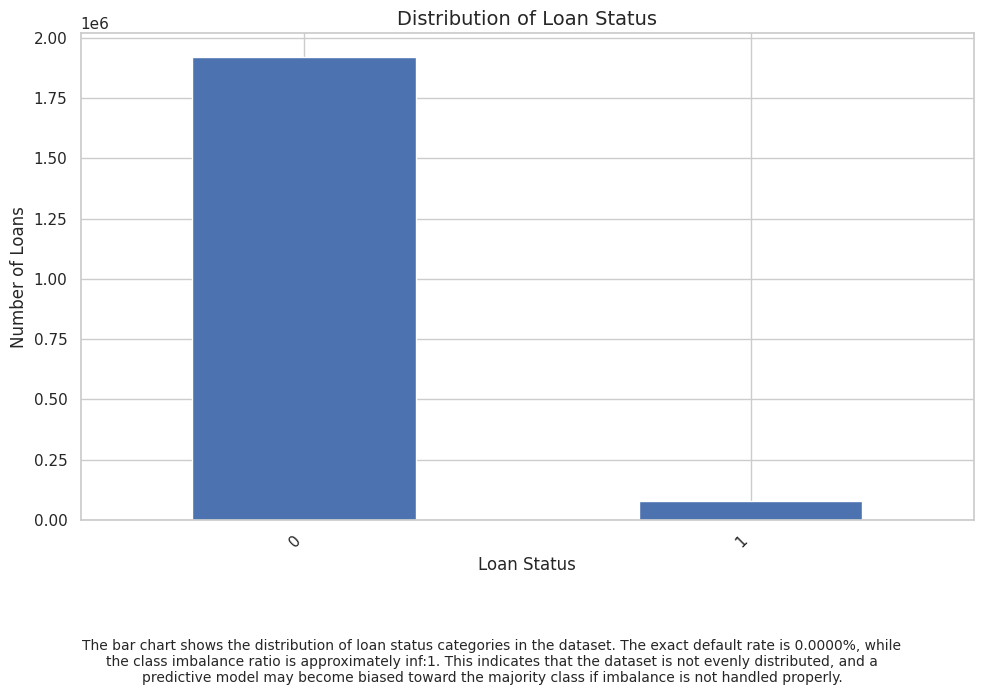

In [ ]:
# Prepare loan_status count data
loan_status_counts = full_df["loan_status"].value_counts()

# Create bar chart
plt.figure(figsize=(10, 6))

loan_status_counts.plot(kind="bar")

plt.title("Distribution of Loan Status", fontsize=14)
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45, ha="right")

# Create 3-sentence business insight caption
caption = (
    f"The bar chart shows the distribution of loan status categories in the dataset. "
    f"The exact default rate is {default_rate * 100:.4f}%, while the class imbalance ratio is approximately {imbalance_ratio:.2f}:1. "
    f"This indicates that the dataset is not evenly distributed, and a predictive model may become biased toward the majority class if imbalance is not handled properly."
)

plt.figtext(
    0.5, -0.15,
    textwrap.fill(caption, width=120),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

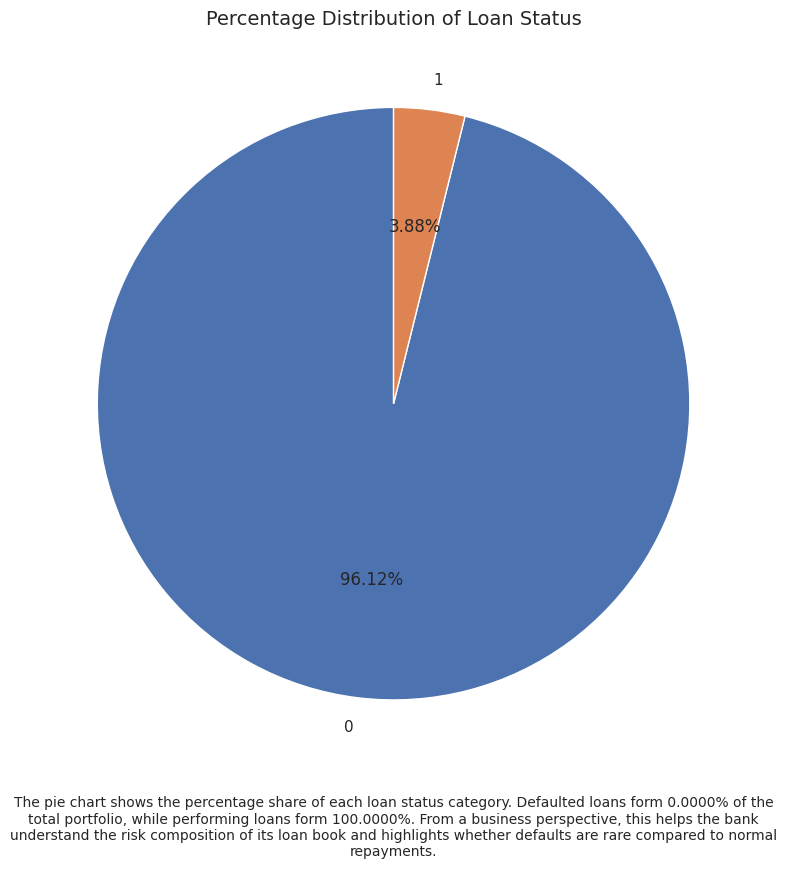

In [ ]:
# Create pie chart for loan_status distribution

plt.figure(figsize=(8, 8))

loan_status_counts.plot(
    kind="pie",
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Percentage Distribution of Loan Status", fontsize=14)
plt.ylabel("")

# Create 3-sentence business insight caption
caption = (
    f"The pie chart shows the percentage share of each loan status category. "
    f"Defaulted loans form {default_rate * 100:.4f}% of the total portfolio, while performing loans form {(1 - default_rate) * 100:.4f}%. "
    f"From a business perspective, this helps the bank understand the risk composition of its loan book and highlights whether defaults are rare compared to normal repayments."
)

plt.figtext(
    0.5, -0.08,
    textwrap.fill(caption, width=110),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Q2 b

In [ ]:
# Check if cibil_score exists and inspect its basic summary

full_df["cibil_score"].describe()

count    2.000000e+06
mean     6.798828e+02
std      8.462665e+01
min      3.000000e+02
25%      6.230000e+02
50%      6.800000e+02
75%      7.370000e+02
max      9.000000e+02
Name: cibil_score, dtype: float64

In [ ]:
# Separate CIBIL scores for performing and defaulted loans
# dropna() removes missing values before statistical comparison

performing_cibil = full_df.loc[
    full_df["default_flag"] == 0,
    "cibil_score"
].dropna()

defaulted_cibil = full_df.loc[
    full_df["default_flag"] == 1,
    "cibil_score"
].dropna()

# Calculate mean CIBIL score for both groups
mean_performing = performing_cibil.mean()
mean_defaulted = defaulted_cibil.mean()

print("Mean CIBIL score - Performing loans:", round(mean_performing, 2))
print("Mean CIBIL score - Defaulted loans:", round(mean_defaulted, 2))

Mean CIBIL score - Performing loans: 679.88
Mean CIBIL score - Defaulted loans: nan


In [ ]:
# Calculate standard deviation for both groups
std_performing = performing_cibil.std()
std_defaulted = defaulted_cibil.std()

# Calculate group sizes
n_performing = len(performing_cibil)
n_defaulted = len(defaulted_cibil)

# Calculate pooled standard deviation
pooled_std = np.sqrt(
    ((n_performing - 1) * std_performing**2 +
     (n_defaulted - 1) * std_defaulted**2)
    /
    (n_performing + n_defaulted - 2)
)

# Calculate Cohen's d
cohens_d = (mean_performing - mean_defaulted) / pooled_std

print("Cohen's d effect size:", round(cohens_d, 4))

Cohen's d effect size: nan


In [ ]:
# For very large data, KDE calculation can be slow
# So we use a sample for KDE overlap calculation and plotting

sample_size = 50000

performing_sample = performing_cibil.sample(
    n=min(sample_size, len(performing_cibil)),
    random_state=42
)

defaulted_sample = defaulted_cibil.sample(
    n=min(sample_size, len(defaulted_cibil)),
    random_state=42
)

# Create a common x-axis range for both KDE curves
x_min = min(performing_sample.min(), defaulted_sample.min())
x_max = max(performing_sample.max(), defaulted_sample.max())
x_grid = np.linspace(x_min, x_max, 1000)

# Estimate KDE density for both groups
kde_performing = gaussian_kde(performing_sample)
kde_defaulted = gaussian_kde(defaulted_sample)

density_performing = kde_performing(x_grid)
density_defaulted = kde_defaulted(x_grid)

# Distributional overlap is the shared area under both curves
# Calculate overlap area
# np.trapezoid calculates the area under the shared part of both KDE curves

overlap_area = np.trapezoid(
    np.minimum(density_performing, density_defaulted),
    x_grid
)

print("Distributional overlap:", round(overlap_area * 100, 2), "%")

Distributional overlap: 90.34 %


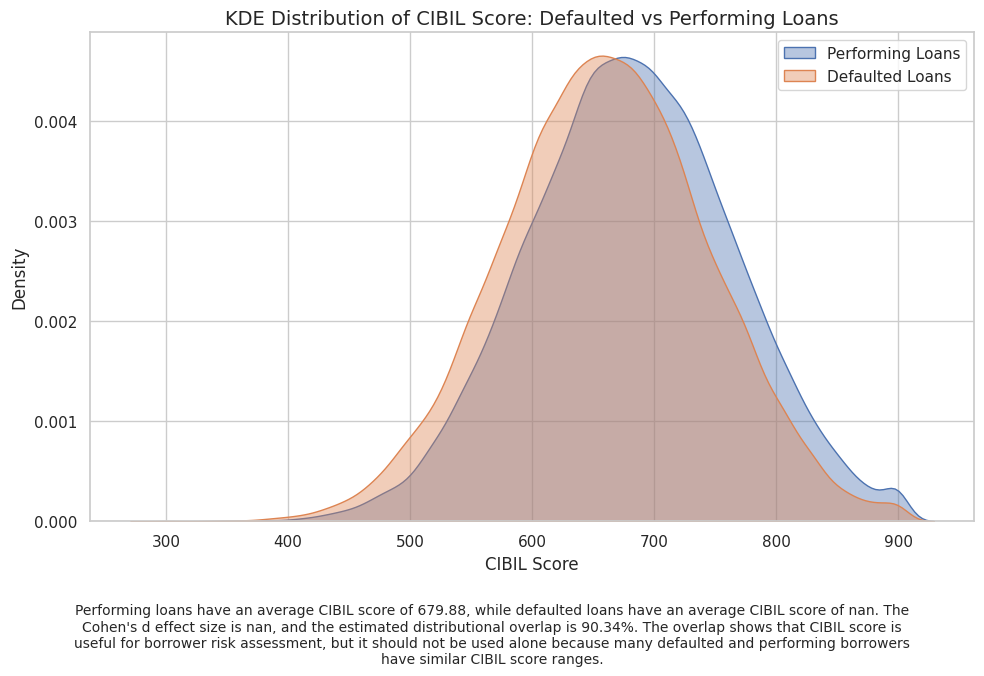

In [ ]:
# Plot KDE curves of CIBIL score for performing and defaulted loans
# This chart helps us visually compare credit score distribution between both groups

plt.figure(figsize=(10, 6))

# KDE curve for performing loans
sns.kdeplot(
    performing_sample,
    label="Performing Loans",
    fill=True,
    alpha=0.4
)

# KDE curve for defaulted loans
sns.kdeplot(
    defaulted_sample,
    label="Defaulted Loans",
    fill=True,
    alpha=0.4
)

# Add title and axis labels
plt.title("KDE Distribution of CIBIL Score: Defaulted vs Performing Loans", fontsize=14)
plt.xlabel("CIBIL Score")
plt.ylabel("Density")
plt.legend()

# Add 3-sentence business insight caption
caption = (
    f"Performing loans have an average CIBIL score of {mean_performing:.2f}, while defaulted loans have an average CIBIL score of {mean_defaulted:.2f}. "
    f"The Cohen's d effect size is {cohens_d:.4f}, and the estimated distributional overlap is {overlap_area * 100:.2f}%. "
    f"The overlap shows that CIBIL score is useful for borrower risk assessment, but it should not be used alone because many defaulted and performing borrowers have similar CIBIL score ranges."
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=120),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Q2 c

In [ ]:
# Select all numeric columns from the full dataset
# Numeric columns are needed for histograms and skewness calculation

numeric_cols = full_df.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

# Remove ID columns and flag columns
# ID columns are identifiers, not real analytical numeric variables

numeric_cols = [
    col for col in numeric_cols
    if "id" not in col.lower()
    and "flag" not in col.lower()
]

# Preferred banking-related numeric columns
# These are useful for loan risk analysis

preferred_numeric_cols = [
    "loan_amnt",
    "annual_inc",
    "int_rate",
    "installment",
    "dti",
    "cibil_score",
    "emp_length_years",
    "mths_since_last_delinq",
    "mort_acc",
    "il_util_pct",
    "revol_bal",
    "revol_util_pct",
    "open_acc",
    "total_acc",
    "delinq_2yrs",
    "inq_last_6mths"
]

# Keep only those preferred columns that actually exist in your dataset

key_numeric_cols = [
    col for col in preferred_numeric_cols
    if col in full_df.columns
]

# If fewer than 12 preferred columns exist, add other numeric columns

for col in numeric_cols:
    if col not in key_numeric_cols and len(key_numeric_cols) < 12:
        key_numeric_cols.append(col)

# Keep only first 12 columns for 12-panel histogram grid

key_numeric_cols = key_numeric_cols[:12]

# Display selected columns

key_numeric_cols

['cibil_score',
 'emp_length_years',
 'mths_since_last_delinq',
 'mort_acc',
 'il_util_pct',
 'revol_util_pct',
 'open_acc',
 'total_acc',
 'delinq_2yrs',
 'loan_amnt_inr',
 'funded_amnt_inr',
 'int_rate_pct']

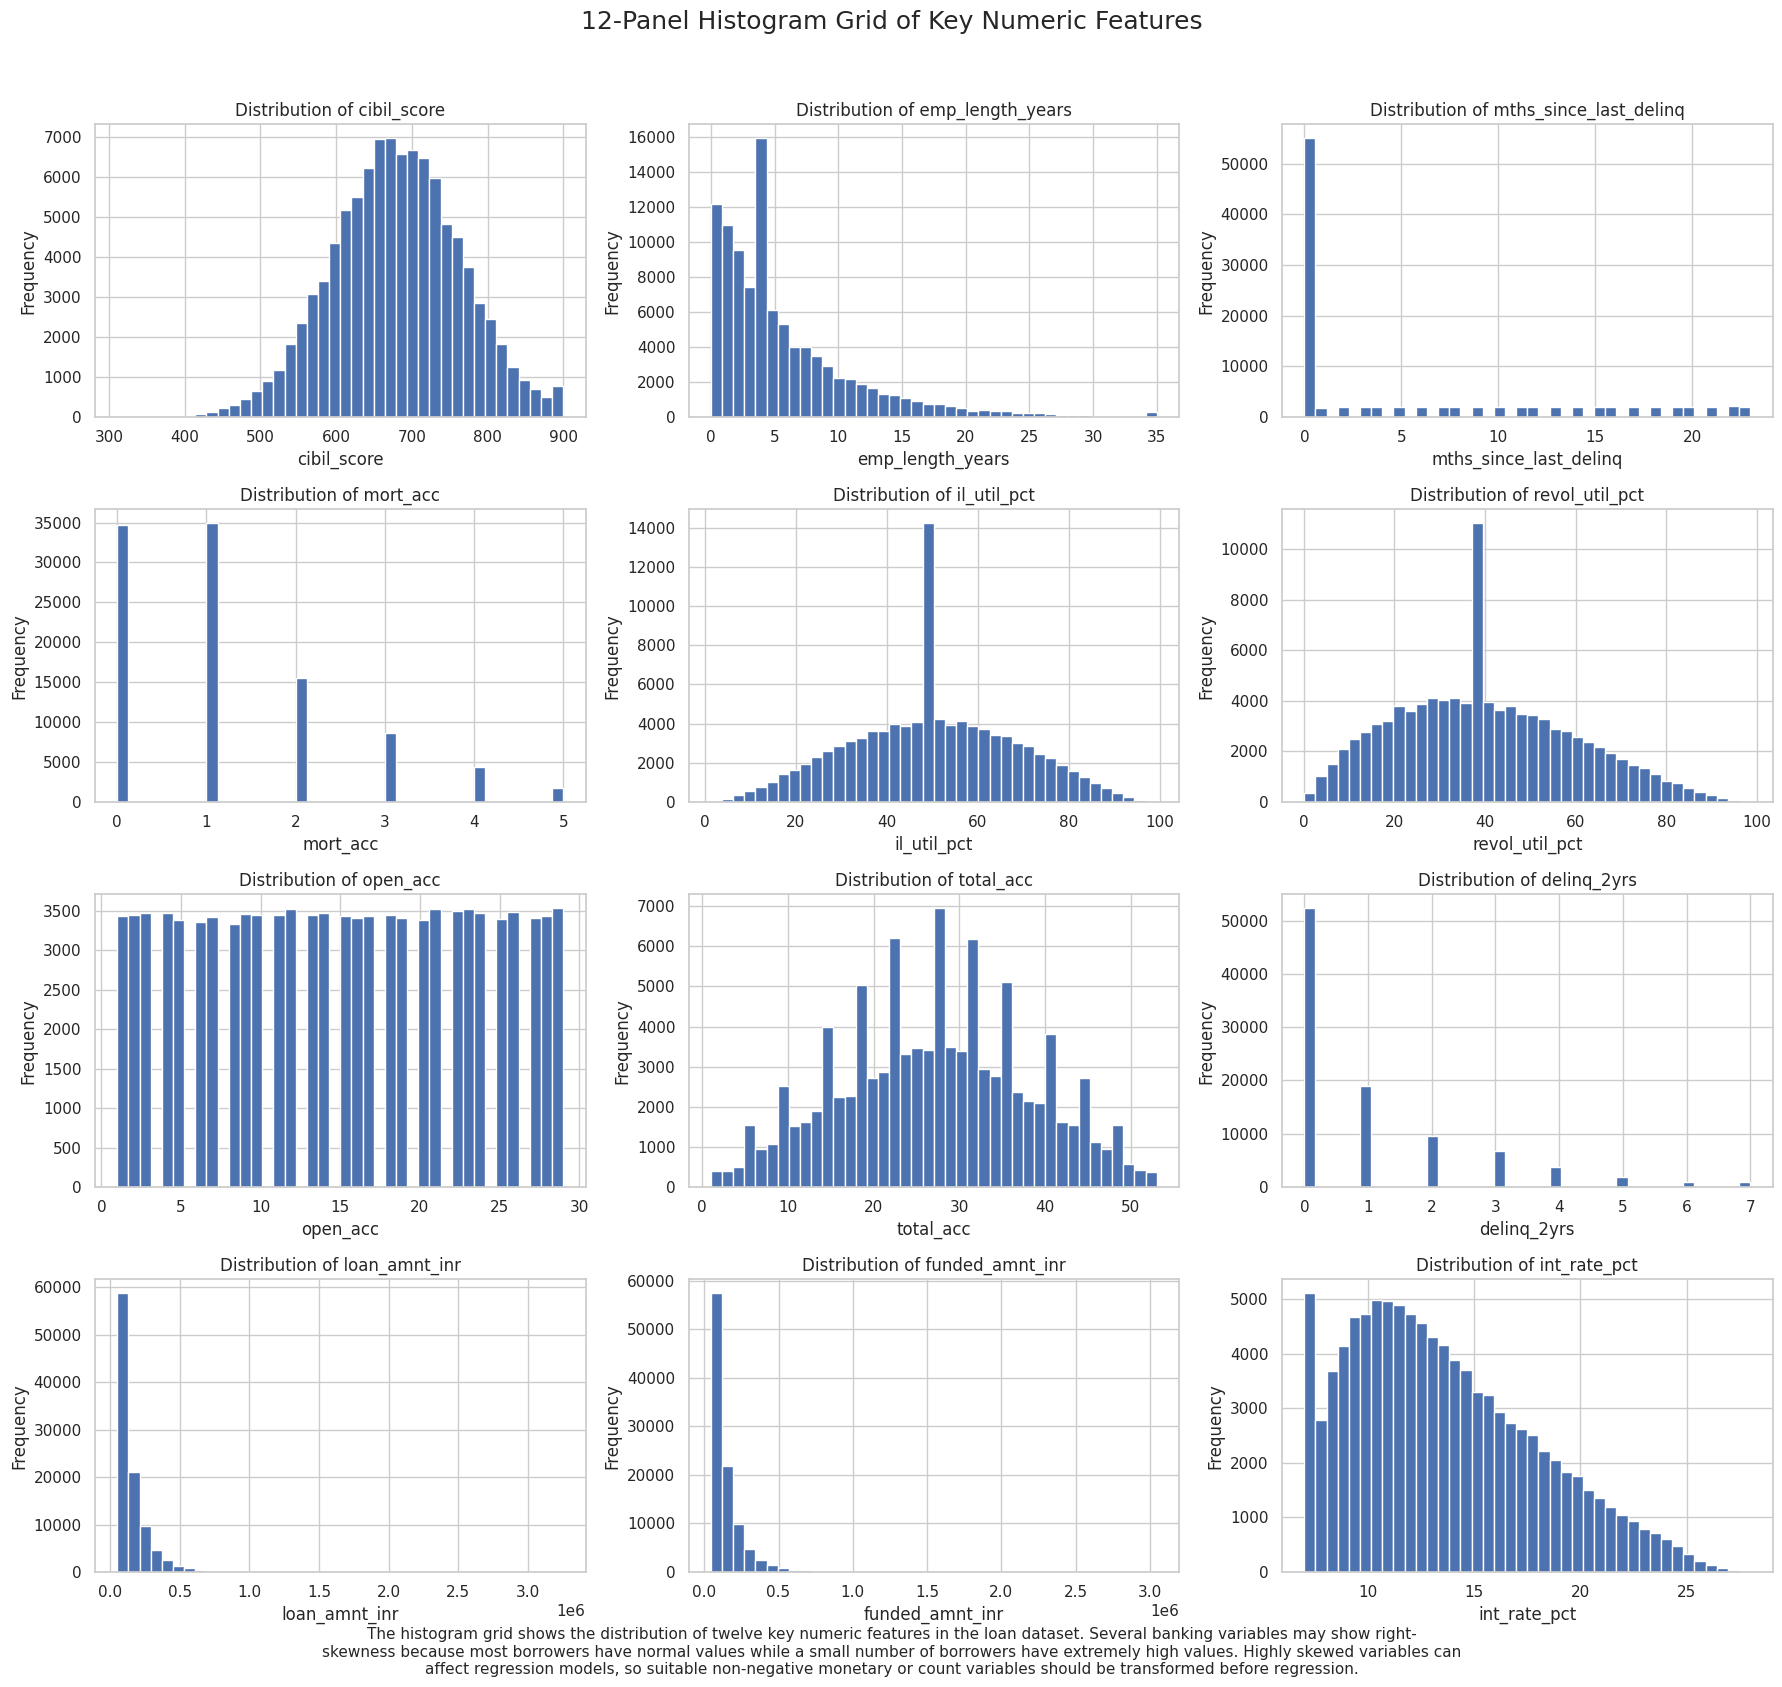

In [ ]:
# Create a sample for plotting
# Plotting all 20 lakh rows can be slow, so we sample for visualization only

plot_sample = full_df.sample(
    n=min(100000, len(full_df)),
    random_state=42
)

# Create 4 rows and 3 columns = 12 plots

fig, axes = plt.subplots(4, 3, figsize=(18, 16))

# Flatten axes so we can loop easily

axes = axes.flatten()

# Create histogram for each selected numeric column

for i, col in enumerate(key_numeric_cols):

    axes[i].hist(
        plot_sample[col].dropna(),
        bins=40
    )

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Remove unused blank plots if fewer than 12 columns are available

for j in range(len(key_numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Add 3-sentence insight caption

caption = (
    "The histogram grid shows the distribution of twelve key numeric features in the loan dataset. "
    "Several banking variables may show right-skewness because most borrowers have normal values while a small number of borrowers have extremely high values. "
    "Highly skewed variables can affect regression models, so suitable non-negative monetary or count variables should be transformed before regression."
)

fig.text(
    0.5, -0.02,
    textwrap.fill(caption, width=140),
    ha="center",
    fontsize=11
)

plt.suptitle("12-Panel Histogram Grid of Key Numeric Features", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate skewness for the selected numeric columns
# Positive skew means the right tail is longer
# Skewness above 2.0 means highly right-skewed

skew_values = full_df[key_numeric_cols].skew().sort_values(ascending=False)

# Convert skewness result into a clean table

skew_table = pd.DataFrame({
    "Feature": skew_values.index,
    "Skewness Before": skew_values.values
})

skew_table

,Feature,Skewness Before
0,funded_amnt_inr,3.655737
1,loan_amnt_inr,3.651117
2,emp_length_years,1.939471
3,delinq_2yrs,1.774446
4,mort_acc,1.082175
5,mths_since_last_delinq,1.052462
6,int_rate_pct,0.590027
7,revol_util_pct,0.312842
8,il_util_pct,0.001638
9,total_acc,0.000877


In [ ]:
# Select features where skewness is greater than 2.0
# These are strongly right-skewed variables

high_right_skew = skew_table[skew_table["Skewness Before"] > 2.0]

high_right_skew

,Feature,Skewness Before
0,funded_amnt_inr,3.655737
1,loan_amnt_inr,3.651117


In [ ]:
# Not every skewed variable should be log-transformed.
# We avoid bounded variables such as rates, percentages, ratios, and scores.

bounded_keywords = [
    "rate",
    "pct",
    "percent",
    "score",
    "ratio",
    "flag"
]

# This list will store columns selected for log transformation

log_transform_cols = []

for col in high_right_skew["Feature"].tolist():

    # Check if the column name suggests a bounded variable
    is_bounded = any(keyword in col.lower() for keyword in bounded_keywords)

    # Check if the column has only zero or positive values
    is_non_negative = (full_df[col].dropna() >= 0).all()

    # Apply log only to non-bounded and non-negative variables
    if (not is_bounded) and is_non_negative:
        log_transform_cols.append(col)

# Display columns selected for log transformation

log_transform_cols

['funded_amnt_inr', 'loan_amnt_inr']

In [ ]:
# Apply log1p transformation to selected columns
# log1p means log(1 + x), so it safely handles zero values

for col in log_transform_cols:

    new_col = col + "_log1p"

    full_df[new_col] = np.log1p(full_df[col])

# Show newly created columns

[col + "_log1p" for col in log_transform_cols]

['funded_amnt_inr_log1p', 'loan_amnt_inr_log1p']

In [ ]:
# Compare skewness before and after log transformation

log_skew_report = []

for col in log_transform_cols:

    original_skew = full_df[col].skew()
    transformed_skew = full_df[col + "_log1p"].skew()

    log_skew_report.append({
        "Feature": col,
        "Skewness Before": original_skew,
        "Skewness After Log1p": transformed_skew,
        "Reduction": abs(original_skew) - abs(transformed_skew)
    })

# Convert report into DataFrame

log_skew_report_df = pd.DataFrame(log_skew_report)

log_skew_report_df

,Feature,Skewness Before,Skewness After Log1p,Reduction
0,funded_amnt_inr,3.655737,0.579250,3.076487
1,loan_amnt_inr,3.651117,0.581627,3.069490


# Q2 D

In [ ]:
# Select all numeric columns from the full dataset
# Correlation works only on numeric columns

numeric_cols = full_df.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

# Remove columns that are not useful as predictors
# ID columns are identifiers, not real variables
# Flag columns are binary indicators and may not be suitable for this heatmap
# Log-transformed columns are also removed to avoid duplicate correlation with original columns

numeric_cols = [
    col for col in numeric_cols
    if "id" not in col.lower()
    and "flag" not in col.lower()
    and "loan_status" not in col.lower()
    and not col.endswith("_log1p")
]

# Remove columns having only one unique value
# Such columns cannot give meaningful correlation

numeric_cols = [
    col for col in numeric_cols
    if full_df[col].nunique(dropna=True) > 1
]

# Select top 20 numeric columns based on non-missing values
# This ensures that selected columns have enough data for reliable correlation

top_20_numeric = (
    full_df[numeric_cols]
    .notnull()
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

# Display selected top 20 numeric features

top_20_numeric

['loan_amnt_inr',
 'funded_amnt_inr',
 'int_rate_pct',
 'installment_inr',
 'annual_installment_inr',
 'urban_index',
 'rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'collateral_value_inr',
 'vehicle_value_inr',
 'prop_value_inr',
 'rejection_rate_pct',
 'business_asset_val_inr',
 'expected_loss_inr',
 'out_prncp_inr',
 'sanctioned_amount_inr',
 'disbursed_amount_inr']

In [ ]:
# Compute Pearson correlation matrix
# Pearson correlation shows linear relationship between two numeric variables
# Value near +1 means strong positive relation
# Value near -1 means strong negative relation
# Value near 0 means weak linear relation

corr_matrix = full_df[top_20_numeric].corr(method="pearson")

# Display correlation matrix

corr_matrix

,loan_amnt_inr,funded_amnt_inr,int_rate_pct,installment_inr,annual_installment_inr,urban_index,rbi_repo_rate_pct,gdp_growth_pct,cpi_inflation_pct,rate_spread_pct,real_interest_rate_pct,collateral_value_inr,vehicle_value_inr,prop_value_inr,rejection_rate_pct,business_asset_val_inr,expected_loss_inr,out_prncp_inr,sanctioned_amount_inr,disbursed_amount_inr
loan_amnt_inr,1.000000,0.998466,0.000037,0.838146,0.838146,-0.000097,0.000881,0.000779,0.000529,-0.000191,-0.000187,0.000106,-0.000037,0.000085,-0.000117,0.000106,0.052581,0.108451,0.997531,0.996887
funded_amnt_inr,0.998466,1.000000,-0.000031,0.836806,0.836806,-0.000133,0.000808,0.000735,0.000542,-0.000238,-0.000254,0.000073,-0.000054,0.000067,-0.000143,0.000045,0.052455,0.108242,0.995997,0.995354
int_rate_pct,0.000037,-0.000031,1.000000,0.063556,0.063556,-0.000686,0.000583,0.000612,0.000193,0.966204,0.908795,-0.000499,-0.000234,-0.000465,0.032770,-0.000075,0.119257,0.054053,0.000153,0.000130
installment_inr,0.838146,0.836806,0.063556,1.000000,1.000000,-0.000686,0.000713,0.001072,0.000127,0.061234,0.057712,0.000917,-0.000116,0.001061,0.001387,-0.000574,0.051612,0.095196,0.836050,0.835490
annual_installment_inr,0.838146,0.836806,0.063556,1.000000,1.000000,-0.000686,0.000713,0.001072,0.000127,0.061234,0.057712,0.000917,-0.000116,0.001061,0.001387,-0.000574,0.051612,0.095196,0.836050,0.835491
urban_index,-0.000097,-0.000133,-0.000686,-0.000686,-0.000686,1.000000,0.001059,0.000688,0.000630,-0.000936,-0.000886,-0.001007,-0.000318,-0.000715,-0.000689,-0.001181,-0.002037,-0.001771,-0.000171,-0.000139
rbi_repo_rate_pct,0.000881,0.000808,0.000583,0.000713,0.000713,0.001059,1.000000,0.421951,0.308722,-0.257214,-0.128282,0.001613,0.000208,0.001772,-0.001923,-0.000732,-0.009544,-0.004767,0.000963,0.001019
gdp_growth_pct,0.000779,0.000735,0.000612,0.001072,0.001072,0.000688,0.421951,1.000000,-0.058021,-0.108178,0.024765,0.000551,0.000225,0.000536,-0.001623,0.000001,-0.011987,-0.005242,0.000919,0.000919
cpi_inflation_pct,0.000529,0.000542,0.000193,0.000127,0.000127,0.000630,0.308722,-0.058021,1.000000,-0.079395,-0.417067,0.000756,-0.000084,0.000695,-0.000188,0.000309,-0.001276,-0.000507,0.000530,0.000547
rate_spread_pct,-0.000191,-0.000238,0.966204,0.061234,0.061234,-0.000936,-0.257214,-0.108178,-0.079395,1.000000,0.911287,-0.000898,-0.000279,-0.000906,0.032163,0.000116,0.117705,0.053463,-0.000100,-0.000137


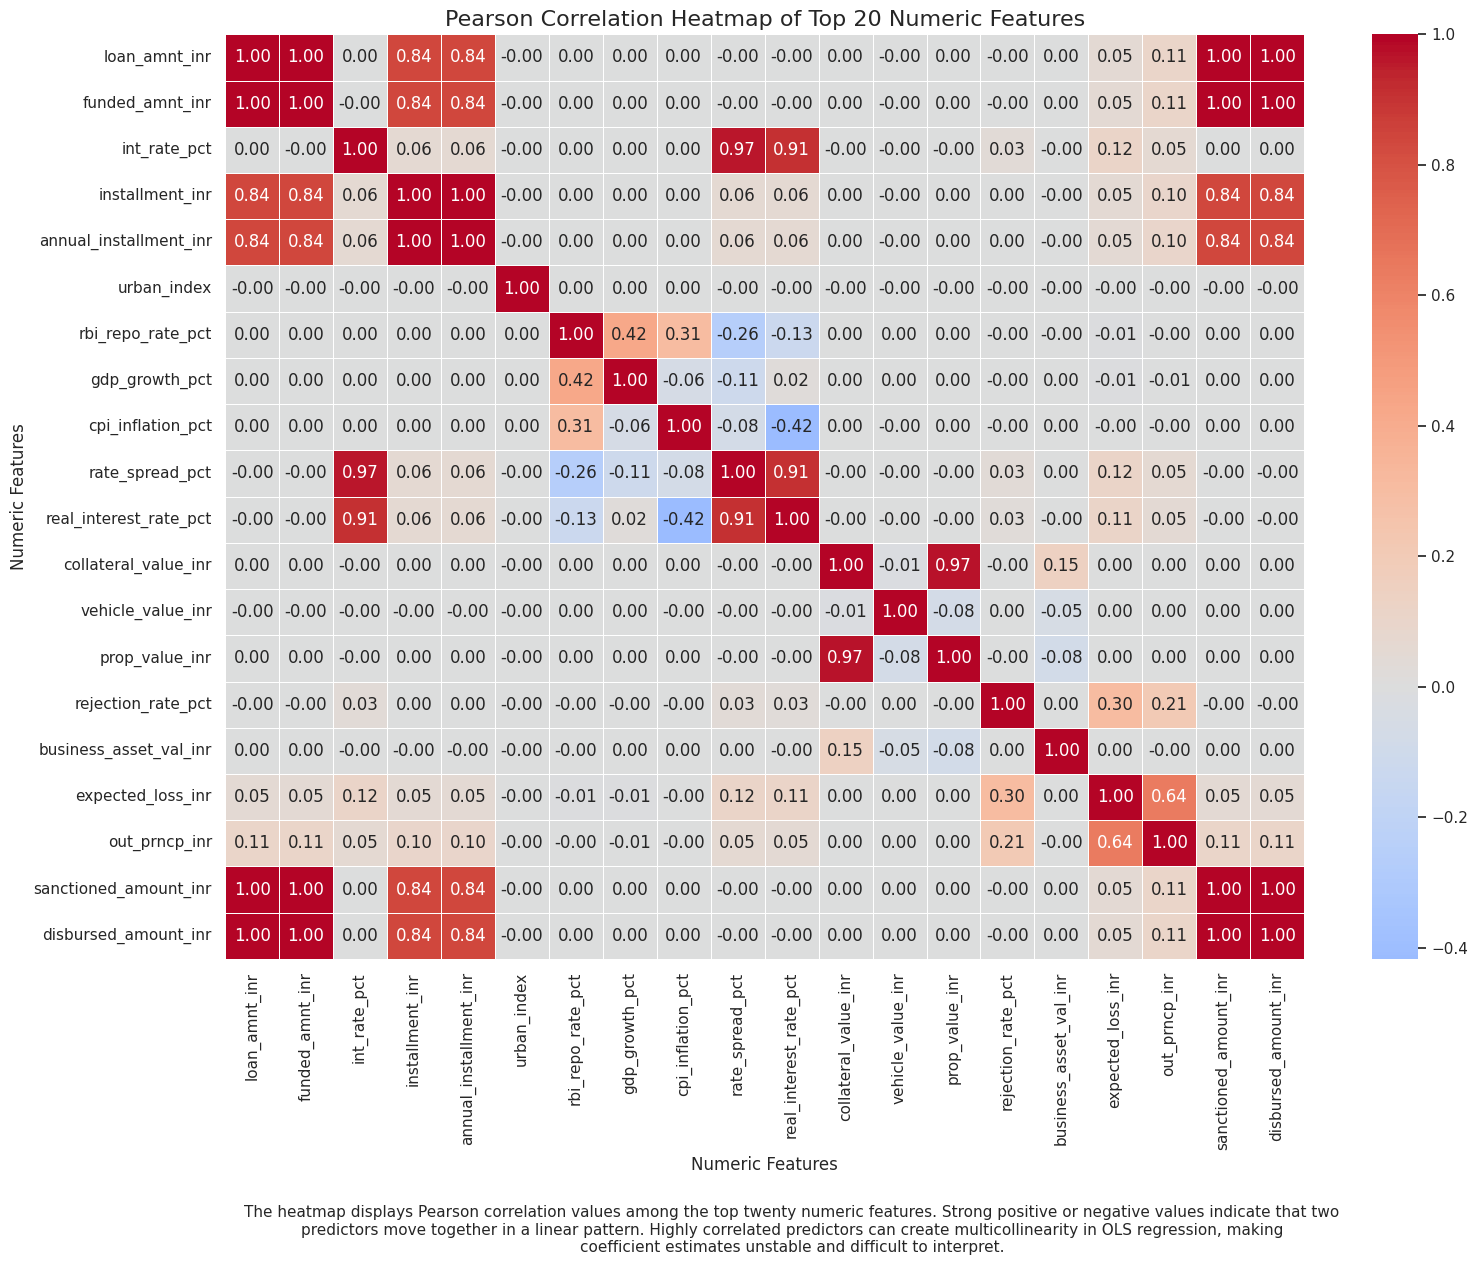

In [ ]:
# Create heatmap of Pearson correlation matrix

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values inside boxes
    fmt=".2f",           # Round values to 2 decimal places
    cmap="coolwarm",     # Blue-red color scale
    center=0,            # Center color scale at zero
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap of Top 20 Numeric Features", fontsize=16)
plt.xlabel("Numeric Features")
plt.ylabel("Numeric Features")

# Add required 3-sentence insight caption

caption = (
    "The heatmap displays Pearson correlation values among the top twenty numeric features. "
    "Strong positive or negative values indicate that two predictors move together in a linear pattern. "
    "Highly correlated predictors can create multicollinearity in OLS regression, making coefficient estimates unstable and difficult to interpret."
)

plt.figtext(
    0.5, -0.05,
    textwrap.fill(caption, width=140),
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.show()

In [ ]:
# Identify highly correlated feature pairs
# We check only the upper triangle to avoid duplicate pairs
# Example duplicate: loan_amnt vs installment and installment vs loan_amnt

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]

        # Check absolute correlation greater than 0.75
        if abs(corr_value) > 0.75:
            high_corr_pairs.append({
                "Feature 1": col1,
                "Feature 2": col2,
                "Pearson r": corr_value,
                "Absolute r": abs(corr_value)
            })

# Convert result into DataFrame

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

# Sort highest correlation pairs first

if not high_corr_pairs_df.empty:
    high_corr_pairs_df = high_corr_pairs_df.sort_values(
        by="Absolute r",
        ascending=False
    )

high_corr_pairs_df

,Feature 1,Feature 2,Pearson r,Absolute r
11,installment_inr,annual_installment_inr,1.000000,1.000000
18,sanctioned_amount_inr,disbursed_amount_inr,0.999345,0.999345
0,loan_amnt_inr,funded_amnt_inr,0.998466,0.998466
3,loan_amnt_inr,sanctioned_amount_inr,0.997531,0.997531
4,loan_amnt_inr,disbursed_amount_inr,0.996887,0.996887
7,funded_amnt_inr,sanctioned_amount_inr,0.995997,0.995997
8,funded_amnt_inr,disbursed_amount_inr,0.995354,0.995354
17,collateral_value_inr,prop_value_inr,0.971581,0.971581
9,int_rate_pct,rate_spread_pct,0.966204,0.966204
16,rate_spread_pct,real_interest_rate_pct,0.911287,0.911287


# Q2 e

In [ ]:
# Create readable labels from default_flag
# 0 means performing loan
# 1 means defaulted loan

full_df["loan_group"] = np.where(
    full_df["default_flag"] == 1,
    "Defaulted",
    "Performing"
)

# Check group counts

full_df["loan_group"].value_counts()

loan_group
Performing    1922444
Defaulted       77556
Name: count, dtype: int64

In [ ]:
# Function to find the first matching column from a list of possible names

def find_existing_column(possible_names, dataframe):
    for col in possible_names:
        if col in dataframe.columns:
            return col
    return None


# Required features with possible alternate names

feature_candidates = {
    "int_rate": ["int_rate"],
    "dti": ["dti"],
    "cibil_score": ["cibil_score"],
    "annual_inc": ["annual_inc"],
    "revol_util": ["revol_util", "revol_util_pct"],
    "emp_length": ["emp_length", "emp_length_years"]
}

# Find actual column names present in the dataset

selected_boxplot_features = {}

for display_name, possible_names in feature_candidates.items():
    actual_col = find_existing_column(possible_names, full_df)

    if actual_col is not None:
        selected_boxplot_features[display_name] = actual_col

# Display selected columns

selected_boxplot_features

{'cibil_score': 'cibil_score',
 'revol_util': 'revol_util_pct',
 'emp_length': 'emp_length_years'}

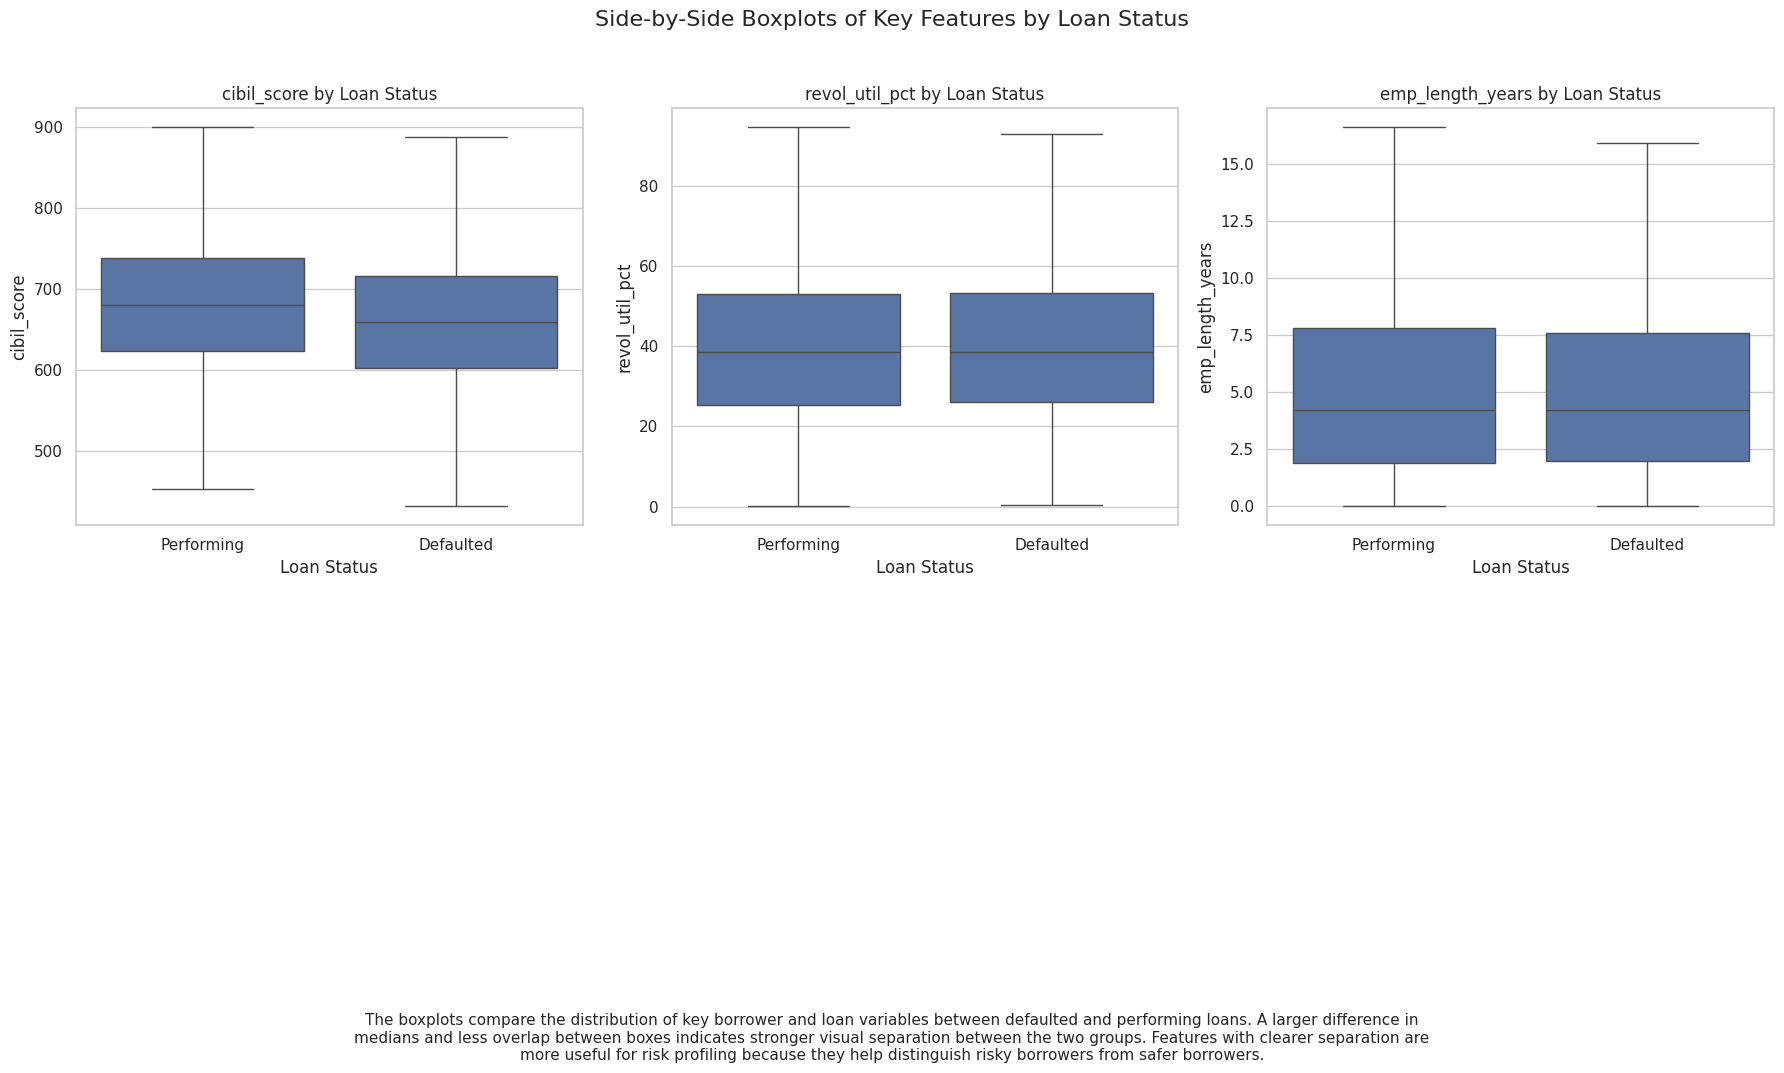

In [ ]:
# Create sample for plotting
# Boxplots on 20 lakh rows may be slow, so we sample for visualization only

boxplot_cols = list(selected_boxplot_features.values())

plot_sample = full_df[
    ["loan_group"] + boxplot_cols
].dropna().sample(
    n=min(100000, len(full_df)),
    random_state=42
)

# Create 2 rows and 3 columns of boxplots

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

# Plot one boxplot for each feature

for i, (display_name, actual_col) in enumerate(selected_boxplot_features.items()):

    sns.boxplot(
        data=plot_sample,
        x="loan_group",
        y=actual_col,
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(f"{actual_col} by Loan Status")
    axes[i].set_xlabel("Loan Status")
    axes[i].set_ylabel(actual_col)

# Remove unused panels if any feature is missing

for j in range(len(selected_boxplot_features), len(axes)):
    fig.delaxes(axes[j])

# Add 3-sentence insight caption

caption = (
    "The boxplots compare the distribution of key borrower and loan variables between defaulted and performing loans. "
    "A larger difference in medians and less overlap between boxes indicates stronger visual separation between the two groups. "
    "Features with clearer separation are more useful for risk profiling because they help distinguish risky borrowers from safer borrowers."
)

fig.text(
    0.5, -0.03,
    textwrap.fill(caption, width=140),
    ha="center",
    fontsize=11
)

plt.suptitle("Side-by-Side Boxplots of Key Features by Loan Status", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate median of each feature by loan group

median_table = (
    full_df
    .groupby("loan_group")[boxplot_cols]
    .median()
    .T
)

# Calculate median difference
# Difference = Defaulted median - Performing median

median_table["Median Difference Defaulted - Performing"] = (
    median_table["Defaulted"] - median_table["Performing"]
)

# Also calculate absolute difference for ranking

median_table["Absolute Median Difference"] = (
    median_table["Median Difference Defaulted - Performing"].abs()
)

# Display median difference table

median_table

loan_group,Defaulted,Performing,Median Difference Defaulted - Performing,Absolute Median Difference
cibil_score,660.000000,681.000000,-21.0,21.0
revol_util_pct,38.599998,38.599998,0.0,0.0
emp_length_years,4.200000,4.200000,0.0,0.0


In [ ]:
# Calculate a standardized separation score
# This adjusts median difference by the spread of the feature
# Higher score means better separation between defaulted and performing loans

separation_report = []

for col in boxplot_cols:

    default_values = full_df.loc[
        full_df["loan_group"] == "Defaulted",
        col
    ].dropna()

    performing_values = full_df.loc[
        full_df["loan_group"] == "Performing",
        col
    ].dropna()

    default_median = default_values.median()
    performing_median = performing_values.median()

    median_diff = default_median - performing_median

    # Calculate IQR for both groups
    default_iqr = default_values.quantile(0.75) - default_values.quantile(0.25)
    performing_iqr = performing_values.quantile(0.75) - performing_values.quantile(0.25)

    pooled_iqr = (default_iqr + performing_iqr) / 2

    # Avoid division by zero
    if pooled_iqr == 0:
        separation_score = np.nan
    else:
        separation_score = abs(median_diff) / pooled_iqr

    separation_report.append({
        "Feature": col,
        "Defaulted Median": default_median,
        "Performing Median": performing_median,
        "Median Difference": median_diff,
        "Absolute Median Difference": abs(median_diff),
        "Standardized Separation Score": separation_score
    })

# Convert to DataFrame

separation_report_df = pd.DataFrame(separation_report)

# Sort by clearest separation

separation_report_df = separation_report_df.sort_values(
    by="Standardized Separation Score",
    ascending=False
)

separation_report_df

,Feature,Defaulted Median,Performing Median,Median Difference,Absolute Median Difference,Standardized Separation Score
0,cibil_score,660.000000,681.000000,-21.0,21.0,0.183406
1,revol_util_pct,38.599998,38.599998,0.0,0.0,0.000000
2,emp_length_years,4.200000,4.200000,0.0,0.0,0.000000


In [ ]:
# Identify feature with highest standardized separation score

clearest_feature = separation_report_df.iloc[0]["Feature"]
clearest_score = separation_report_df.iloc[0]["Standardized Separation Score"]

print("Clearest visual separation feature:", clearest_feature)
print("Standardized separation score:", round(clearest_score, 4))

Clearest visual separation feature: cibil_score
Standardized separation score: 0.1834


# Q2 F

In [ ]:
# Find grade column
# Dataset may use grade, loan_grade, or sub_grade

possible_grade_cols = ["grade", "loan_grade", "loan_grade_x", "grade_x"]

grade_col = find_existing_column(possible_grade_cols, full_df)

grade_col

'grade'

In [ ]:
# Create clean grade column
# Keep only first letter because grades should be A to G

full_df["grade_clean"] = (
    full_df[grade_col]
    .astype(str)
    .str.upper()
    .str.strip()
    .str[0]
)

# Keep only valid grades A to G

valid_grades = ["A", "B", "C", "D", "E", "F", "G"]

grade_df = full_df[full_df["grade_clean"].isin(valid_grades)].copy()

# Check grade distribution

grade_df["grade_clean"].value_counts().sort_index()

grade_clean
A    360837
B    440088
C    398758
D    319253
E    240030
F    160598
G     80436
Name: count, dtype: int64

In [ ]:
# Calculate default rate by loan grade
# Since default_flag is 1 for default and 0 for performing,
# mean(default_flag) gives default rate

grade_default_rate = (
    grade_df
    .groupby("grade_clean")["default_flag"]
    .agg(["count", "sum", "mean"])
    .reindex(valid_grades)
)

# Rename columns clearly

grade_default_rate.columns = [
    "Total Loans",
    "Defaulted Loans",
    "Default Rate"
]

# Convert default rate to percentage

grade_default_rate["Default Rate %"] = (
    grade_default_rate["Default Rate"] * 100
)

# Display result

grade_default_rate

,Total Loans,Defaulted Loans,Default Rate,Default Rate %
grade_clean,,,,
A,360837,8051,0.022312,2.231201
B,440088,11824,0.026867,2.686735
C,398758,13361,0.033507,3.350654
D,319253,13359,0.041845,4.184456
E,240030,12697,0.052898,5.289755
F,160598,11071,0.068936,6.893610
G,80436,7193,0.089425,8.942513


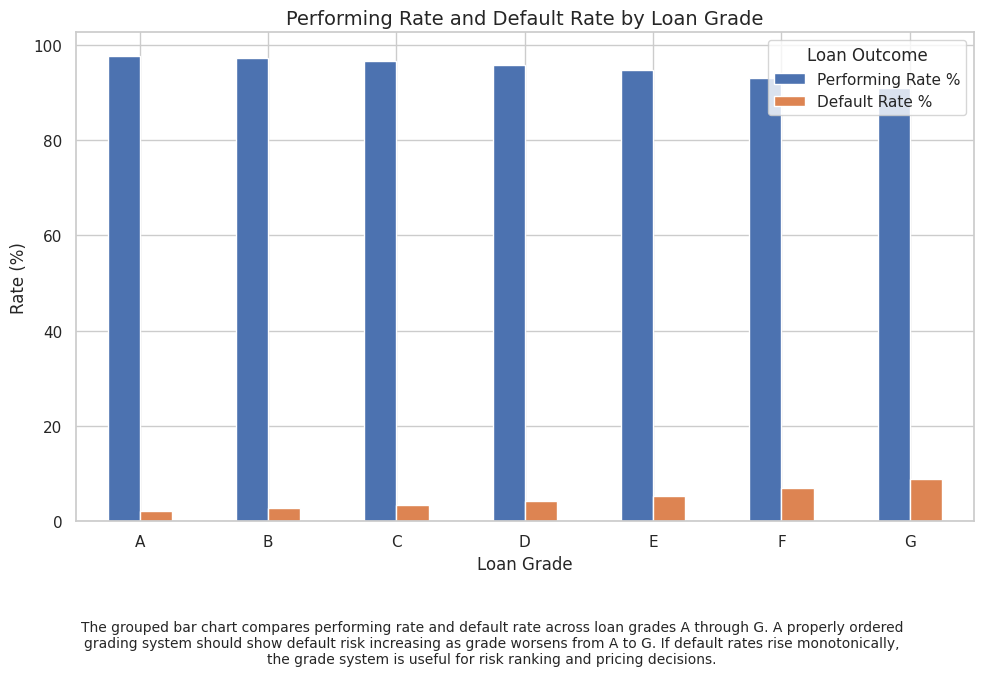

In [ ]:
# Prepare grouped rate table
# Default rate + performing rate should add up to 100%

grade_rate_plot = grade_default_rate[["Default Rate %"]].copy()

grade_rate_plot["Performing Rate %"] = 100 - grade_rate_plot["Default Rate %"]

# Keep order as A to G

grade_rate_plot = grade_rate_plot.loc[valid_grades]

# Plot grouped bar chart

ax = grade_rate_plot[
    ["Performing Rate %", "Default Rate %"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performing Rate and Default Rate by Loan Grade", fontsize=14)
plt.xlabel("Loan Grade")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Loan Outcome")

# Add 3-sentence business insight caption

caption = (
    "The grouped bar chart compares performing rate and default rate across loan grades A through G. "
    "A properly ordered grading system should show default risk increasing as grade worsens from A to G. "
    "If default rates rise monotonically, the grade system is useful for risk ranking and pricing decisions."
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=120),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [ ]:
# Check monotonic increase in default rate from A to G

default_rates = grade_default_rate["Default Rate %"]

is_monotonic = default_rates.is_monotonic_increasing

print("Is the grade system monotonically ordered?", is_monotonic)

Is the grade system monotonically ordered? True


In [ ]:
# Calculate stepwise jump in default rate from one grade to the next
# Example: B minus A, C minus B, D minus C, etc.

grade_jumps = default_rates.diff()

# Remove first NaN value because A has no previous grade

grade_jumps_clean = grade_jumps.dropna()

# Find largest jump

largest_jump_grade = grade_jumps_clean.idxmax()
largest_jump_value = grade_jumps_clean.max()

# Find previous grade for interpretation

largest_jump_position = valid_grades.index(largest_jump_grade)
previous_grade = valid_grades[largest_jump_position - 1]

print("Largest single-step jump occurs from", previous_grade, "to", largest_jump_grade)
print("Jump in percentage points:", round(largest_jump_value, 4))

Largest single-step jump occurs from F to G
Jump in percentage points: 2.0489


In [ ]:
# Create a clean summary table showing default rates and grade-to-grade jumps

grade_summary = grade_default_rate[[
    "Total Loans",
    "Defaulted Loans",
    "Default Rate %"
]].copy()

grade_summary["Single-Step Jump Percentage Points"] = grade_summary["Default Rate %"].diff()

grade_summary

,Total Loans,Defaulted Loans,Default Rate %,Single-Step Jump Percentage Points
grade_clean,,,,
A,360837,8051,2.231201,NaN
B,440088,11824,2.686735,0.455534
C,398758,13361,3.350654,0.663918
D,319253,13359,4.184456,0.833802
E,240030,12697,5.289755,1.105300
F,160598,11071,6.893610,1.603855
G,80436,7193,8.942513,2.048903


In [ ]:
full_df.columns.tolist()

['loan_id',
 'issue_date',
 'issue_year',
 'issue_month',
 'loan_amnt_inr',
 'funded_amnt_inr',
 'loan_term_months',
 'int_rate_pct',
 'installment_inr',
 'annual_installment_inr',
 'grade',
 'sub_grade',
 'loan_purpose',
 'state_code',
 'region',
 'urban_index',
 'application_type',
 'pymnt_plan',
 'hardship_flag',
 'initial_list_status',
 'disbursement_method',
 'verification_status',
 'rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'has_collateral',
 'collateral_type',
 'collateral_value_inr',
 'ltv_ratio_pct',
 'loan_secured_flag',
 'property_type',
 'property_age_years',
 'property_area_sqft',
 'property_city_tier',
 'vehicle_type',
 'vehicle_age_years',
 'insurance_flag',
 'valuation_date',
 'valuation_agency',
 'charge_type',
 'collateral_score',
 'prop_value_inr',
 'vehicle_value_inr',
 'business_asset_val_inr',
 'num_enquiries_30d',
 'num_enquiries_90d',
 'num_enquiries_6m',
 'num_enquiries_12m',
 'num_enquiries_24m

In [ ]:
# Helper function:
# This checks a list of possible column names and returns the first one found in full_df.

def find_existing_column(possible_names, dataframe):
    for col in possible_names:
        if col in dataframe.columns:
            return col
    return None

# Q2 G

In [ ]:
# Possible names for loan purpose column
# Your dataset may use any one of these names.

purpose_candidates = [
    "purpose",
    "loan_purpose",
    "purpose_category",
    "loan_purpose_category",
    "application_purpose"
]

purpose_col = find_existing_column(purpose_candidates, full_df)

print("Purpose column found:", purpose_col)

Purpose column found: loan_purpose


In [ ]:
# Calculate default rate for each loan purpose
# Since default_flag = 1 for default and 0 for performing,
# mean(default_flag) gives default rate.

purpose_default_rate = (
    full_df
    .groupby(purpose_col)["default_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

# Rename columns clearly

purpose_default_rate.columns = [
    "Loan Purpose",
    "Total Loans",
    "Defaulted Loans",
    "Default Rate"
]

# Convert default rate to percentage

purpose_default_rate["Default Rate %"] = (
    purpose_default_rate["Default Rate"] * 100
)

# Sort from highest default rate to lowest default rate

purpose_default_rate = purpose_default_rate.sort_values(
    by="Default Rate %",
    ascending=False
)

purpose_default_rate

,Loan Purpose,Total Loans,Defaulted Loans,Default Rate,Default Rate %
6,major_purchase,80171,3211,0.040052,4.005189
0,car,120211,4706,0.039148,3.914783
11,small_business,180481,7060,0.039118,3.911769
12,vacation,79656,3111,0.039055,3.905544
2,debt_consolidation,559418,21800,0.038969,3.896907
9,other,39920,1555,0.038953,3.895291
10,renewable_energy,39913,1548,0.038784,3.878436
13,wedding,79800,3089,0.038709,3.870927
7,medical,180524,6969,0.038604,3.860429
4,home_improvement,240263,9274,0.038599,3.859937


In [ ]:
# Top 3 highest-risk loan purposes

top_3_high_risk_purposes = purpose_default_rate.head(3)

# Bottom 2 lowest-risk loan purposes

bottom_2_low_risk_purposes = purpose_default_rate.tail(2)

print("Three highest-risk loan purposes:")
display(top_3_high_risk_purposes)

print("Two lowest-risk loan purposes:")
display(bottom_2_low_risk_purposes)

Three highest-risk loan purposes:


,Loan Purpose,Total Loans,Defaulted Loans,Default Rate,Default Rate %
6,major_purchase,80171,3211,0.040052,4.005189
0,car,120211,4706,0.039148,3.914783
11,small_business,180481,7060,0.039118,3.911769


Two lowest-risk loan purposes:


,Loan Purpose,Total Loans,Defaulted Loans,Default Rate,Default Rate %
8,moving,60242,2292,0.038047,3.804655
3,education,139239,5291,0.037999,3.799941


In [ ]:
# Highest default rate

highest_default_rate = purpose_default_rate["Default Rate %"].max()

# Lowest default rate

lowest_default_rate = purpose_default_rate["Default Rate %"].min()

# Calculate ratio
# If lowest_default_rate is zero, ratio cannot be calculated safely.

if lowest_default_rate == 0:
    purpose_risk_ratio = np.inf
    print("Lowest default rate is 0%, so ratio is infinite.")
else:
    purpose_risk_ratio = highest_default_rate / lowest_default_rate
    print("Highest default rate:", round(highest_default_rate, 4), "%")
    print("Lowest default rate:", round(lowest_default_rate, 4), "%")
    print("Risk ratio highest / lowest:", round(purpose_risk_ratio, 4))

Highest default rate: 4.0052 %
Lowest default rate: 3.7999 %
Risk ratio highest / lowest: 1.054


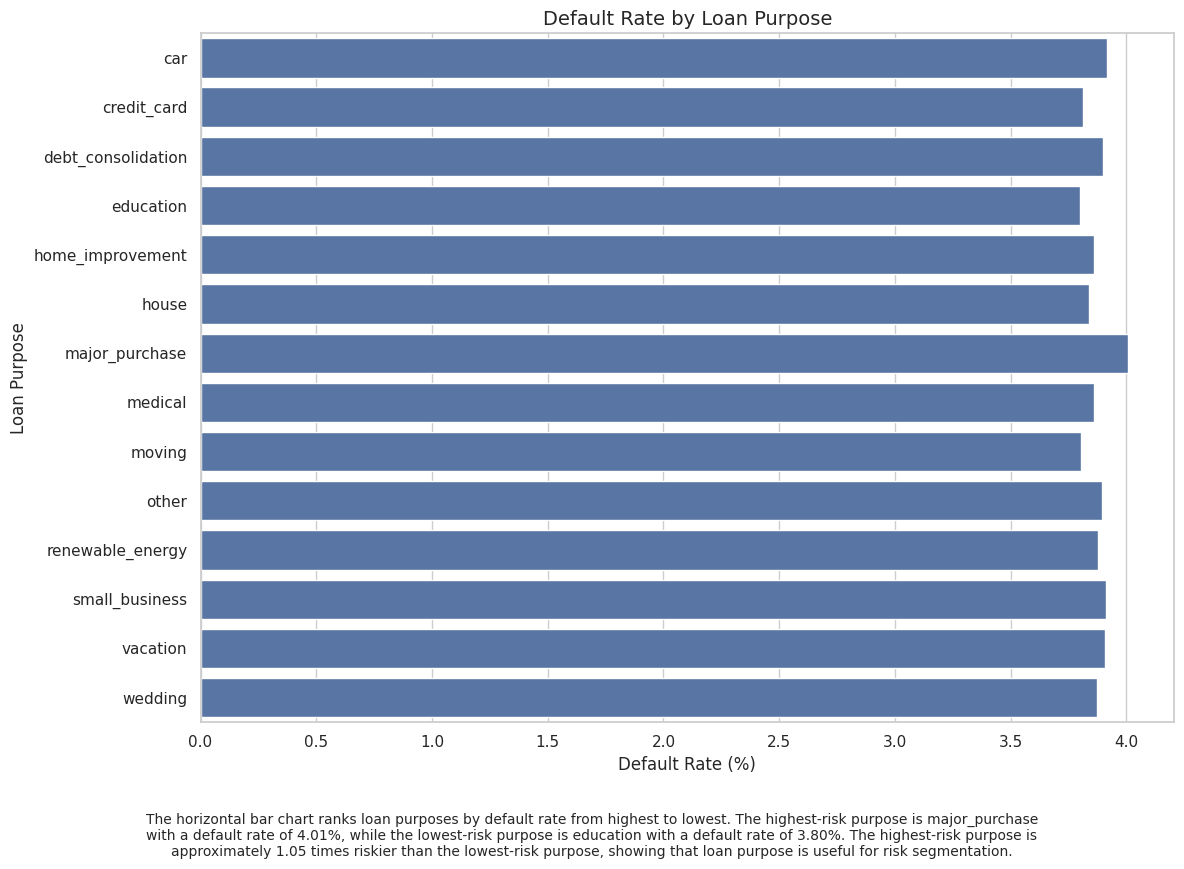

In [ ]:
# Create horizontal bar chart sorted by default rate

plt.figure(figsize=(12, 8))

sns.barplot(
    data=purpose_default_rate,
    x="Default Rate %",
    y="Loan Purpose"
)

plt.title("Default Rate by Loan Purpose", fontsize=14)
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")

# Get names for caption

highest_purpose = purpose_default_rate.iloc[0]["Loan Purpose"]
lowest_purpose = purpose_default_rate.iloc[-1]["Loan Purpose"]

# Add required 3-sentence insight caption

caption = (
    f"The horizontal bar chart ranks loan purposes by default rate from highest to lowest. "
    f"The highest-risk purpose is {highest_purpose} with a default rate of {highest_default_rate:.2f}%, while the lowest-risk purpose is {lowest_purpose} with a default rate of {lowest_default_rate:.2f}%. "
    f"The highest-risk purpose is approximately {purpose_risk_ratio:.2f} times riskier than the lowest-risk purpose, showing that loan purpose is useful for risk segmentation."
)

plt.figtext(
    0.5, -0.08,
    textwrap.fill(caption, width=130),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

#Q2 H

In [ ]:
# Possible names for state column
# Your dataset may use any one of these names.

state_candidates = [
    "state",
    "addr_state",
    "borrower_state",
    "customer_state",
    "residence_state",
    "branch_state",
    "region_state"
]

state_col = find_existing_column(state_candidates, full_df)

print("State column found:", state_col)

State column found: None


In [ ]:
# Bank-wide average default rate
# This is the overall default rate across all loans.

bank_wide_default_rate = full_df["default_flag"].mean() * 100

print("Bank-wide average default rate:", round(bank_wide_default_rate, 4), "%")

Bank-wide average default rate: 3.8778 %


In [ ]:
# Check all column names that contain the word "state"
# This helps us find the real state column name in your dataset.

state_like_cols = [
    col for col in full_df.columns
    if "state" in col.lower()
]

state_like_cols

['state_code',
 'state_per_capita_inc_inr',
 'state_literacy_rate_pct',
 'state_agri_share_pct',
 'state_industry_share_pct',
 'state_services_share_pct']

In [ ]:
# We found that the state identifier column in this dataset is state_code
# So we manually assign it to state_col

state_col = "state_code"

print("Selected state column:", state_col)

Selected state column: state_code


In [ ]:
# Calculate bank-wide average default rate
# Since default_flag = 1 for default and 0 for performing,
# mean(default_flag) gives the default rate.

bank_wide_default_rate = full_df["default_flag"].mean() * 100

print("Bank-wide average default rate:", round(bank_wide_default_rate, 4), "%")

Bank-wide average default rate: 3.8778 %


In [ ]:
# Calculate state-wise default rate
# We group by state_code and calculate count, sum, and mean of default_flag.

state_default_rate = (
    full_df
    .groupby(state_col)["default_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

# Rename columns clearly

state_default_rate.columns = [
    "State",
    "Total Loans",
    "Defaulted Loans",
    "Default Rate"
]

# Convert default rate into percentage

state_default_rate["Default Rate %"] = (
    state_default_rate["Default Rate"] * 100
)

# Calculate how many percentage points each state is above or below bank-wide average

state_default_rate["Above Bank Average By PP"] = (
    state_default_rate["Default Rate %"] - bank_wide_default_rate
)

# Flag states where default rate exceeds bank-wide average by more than 5 percentage points

state_default_rate["Risk Flag"] = np.where(
    state_default_rate["Above Bank Average By PP"] > 5,
    "Flagged",
    "Not Flagged"
)

# Sort states by highest default rate

state_default_rate = state_default_rate.sort_values(
    by="Default Rate %",
    ascending=False
)

# Select top 10 states with highest default rates

top_10_states = state_default_rate.head(10)

top_10_states

,State,Total Loans,Defaulted Loans,Default Rate,Default Rate %,Above Bank Average By PP,Risk Flag
2,BR,36895,1502,0.040710,4.071012,0.193212,Not Flagged
12,OR,37012,1486,0.040149,4.014914,0.137114,Not Flagged
18,UP,148346,5904,0.039799,3.979885,0.102085,Not Flagged
13,PB,55391,2201,0.039736,3.973570,0.095770,Not Flagged
17,UK,36884,1461,0.039611,3.961067,0.083267,Not Flagged
5,HP,37053,1453,0.039214,3.921410,0.043610,Not Flagged
11,MP,92521,3628,0.039213,3.921272,0.043472,Not Flagged
16,TN,167054,6535,0.039119,3.911909,0.034109,Not Flagged
0,AP,74206,2888,0.038919,3.891869,0.014069,Not Flagged
15,TG,92465,3597,0.038901,3.890121,0.012321,Not Flagged


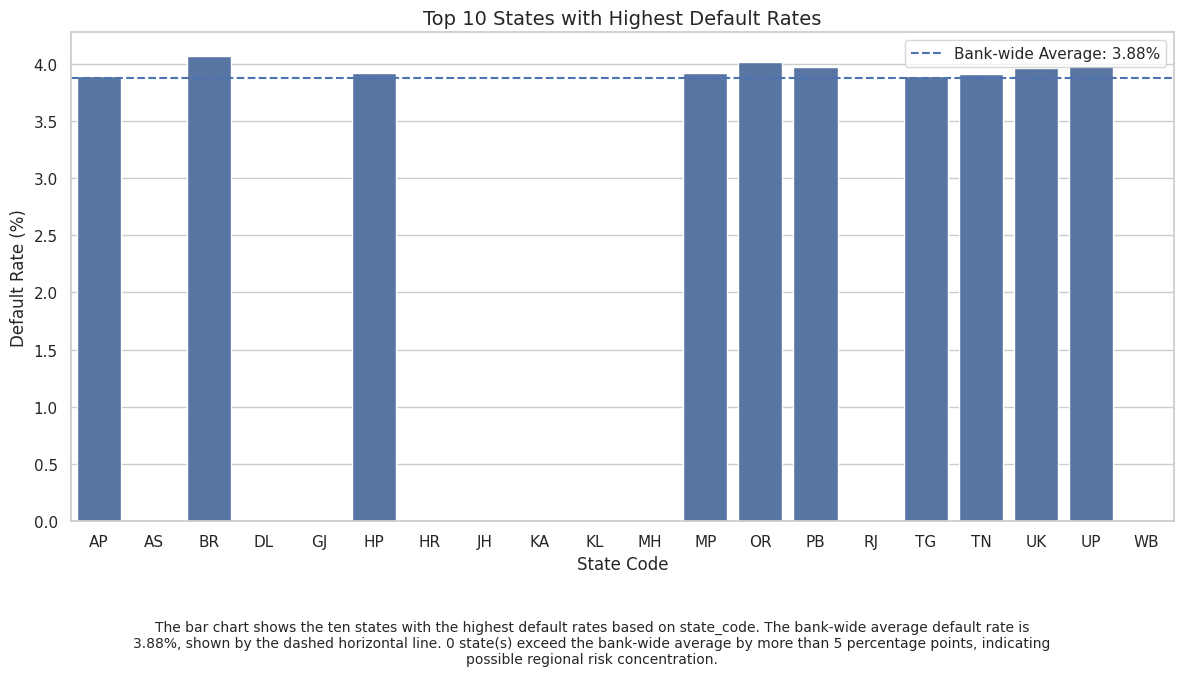

In [ ]:
# Create bar chart for top 10 states by default rate

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_states,
    x="State",
    y="Default Rate %"
)

# Add horizontal line for bank-wide average default rate

plt.axhline(
    bank_wide_default_rate,
    linestyle="--",
    label=f"Bank-wide Average: {bank_wide_default_rate:.2f}%"
)

plt.title("Top 10 States with Highest Default Rates", fontsize=14)
plt.xlabel("State Code")
plt.ylabel("Default Rate (%)")
plt.legend()

# Count flagged states

flagged_state_count = (top_10_states["Risk Flag"] == "Flagged").sum()

# Add 3-sentence insight caption

caption = (
    f"The bar chart shows the ten states with the highest default rates based on state_code. "
    f"The bank-wide average default rate is {bank_wide_default_rate:.2f}%, shown by the dashed horizontal line. "
    f"{flagged_state_count} state(s) exceed the bank-wide average by more than 5 percentage points, indicating possible regional risk concentration."
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=130),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [ ]:
# Display only states whose default rate is more than 5 percentage points above bank average

flagged_states = top_10_states[
    top_10_states["Risk Flag"] == "Flagged"
]

flagged_states

,State,Total Loans,Defaulted Loans,Default Rate,Default Rate %,Above Bank Average By PP,Risk Flag


# Q2 i

In [ ]:
# Helper function to find the first existing column from possible names

def find_existing_column(possible_names, dataframe):
    for col in possible_names:
        if col in dataframe.columns:
            return col
    return None


# Possible date/year columns in the dataset

date_candidates = [
    "issue_date",
    "issue_d",
    "loan_date",
    "disbursement_date",
    "origination_date",
    "application_date",
    "loan_issue_date",
    "year",
    "loan_year"
]

date_col = find_existing_column(date_candidates, full_df)

print("Date/year column found:", date_col)

Date/year column found: issue_date


In [ ]:
# Search for columns that may contain date or year information

date_like_cols = [
    col for col in full_df.columns
    if "date" in col.lower() or "year" in col.lower()
]

date_like_cols

['issue_date',
 'issue_year',
 'property_age_years',
 'vehicle_age_years',
 'valuation_date',
 'loan_approved_date',
 'emp_length_years',
 'credit_hist_years',
 'branch_age_years',
 'loan_officer_exp_years',
 'covid_issue_year_flag',
 'poor_monsoon_year_flag',
 'last_emi_payment_date',
 'emp_length_years_missing_flag']

In [ ]:
# Example:
# Change this column name based on your actual output

date_col = "loan_year"

print("Manually selected date/year column:", date_col)

Manually selected date/year column: loan_year


In [ ]:
# Search all columns that look like date or year columns
# We need this because loan_year does not currently exist in full_df.

date_like_cols = [
    col for col in full_df.columns
    if "date" in col.lower() or "year" in col.lower()
]

date_like_cols

['issue_date',
 'issue_year',
 'property_age_years',
 'vehicle_age_years',
 'valuation_date',
 'loan_approved_date',
 'emp_length_years',
 'credit_hist_years',
 'branch_age_years',
 'loan_officer_exp_years',
 'covid_issue_year_flag',
 'poor_monsoon_year_flag',
 'last_emi_payment_date',
 'emp_length_years_missing_flag']

In [ ]:
# Create loan_year safely
# This code first checks whether loan_year already exists.
# If it does not exist, it searches for another date/year column.

import pandas as pd
import numpy as np

# Step 1: If loan_year already exists, use it.
if "loan_year" in full_df.columns:

    full_df["loan_year"] = pd.to_numeric(
        full_df["loan_year"],
        errors="coerce"
    )

    print("loan_year already existed and was converted to numeric.")

# Step 2: If loan_year does not exist, search for another date/year column.
else:

    date_candidates = [
        "issue_date",
        "issue_d",
        "loan_date",
        "disbursement_date",
        "origination_date",
        "application_date",
        "loan_issue_date",
        "year",
        "issue_year",
        "disbursement_year",
        "origination_year"
    ]

    date_col = None

    for col in date_candidates:
        if col in full_df.columns:
            date_col = col
            break

    # Step 3: If exact names are not found, search any column containing date/year.
    if date_col is None:
        date_like_cols = [
            col for col in full_df.columns
            if "date" in col.lower() or "year" in col.lower()
        ]

        print("Date/year-like columns found:", date_like_cols)

        if len(date_like_cols) > 0:
            date_col = date_like_cols[0]

    print("Selected date/year column:", date_col)

    # Step 4: Stop clearly if no date/year column is found.
    if date_col is None:
        raise ValueError("No date/year column found. Please inspect full_df.columns.tolist().")

    # Step 5: If selected column already contains year, use it directly.
    if "year" in date_col.lower():

        full_df["loan_year"] = pd.to_numeric(
            full_df[date_col],
            errors="coerce"
        )

    # Step 6: Otherwise convert date column to datetime and extract year.
    else:

        full_df[date_col] = pd.to_datetime(
            full_df[date_col],
            errors="coerce"
        )

        full_df["loan_year"] = full_df[date_col].dt.year

# Final check
print("loan_year created successfully.")
print(full_df["loan_year"].value_counts().sort_index())

Selected date/year column: issue_date
loan_year created successfully.
loan_year
2010     79935
2011     80148
2012     99380
2013     99771
2014    120366
2015    140225
2016    140561
2017    139702
2018    140604
2019    139995
2020    139881
2021    159904
2022    180343
2023    179134
2024    160051
Name: count, dtype: int64


/tmp/ipykernel_4805/1931055992.py:71: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  full_df[date_col] = pd.to_datetime(


In [ ]:
# Keep only years from 2010 to 2024 as required in the question

annual_df = full_df[
    (full_df["loan_year"] >= 2010) &
    (full_df["loan_year"] <= 2024)
].copy()

print("Minimum year:", annual_df["loan_year"].min())
print("Maximum year:", annual_df["loan_year"].max())
print("Rows available:", annual_df.shape[0])

Minimum year: 2010
Maximum year: 2024
Rows available: 2000000


In [ ]:
# Calculate annual default rate
# Since default_flag = 1 for defaulted loans and 0 for performing loans,
# mean(default_flag) gives default rate.

annual_default_rate = (
    annual_df
    .groupby("loan_year")["default_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

# Rename columns clearly

annual_default_rate.columns = [
    "Year",
    "Total Loans",
    "Defaulted Loans",
    "Default Rate"
]

# Convert default rate into percentage

annual_default_rate["Default Rate %"] = (
    annual_default_rate["Default Rate"] * 100
)

annual_default_rate

,Year,Total Loans,Defaulted Loans,Default Rate,Default Rate %
0,2010,79935,3083,0.038569,3.856884
1,2011,80148,3160,0.039427,3.942706
2,2012,99380,3686,0.037090,3.708996
3,2013,99771,3710,0.037185,3.718515
4,2014,120366,4436,0.036854,3.685426
5,2015,140225,5209,0.037147,3.714744
6,2016,140561,5369,0.038197,3.819694
7,2017,139702,5353,0.038317,3.831728
8,2018,140604,5410,0.038477,3.847686
9,2019,139995,5782,0.041301,4.130148


In [ ]:
# Extract default rate for 2019 and 2020

rate_2019_series = annual_default_rate.loc[
    annual_default_rate["Year"] == 2019,
    "Default Rate %"
]

rate_2020_series = annual_default_rate.loc[
    annual_default_rate["Year"] == 2020,
    "Default Rate %"
]

# Calculate percentage increase from 2019 to 2020

if len(rate_2019_series) == 0 or len(rate_2020_series) == 0:
    rate_2019 = np.nan
    rate_2020 = np.nan
    covid_shock_pct_increase = np.nan

    print("2019 or 2020 is missing, so COVID shock cannot be calculated.")
else:
    rate_2019 = rate_2019_series.iloc[0]
    rate_2020 = rate_2020_series.iloc[0]

    covid_shock_pct_increase = (
        (rate_2020 - rate_2019) / rate_2019
    ) * 100

    print("Default rate in 2019:", round(rate_2019, 4), "%")
    print("Default rate in 2020:", round(rate_2020, 4), "%")
    print("COVID-19 shock increase:", round(covid_shock_pct_increase, 4), "%")

Default rate in 2019: 4.1301 %
Default rate in 2020: 4.4645 %
COVID-19 shock increase: 8.0956 %


In [ ]:
# Search for macroeconomic variables available in the dataset

macro_keywords = [
    "repo",
    "rbi",
    "income",
    "gdp",
    "unemp",
    "inflation",
    "cpi",
    "literacy",
    "agri",
    "industry",
    "services",
    "economic"
]

macro_cols = []

for col in full_df.columns:
    if any(keyword in col.lower() for keyword in macro_keywords):
        if pd.api.types.is_numeric_dtype(full_df[col]):
            macro_cols.append(col)

macro_cols

['rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'state_literacy_rate_pct',
 'state_agri_share_pct',
 'state_industry_share_pct',
 'state_services_share_pct',
 'district_gdp_growth_pct',
 'emi_to_income_ratio']

In [ ]:
# Compare macroeconomic variables between 2019 and 2020
# This helps identify which economic factor changed during the COVID period.

if len(macro_cols) == 0:
    macro_comparison = pd.DataFrame()
    selected_macro_variable = "No macroeconomic variable detected"

    print("No macroeconomic columns found.")
else:
    macro_comparison = (
        annual_df
        .groupby("loan_year")[macro_cols]
        .mean()
        .reindex([2019, 2020])
        .T
    )

    macro_comparison.columns = ["2019 Average", "2020 Average"]

    macro_comparison["Absolute Change"] = (
        macro_comparison["2020 Average"] -
        macro_comparison["2019 Average"]
    )

    macro_comparison["Percentage Change"] = (
        macro_comparison["Absolute Change"] /
        macro_comparison["2019 Average"]
    ) * 100

    macro_comparison = macro_comparison.sort_values(
        by="Absolute Change",
        ascending=False
    )

macro_comparison

,2019 Average,2020 Average,Absolute Change,Percentage Change
cpi_inflation_pct,4.800000,6.200000,1.400000,29.166658
state_agri_share_pct,16.862738,16.880498,0.017760,0.105324
district_gdp_growth_pct,6.876593,6.879169,0.002576,0.037459
emi_to_income_ratio,0.211526,0.211943,0.000417,0.197073
state_industry_share_pct,28.110754,28.107263,-0.003491,-0.012420
state_services_share_pct,55.026508,55.012239,-0.014269,-0.025931
state_literacy_rate_pct,77.012558,76.995682,-0.016876,-0.021914
rbi_repo_rate_pct,5.150000,4.000000,-1.150000,-22.330099
gdp_growth_pct,4.000000,-6.600000,-10.600000,-264.999998


In [ ]:
# Choose one visible macroeconomic variable for business explanation.
# Priority is given to income or unemployment if available because they directly affect repayment capacity.

priority_macro_cols = [
    "unemployment_rate",
    "state_unemployment_rate",
    "state_per_capita_inc_inr",
    "rbi_repo_rate",
    "rbi_repo_rate_pct",
    "inflation_rate",
    "gdp_growth_rate"
]

selected_macro_variable = None

for col in priority_macro_cols:
    if col in macro_cols:
        selected_macro_variable = col
        break

# If none of the priority columns are present, pick the macro variable with largest absolute change

if selected_macro_variable is None:
    if not macro_comparison.empty:
        selected_macro_variable = macro_comparison["Absolute Change"].abs().idxmax()
    else:
        selected_macro_variable = "No macroeconomic variable detected"

print("Selected macroeconomic variable:", selected_macro_variable)

Selected macroeconomic variable: rbi_repo_rate_pct


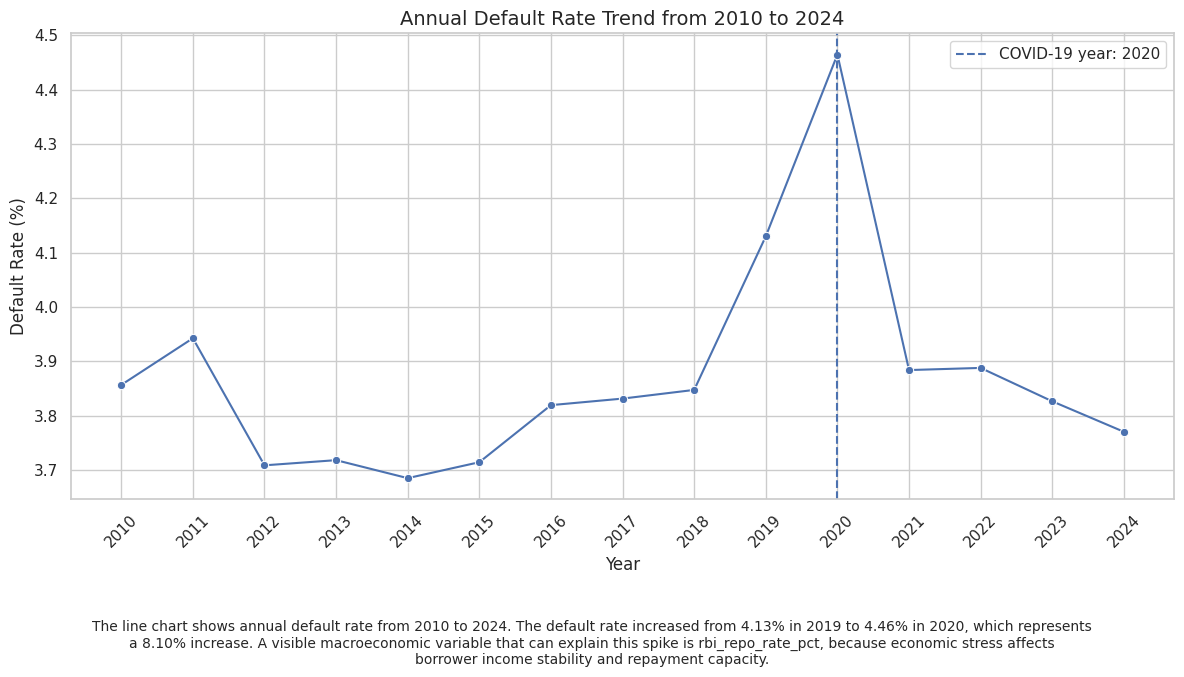

In [ ]:
# Create line chart for annual default rate from 2010 to 2024

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=annual_default_rate,
    x="Year",
    y="Default Rate %",
    marker="o"
)

# Highlight COVID year 2020

plt.axvline(
    2020,
    linestyle="--",
    label="COVID-19 year: 2020"
)

plt.title("Annual Default Rate Trend from 2010 to 2024", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Default Rate (%)")
plt.xticks(range(2010, 2025), rotation=45)
plt.legend()

# Create caption text

caption = (
    f"The line chart shows annual default rate from 2010 to 2024. "
    f"The default rate increased from {rate_2019:.2f}% in 2019 to {rate_2020:.2f}% in 2020, which represents a {covid_shock_pct_increase:.2f}% increase. "
    f"A visible macroeconomic variable that can explain this spike is {selected_macro_variable}, because economic stress affects borrower income stability and repayment capacity."
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=140),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Q2 j

In [ ]:
# Possible repo rate column names

repo_candidates = [
    "rbi_repo_rate",
    "rbi_repo_rate_pct",
    "repo_rate",
    "repo_rate_pct",
    "policy_repo_rate",
    "policy_rate"
]

repo_col = find_existing_column(repo_candidates, full_df)

print("Repo rate column found:", repo_col)

Repo rate column found: rbi_repo_rate_pct


In [ ]:
# Search for columns containing repo or rate

repo_like_cols = [
    col for col in full_df.columns
    if "repo" in col.lower() or "rate" in col.lower()
]

repo_like_cols

['int_rate_pct',
 'rbi_repo_rate_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'rejection_rate_pct',
 'recovery_fee_rate',
 'state_literacy_rate_pct',
 'branch_npa_rate',
 'branch_sanction_rate']

In [ ]:
# Example:
# Change this if your actual repo rate column has a different name

repo_col = "rbi_repo_rate"

print("Manually selected repo column:", repo_col)

Manually selected repo column: rbi_repo_rate


In [ ]:
# Search for columns related to repo rate or interest rate
# This helps us find the actual column name used in your dataset.

repo_like_cols = [
    col for col in full_df.columns
    if "repo" in col.lower() or "rbi" in col.lower() or "rate" in col.lower()
]

repo_like_cols

['int_rate_pct',
 'rbi_repo_rate_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'rejection_rate_pct',
 'recovery_fee_rate',
 'state_literacy_rate_pct',
 'branch_npa_rate',
 'branch_sanction_rate']

In [ ]:
# Check repo/rate-related columns inside annual_df also
# Because Q2(j) uses annual_df for yearly aggregation.

repo_like_cols_annual = [
    col for col in annual_df.columns
    if "repo" in col.lower() or "rbi" in col.lower() or "rate" in col.lower()
]

repo_like_cols_annual

['int_rate_pct',
 'rbi_repo_rate_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'rejection_rate_pct',
 'recovery_fee_rate',
 'state_literacy_rate_pct',
 'branch_npa_rate',
 'branch_sanction_rate']

In [ ]:
# Possible repo rate column names
# We include suffix versions also because after merging, pandas may create _x or _y columns.

repo_candidates = [
    "rbi_repo_rate",
    "rbi_repo_rate_pct",
    "repo_rate",
    "repo_rate_pct",
    "policy_repo_rate",
    "policy_rate",
    "rbi_repo_rate_x",
    "rbi_repo_rate_y",
    "repo_rate_x",
    "repo_rate_y"
]

# First try exact candidate names

repo_col = None

for col in repo_candidates:
    if col in annual_df.columns:
        repo_col = col
        break

# If exact names are not found, search any column containing repo or rbi

if repo_col is None:
    repo_search_cols = [
        col for col in annual_df.columns
        if "repo" in col.lower() or "rbi" in col.lower()
    ]

    if len(repo_search_cols) > 0:
        repo_col = repo_search_cols[0]

print("Repo column selected:", repo_col)

Repo column selected: rbi_repo_rate_pct


In [ ]:
# Create annual summary table
# We calculate yearly default rate and yearly average repo rate.
# default_rate = mean(default_flag)
# avg_repo_rate = average RBI repo rate in that year

annual_repo_default = (
    annual_df
    .groupby("loan_year")
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        avg_repo_rate=(repo_col, "mean")
    )
    .reset_index()
)

# Convert default rate to percentage

annual_repo_default["Default Rate %"] = (
    annual_repo_default["default_rate"] * 100
)

# Rename columns clearly

annual_repo_default = annual_repo_default.rename(
    columns={
        "loan_year": "Year",
        "avg_repo_rate": "RBI Repo Rate"
    }
)

annual_repo_default

,Year,total_loans,defaulted_loans,default_rate,RBI Repo Rate,Default Rate %
0,2010,79935,3083,0.038569,5.25,3.856884
1,2011,80148,3160,0.039427,6.50,3.942706
2,2012,99380,3686,0.037090,8.00,3.708996
3,2013,99771,3710,0.037185,7.75,3.718515
4,2014,120366,4436,0.036854,8.00,3.685426
5,2015,140225,5209,0.037147,6.75,3.714744
6,2016,140561,5369,0.038197,6.25,3.819694
7,2017,139702,5353,0.038317,6.00,3.831728
8,2018,140604,5410,0.038477,6.50,3.847686
9,2019,139995,5782,0.041301,5.15,4.130148


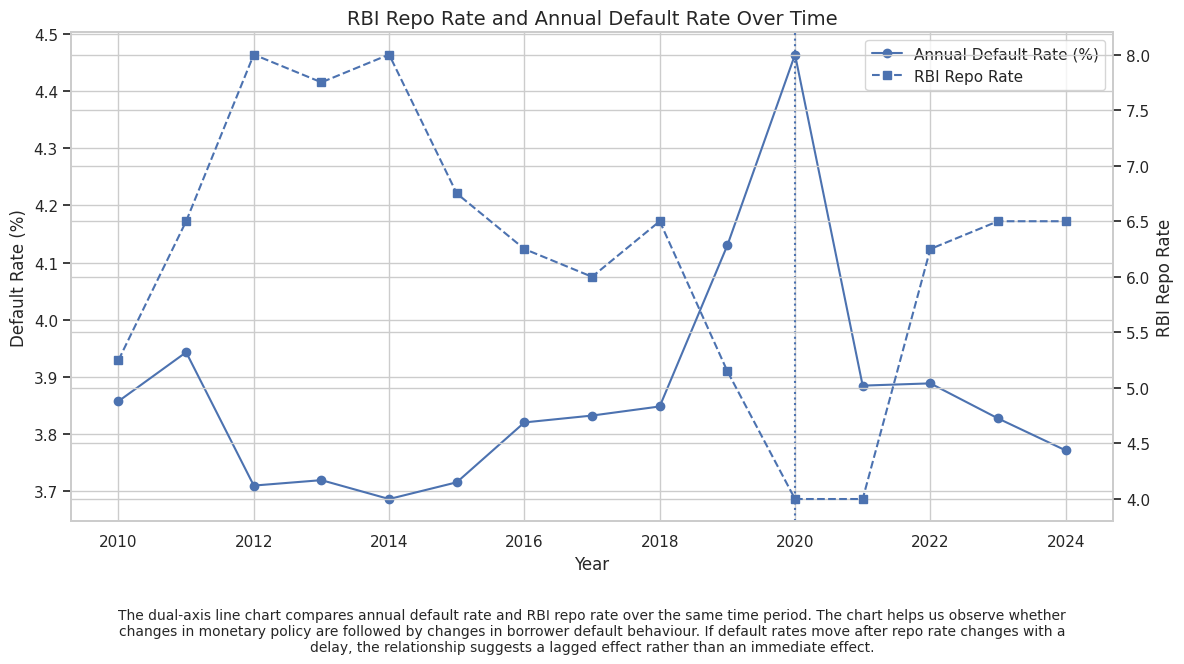

In [ ]:
# Create dual-axis line chart
# Left y-axis shows default rate.
# Right y-axis shows RBI repo rate.

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot annual default rate on first y-axis

ax1.plot(
    annual_repo_default["Year"],
    annual_repo_default["Default Rate %"],
    marker="o",
    label="Annual Default Rate (%)"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Default Rate (%)")

# Create second y-axis for repo rate

ax2 = ax1.twinx()

ax2.plot(
    annual_repo_default["Year"],
    annual_repo_default["RBI Repo Rate"],
    marker="s",
    linestyle="--",
    label="RBI Repo Rate"
)

ax2.set_ylabel("RBI Repo Rate")

# Add title

plt.title("RBI Repo Rate and Annual Default Rate Over Time", fontsize=14)

# Combine legends from both axes

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

# Highlight COVID year

ax1.axvline(
    2020,
    linestyle=":",
    label="COVID-19 Year"
)

# Add 3-sentence caption

caption = (
    "The dual-axis line chart compares annual default rate and RBI repo rate over the same time period. "
    "The chart helps us observe whether changes in monetary policy are followed by changes in borrower default behaviour. "
    "If default rates move after repo rate changes with a delay, the relationship suggests a lagged effect rather than an immediate effect."
)

fig.text(
    0.5, -0.10,
    textwrap.fill(caption, width=140),
    ha="center",
    fontsize=10
)

fig.tight_layout()
plt.show()

In [ ]:
# Estimate lag between repo rate and default rate
# Since this is yearly data, lag is measured in years.
# lag = 0 means same-year relationship.
# lag = 1 means previous year's repo rate may affect current year's default rate.

lag_results = []

for lag in range(0, 4):

    temp = annual_repo_default.copy()

    # Shift repo rate by lag years

    temp[f"Repo Rate Lag {lag}"] = temp["RBI Repo Rate"].shift(lag)

    # Calculate correlation between default rate and lagged repo rate

    corr_value = temp["Default Rate %"].corr(
        temp[f"Repo Rate Lag {lag}"]
    )

    lag_results.append({
        "Lag Years": lag,
        "Lag Months": lag * 12,
        "Correlation With Default Rate": corr_value
    })

lag_report = pd.DataFrame(lag_results)

lag_report

,Lag Years,Lag Months,Correlation With Default Rate
0,0,0,-0.749791
1,1,12,-0.477653
2,2,24,-0.122915
3,3,36,-0.046657


In [ ]:
# Find the lag with strongest absolute correlation

lag_report_clean = lag_report.dropna().copy()

best_lag_row = lag_report_clean.loc[
    lag_report_clean["Correlation With Default Rate"].abs().idxmax()
]

best_lag_years = best_lag_row["Lag Years"]
best_lag_months = best_lag_row["Lag Months"]
best_lag_corr = best_lag_row["Correlation With Default Rate"]

print("Estimated lag:", int(best_lag_years), "year(s)")
print("Estimated lag in months:", int(best_lag_months), "months")
print("Correlation at estimated lag:", round(best_lag_corr, 4))

Estimated lag: 0 year(s)
Estimated lag in months: 0 months
Correlation at estimated lag: -0.7498


# Q2 k

In [ ]:
# Helper function to find the first existing column from a list of possible names

def find_existing_column(possible_names, dataframe):
    for col in possible_names:
        if col in dataframe.columns:
            return col
    return None


# Possible LGD column names
# LGD means Loss Given Default.
# It may be written as lgd_pct, lgd_percent, loss_given_default, etc.

lgd_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_candidates, full_df)

print("LGD column found:", lgd_col)

LGD column found: lgd_pct


In [ ]:
# Helper function to find the first existing column from a list of possible names

def find_existing_column(possible_names, dataframe):
    for col in possible_names:
        if col in dataframe.columns:
            return col
    return None


# Possible LGD column names
# LGD means Loss Given Default.
# It may be written as lgd_pct, lgd_percent, loss_given_default, etc.

lgd_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_candidates, full_df)

print("LGD column found:", lgd_col)

LGD column found: lgd_pct


In [ ]:
# Filter only defaulted loans
# LGD is mainly meaningful for loans that actually defaulted.

defaulted_lgd_df = full_df[
    full_df["default_flag"] == 1
].copy()

# Keep only rows where LGD value is available

defaulted_lgd = defaulted_lgd_df[lgd_col].dropna()

# Basic LGD summary

defaulted_lgd.describe()

count    77556.000000
mean        40.111443
std         19.983067
min          5.000000
25%         24.430000
50%         38.660000
75%         54.529999
max         95.000000
Name: lgd_pct, dtype: float64

In [ ]:
# Calculate skewness of LGD distribution
# Positive skew means right-skewed.
# Negative skew means left-skewed.

lgd_skewness = defaulted_lgd.skew()

# Calculate mean and median for shape understanding

lgd_mean = defaulted_lgd.mean()
lgd_median = defaulted_lgd.median()

print("LGD mean:", round(lgd_mean, 4))
print("LGD median:", round(lgd_median, 4))
print("LGD skewness:", round(lgd_skewness, 4))

LGD mean: 40.1114
LGD median: 38.66
LGD skewness: 0.2883


In [ ]:
# Import functions needed for KDE and peak detection

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

# For very large data, take sample to make KDE faster

lgd_sample = defaulted_lgd.sample(
    n=min(50000, len(defaulted_lgd)),
    random_state=42
)

# Create x-axis grid for KDE

x_min = lgd_sample.min()
x_max = lgd_sample.max()
x_grid = np.linspace(x_min, x_max, 1000)

# Estimate KDE density

kde_lgd = gaussian_kde(lgd_sample)
density_lgd = kde_lgd(x_grid)

# Find peaks in the KDE curve
# A peak means one high-density area in the distribution.

peaks, properties = find_peaks(
    density_lgd,
    prominence=density_lgd.max() * 0.05
)

num_peaks = len(peaks)

print("Number of KDE peaks detected:", num_peaks)

Number of KDE peaks detected: 1


In [ ]:
# Classify distribution shape based on peaks and skewness

if num_peaks >= 2:
    lgd_shape = "bimodal or multimodal"
elif lgd_skewness > 1:
    lgd_shape = "right-skewed and mostly unimodal"
elif lgd_skewness < -1:
    lgd_shape = "left-skewed and mostly unimodal"
else:
    lgd_shape = "approximately unimodal with mild skewness"

print("LGD distribution shape:", lgd_shape)

LGD distribution shape: approximately unimodal with mild skewness


In [ ]:
# Check whether log transformation is warranted
# LGD is a percentage, so it is naturally bounded.
# Log transformation is usually not preferred blindly for bounded percentage variables.

if lgd_skewness > 2 and (defaulted_lgd >= 0).all():
    log_transform_decision = (
        "Log transformation may reduce strong right skew, but it should be used cautiously because LGD is a bounded percentage variable."
    )
else:
    log_transform_decision = (
        "Log transformation is not strongly warranted because LGD is a bounded percentage variable and does not show extreme right skew above 2.0."
    )

print(log_transform_decision)

Log transformation is not strongly warranted because LGD is a bounded percentage variable and does not show extreme right skew above 2.0.


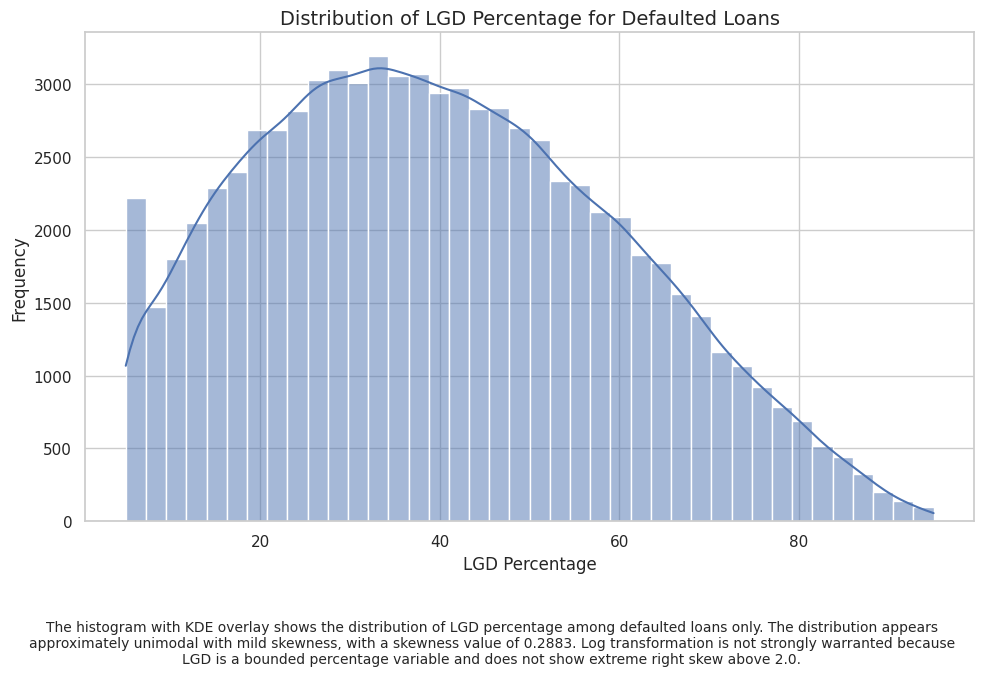

In [ ]:
# Plot histogram with KDE overlay for LGD percentage on defaulted loans only

plt.figure(figsize=(10, 6))

sns.histplot(
    defaulted_lgd,
    bins=40,
    kde=True
)

plt.title("Distribution of LGD Percentage for Defaulted Loans", fontsize=14)
plt.xlabel("LGD Percentage")
plt.ylabel("Frequency")

# Add required 3-sentence insight caption

caption = (
    f"The histogram with KDE overlay shows the distribution of LGD percentage among defaulted loans only. "
    f"The distribution appears {lgd_shape}, with a skewness value of {lgd_skewness:.4f}. "
    f"{log_transform_decision}"
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=130),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Q2 l

In [ ]:
# Prepare data for CIBIL score vs LGD analysis
# LGD is meaningful mainly for defaulted loans, so we use defaulted loans with non-missing CIBIL and LGD.

scatter_df = full_df[
    full_df["default_flag"] == 1
][["cibil_score", lgd_col]].dropna().copy()

# Rename LGD column for cleaner use

scatter_df = scatter_df.rename(
    columns={
        lgd_col: "lgd_pct"
    }
)

# Check size and first few rows

print("Rows available for scatter plot:", scatter_df.shape[0])
scatter_df.head()

Rows available for scatter plot: 77556


,cibil_score,lgd_pct
26,663,73.089996
28,667,7.030000
94,713,23.350000
99,767,47.930000
115,613,53.240002


In [ ]:
# Import Pearson correlation function

from scipy.stats import pearsonr

# Calculate Pearson r and p-value

pearson_r, pearson_p_value = pearsonr(
    scatter_df["cibil_score"],
    scatter_df["lgd_pct"]
)

print("Pearson r:", round(pearson_r, 4))
print("P-value:", pearson_p_value)

Pearson r: 0.0018
P-value: 0.6227709


In [ ]:
# Interpret strength of correlation based on absolute r value

abs_r = abs(pearson_r)

if abs_r < 0.10:
    strength = "very weak"
elif abs_r < 0.30:
    strength = "weak"
elif abs_r < 0.50:
    strength = "moderate"
elif abs_r < 0.70:
    strength = "strong"
else:
    strength = "very strong"

# Interpret direction

if pearson_r > 0:
    direction = "positive"
    direction_meaning = "higher CIBIL scores are associated with higher LGD percentage"
elif pearson_r < 0:
    direction = "negative"
    direction_meaning = "higher CIBIL scores are associated with lower LGD percentage"
else:
    direction = "no linear"
    direction_meaning = "CIBIL score does not show a linear relationship with LGD percentage"

print("Direction:", direction)
print("Strength:", strength)
print("Meaning:", direction_meaning)

Direction: positive
Strength: very weak
Meaning: higher CIBIL scores are associated with higher LGD percentage


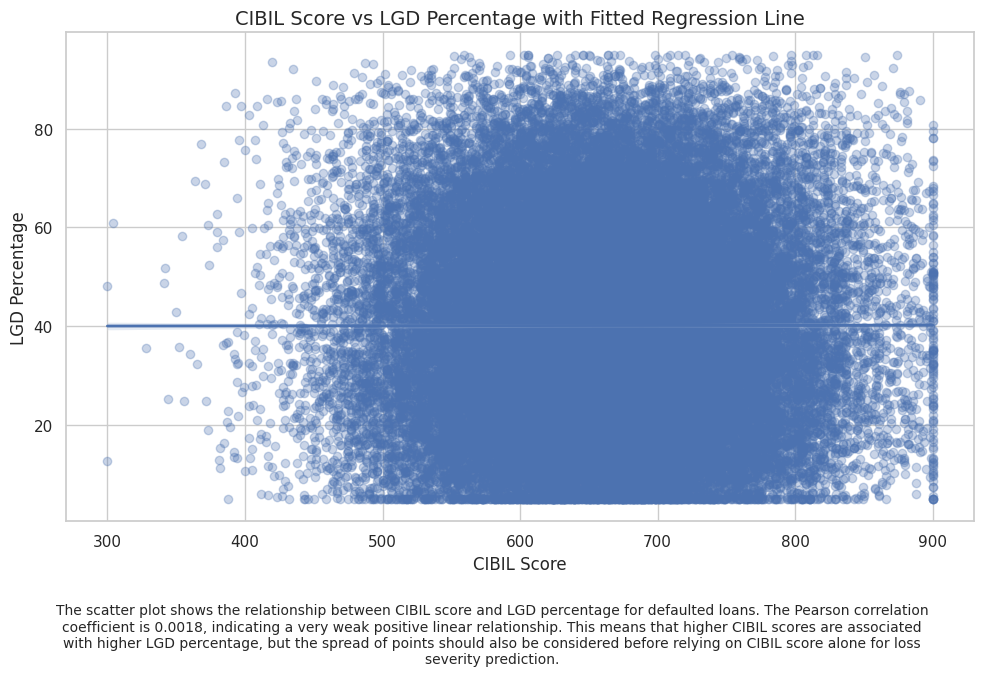

In [ ]:
# Create sample for plotting if the dataset is very large
# Regression line is fitted visually using seaborn regplot.

scatter_sample = scatter_df.sample(
    n=min(50000, len(scatter_df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.regplot(
    data=scatter_sample,
    x="cibil_score",
    y="lgd_pct",
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2}
)

plt.title("CIBIL Score vs LGD Percentage with Fitted Regression Line", fontsize=14)
plt.xlabel("CIBIL Score")
plt.ylabel("LGD Percentage")

# Add required 3-sentence insight caption

caption = (
    f"The scatter plot shows the relationship between CIBIL score and LGD percentage for defaulted loans. "
    f"The Pearson correlation coefficient is {pearson_r:.4f}, indicating a {strength} {direction} linear relationship. "
    f"This means that {direction_meaning}, but the spread of points should also be considered before relying on CIBIL score alone for loss severity prediction."
)

plt.figtext(
    0.5, -0.12,
    textwrap.fill(caption, width=130),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

# Q 3

In [ ]:
full_df.shape

(2000000, 193)

In [ ]:
# Helper function:
# It checks multiple possible column names and returns the first one found in full_df.

def find_existing_column(possible_names, dataframe):
    for col in possible_names:
        if col in dataframe.columns:
            return col
    return None

In [ ]:
# Find LGD target column
# LGD means Loss Given Default.
# The question asks us to compute correlation of engineered features with lgd_pct.

lgd_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_candidates, full_df)

print("LGD target column found:", lgd_col)

LGD target column found: lgd_pct


In [ ]:
# Search columns containing lgd or loss

[col for col in full_df.columns if "lgd" in col.lower() or "loss" in col.lower()]

['net_loss_inr', 'lgd_pct', 'expected_loss_inr']

In [ ]:
# Find required columns for feature engineering

col_map = {
    "installment_inr": find_existing_column(
        ["installment_inr", "installment", "emi_inr", "monthly_installment"],
        full_df
    ),

    "annual_inc_inr": find_existing_column(
        ["annual_inc_inr", "annual_inc", "annual_income", "annual_income_inr"],
        full_df
    ),

    "loan_amnt_inr": find_existing_column(
        ["loan_amnt_inr", "loan_amnt", "loan_amount", "loan_amount_inr"],
        full_df
    ),

    "int_rate_pct": find_existing_column(
        ["int_rate_pct", "int_rate", "interest_rate", "interest_rate_pct"],
        full_df
    ),

    "rbi_repo_rate_pct": find_existing_column(
        ["rbi_repo_rate_pct", "rbi_repo_rate", "repo_rate_pct", "repo_rate", "policy_repo_rate"],
        full_df
    ),

    "cpi_inflation_pct": find_existing_column(
        ["cpi_inflation_pct", "cpi_inflation", "inflation_rate", "inflation_pct", "cpi"],
        full_df
    ),

    "revol_util": find_existing_column(
        ["revol_util", "revol_util_pct", "revolving_utilization", "revol_utilization_pct"],
        full_df
    ),

    "bc_util": find_existing_column(
        ["bc_util", "bc_util_pct", "bankcard_util", "bankcard_util_pct"],
        full_df
    ),

    "all_util": find_existing_column(
        ["all_util", "all_util_pct", "total_util", "overall_util_pct"],
        full_df
    ),

    "delinq_2yrs": find_existing_column(
        ["delinq_2yrs", "delinquencies_2yrs", "num_delinq_2yrs"],
        full_df
    ),

    "mths_since_last_delinq": find_existing_column(
        ["mths_since_last_delinq", "months_since_last_delinq", "mths_last_delinq"],
        full_df
    ),

    "num_enquiries_30d": find_existing_column(
        ["num_enquiries_30d", "inq_30d", "enquiries_30d", "num_inquiries_30d"],
        full_df
    ),

    "num_enquiries_90d": find_existing_column(
        ["num_enquiries_90d", "inq_90d", "enquiries_90d", "num_inquiries_90d"],
        full_df
    )
}

col_map

{'installment_inr': 'installment_inr',
 'annual_inc_inr': 'annual_inc_inr',
 'loan_amnt_inr': 'loan_amnt_inr',
 'int_rate_pct': 'int_rate_pct',
 'rbi_repo_rate_pct': 'rbi_repo_rate_pct',
 'cpi_inflation_pct': 'cpi_inflation_pct',
 'revol_util': 'revol_util_pct',
 'bc_util': 'bc_util_pct',
 'all_util': 'all_util_pct',
 'delinq_2yrs': 'delinq_2yrs',
 'mths_since_last_delinq': 'mths_since_last_delinq',
 'num_enquiries_30d': 'num_enquiries_30d',
 'num_enquiries_90d': 'num_enquiries_90d'}

In [ ]:
# Check which required columns were not found

missing_required_cols = {
    key: value
    for key, value in col_map.items()
    if value is None
}

missing_required_cols

{}

In [ ]:
# Show all columns to manually inspect names

full_df.columns.tolist()

['loan_id',
 'issue_date',
 'issue_year',
 'issue_month',
 'loan_amnt_inr',
 'funded_amnt_inr',
 'loan_term_months',
 'int_rate_pct',
 'installment_inr',
 'annual_installment_inr',
 'grade',
 'sub_grade',
 'loan_purpose',
 'state_code',
 'region',
 'urban_index',
 'application_type',
 'pymnt_plan',
 'hardship_flag',
 'initial_list_status',
 'disbursement_method',
 'verification_status',
 'rbi_repo_rate_pct',
 'gdp_growth_pct',
 'cpi_inflation_pct',
 'rate_spread_pct',
 'real_interest_rate_pct',
 'has_collateral',
 'collateral_type',
 'collateral_value_inr',
 'ltv_ratio_pct',
 'loan_secured_flag',
 'property_type',
 'property_age_years',
 'property_area_sqft',
 'property_city_tier',
 'vehicle_type',
 'vehicle_age_years',
 'insurance_flag',
 'valuation_date',
 'valuation_agency',
 'charge_type',
 'collateral_score',
 'prop_value_inr',
 'vehicle_value_inr',
 'business_asset_val_inr',
 'num_enquiries_30d',
 'num_enquiries_90d',
 'num_enquiries_6m',
 'num_enquiries_12m',
 'num_enquiries_24m

# Q3 a

In [ ]:
# Create monthly income
# annual income / 12 gives estimated monthly income.
# We replace 0 annual income with NaN to avoid division by zero.

monthly_income = full_df[col_map["annual_inc_inr"]].replace(0, np.nan) / 12

# Feature 1: EMI to income ratio
# Formula: installment_inr / monthly income

full_df["emi_to_income_ratio"] = (
    full_df[col_map["installment_inr"]] / monthly_income
)

In [ ]:
# Feature 2: Loan to income ratio
# Formula: loan amount / annual income
# We replace 0 annual income with NaN to avoid division by zero.

full_df["loan_to_income_ratio"] = (
    full_df[col_map["loan_amnt_inr"]] /
    full_df[col_map["annual_inc_inr"]].replace(0, np.nan)
)

In [ ]:
# Feature 3: Rate spread percentage
# Formula: borrower interest rate - RBI repo rate

full_df["rate_spread_pct"] = (
    full_df[col_map["int_rate_pct"]] -
    full_df[col_map["rbi_repo_rate_pct"]]
)

In [ ]:
# Feature 4: Real interest rate
# Formula: borrower interest rate - inflation rate

full_df["real_interest_rate"] = (
    full_df[col_map["int_rate_pct"]] -
    full_df[col_map["cpi_inflation_pct"]]
)

In [ ]:
# List of Q3(a) engineered features

repayment_features = [
    "emi_to_income_ratio",
    "loan_to_income_ratio",
    "rate_spread_pct",
    "real_interest_rate"
]

# Verify output using describe()

full_df[repayment_features].describe().T

,count,mean,std,min,25%,50%,75%,max
emi_to_income_ratio,1959934.0,0.214747,0.330351,0.000488,0.052200,0.11401,0.245792,28.584506
loan_to_income_ratio,1959934.0,0.551631,0.746330,0.002500,0.147867,0.31341,0.651524,33.858210
rate_spread_pct,2000000.0,7.424291,4.526865,-1.000000,3.920000,6.77000,10.420000,24.000000
real_interest_rate,2000000.0,7.639756,4.813152,-3.900000,4.150000,7.11000,10.809999,24.600000


In [ ]:
# Function to calculate Pearson correlation safely
# It removes missing and infinite values before computing correlation.

def safe_pearson_corr(dataframe, feature_col, target_col):

    temp = dataframe[[feature_col, target_col]].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    if temp.shape[0] < 2:
        return np.nan

    corr_value = temp[feature_col].corr(temp[target_col])

    return corr_value

In [ ]:
# Calculate Pearson correlation of repayment features with LGD target

repayment_corr_report = []

for feature in repayment_features:

    corr_value = safe_pearson_corr(
        full_df,
        feature,
        lgd_col
    )

    repayment_corr_report.append({
        "Feature": feature,
        "Formula": "",
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

repayment_corr_report_df = pd.DataFrame(repayment_corr_report)

repayment_corr_report_df = repayment_corr_report_df.sort_values(
    by="Absolute Correlation",
    ascending=False
)

repayment_corr_report_df

,Feature,Formula,Pearson Correlation with LGD,Absolute Correlation
2,rate_spread_pct,,0.079458,0.079458
3,real_interest_rate,,0.073429,0.073429
0,emi_to_income_ratio,,0.005366,0.005366
1,loan_to_income_ratio,,0.002612,0.002612


In [ ]:
# Create formula and domain rationale table for Q3(a)

repayment_feature_documentation = pd.DataFrame([
    {
        "Feature": "emi_to_income_ratio",
        "Formula": "installment_inr / (annual_inc_inr / 12)",
        "Domain Rationale": "A higher EMI-to-income ratio means a larger part of monthly income is used for repayment. This increases repayment stress and may increase loss severity if default occurs."
    },
    {
        "Feature": "loan_to_income_ratio",
        "Formula": "loan_amnt_inr / annual_inc_inr",
        "Domain Rationale": "A larger loan relative to income indicates higher leverage. High leverage can make recovery harder and may be linked with higher LGD."
    },
    {
        "Feature": "rate_spread_pct",
        "Formula": "int_rate_pct - rbi_repo_rate_pct",
        "Domain Rationale": "Rate spread captures the extra risk premium charged above the policy rate. A higher spread may indicate that the bank already considers the borrower riskier."
    },
    {
        "Feature": "real_interest_rate",
        "Formula": "int_rate_pct - cpi_inflation_pct",
        "Domain Rationale": "Real interest rate adjusts the borrower’s interest burden for inflation. A higher real rate means greater real repayment pressure."
    }
])

repayment_feature_documentation

,Feature,Formula,Domain Rationale
0,emi_to_income_ratio,installment_inr / (annual_inc_inr / 12),A higher EMI-to-income ratio means a larger pa...
1,loan_to_income_ratio,loan_amnt_inr / annual_inc_inr,A larger loan relative to income indicates hig...
2,rate_spread_pct,int_rate_pct - rbi_repo_rate_pct,Rate spread captures the extra risk premium ch...
3,real_interest_rate,int_rate_pct - cpi_inflation_pct,Real interest rate adjusts the borrower’s inte...


In [ ]:
# Combine documentation with correlation output

repayment_final_report = repayment_feature_documentation.merge(
    repayment_corr_report_df[["Feature", "Pearson Correlation with LGD"]],
    on="Feature",
    how="left"
)

repayment_final_report

,Feature,Formula,Domain Rationale,Pearson Correlation with LGD
0,emi_to_income_ratio,installment_inr / (annual_inc_inr / 12),A higher EMI-to-income ratio means a larger pa...,0.005366
1,loan_to_income_ratio,loan_amnt_inr / annual_inc_inr,A larger loan relative to income indicates hig...,0.002612
2,rate_spread_pct,int_rate_pct - rbi_repo_rate_pct,Rate spread captures the extra risk premium ch...,0.079458
3,real_interest_rate,int_rate_pct - cpi_inflation_pct,Real interest rate adjusts the borrower’s inte...,0.073429


In [ ]:
# Identify repayment feature with strongest correlation with LGD

strongest_repayment_feature = repayment_corr_report_df.iloc[0]["Feature"]
strongest_repayment_corr = repayment_corr_report_df.iloc[0]["Pearson Correlation with LGD"]

print("Strongest repayment-burden feature:", strongest_repayment_feature)
print("Pearson correlation with LGD:", round(strongest_repayment_corr, 4))

Strongest repayment-burden feature: rate_spread_pct
Pearson correlation with LGD: 0.0795


# Q3 B

In [ ]:
# Feature 5: Credit utilization composite
# Formula: 0.5*revol_util + 0.3*bc_util + 0.2*all_util
# This gives highest weight to revolving utilization because it is highly relevant in credit-risk behaviour.

full_df["credit_util_composite"] = (
    0.5 * full_df[col_map["revol_util"]] +
    0.3 * full_df[col_map["bc_util"]] +
    0.2 * full_df[col_map["all_util"]]
)

In [ ]:
# Feature 6: Delinquency severity score
# Formula: delinq_2yrs * (1 + 1 / max(mths_since_last_delinq, 1))
# We use np.maximum() so months_since_last_delinq is never below 1.
# This avoids division by zero and gives higher weight to recent delinquencies.

months_since_delinq_safe = np.maximum(
    full_df[col_map["mths_since_last_delinq"]].fillna(999),
    1
)

full_df["delinq_severity_score"] = (
    full_df[col_map["delinq_2yrs"]].fillna(0) *
    (1 + 1 / months_since_delinq_safe)
)

In [ ]:
# Feature 7: Enquiry velocity score
# Formula: num_enquiries_30d * 4 + num_enquiries_90d
# Recent 30-day enquiries are weighted more heavily because they indicate sudden credit-seeking behaviour.

full_df["enq_velocity_score"] = (
    full_df[col_map["num_enquiries_30d"]].fillna(0) * 4 +
    full_df[col_map["num_enquiries_90d"]].fillna(0)
)

In [ ]:
# List of Q3(b) engineered features

bureau_features = [
    "credit_util_composite",
    "delinq_severity_score",
    "enq_velocity_score"
]

# Verify output using describe()

full_df[bureau_features].describe().T

,count,mean,std,min,25%,50%,75%,max
credit_util_composite,1766333.0,40.522831,11.894800,3.8,32.02,40.0,48.540001,90.82
delinq_severity_score,2000000.0,1.105572,1.745018,0.0,0.00,0.0,1.500000,14.00
enq_velocity_score,2000000.0,8.246155,7.912270,0.0,2.00,6.0,12.000000,39.00


In [ ]:
# Calculate Pearson correlation of bureau-behaviour features with LGD

bureau_corr_report = []

for feature in bureau_features:

    corr_value = safe_pearson_corr(
        full_df,
        feature,
        lgd_col
    )

    bureau_corr_report.append({
        "Feature": feature,
        "Formula": "",
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

bureau_corr_report_df = pd.DataFrame(bureau_corr_report)

bureau_corr_report_df = bureau_corr_report_df.sort_values(
    by="Absolute Correlation",
    ascending=False
)

bureau_corr_report_df

,Feature,Formula,Pearson Correlation with LGD,Absolute Correlation
1,delinq_severity_score,,0.017319,0.017319
0,credit_util_composite,,0.003765,0.003765
2,enq_velocity_score,,0.000491,0.000491


In [ ]:
# Create formula and domain rationale table for Q3(b)

bureau_feature_documentation = pd.DataFrame([
    {
        "Feature": "credit_util_composite",
        "Formula": "0.5*revol_util + 0.3*bc_util + 0.2*all_util",
        "Domain Rationale": "High credit utilization indicates that a borrower is using a large share of available credit. This may signal financial stress and higher repayment risk."
    },
    {
        "Feature": "delinq_severity_score",
        "Formula": "delinq_2yrs * (1 + 1 / max(mths_since_last_delinq, 1))",
        "Domain Rationale": "This feature combines delinquency count with recency. A recent delinquency is more concerning than an old delinquency because it better reflects current repayment behaviour."
    },
    {
        "Feature": "enq_velocity_score",
        "Formula": "num_enquiries_30d*4 + num_enquiries_90d",
        "Domain Rationale": "A sudden increase in credit enquiries may indicate urgent credit need or liquidity stress. The 30-day enquiries are weighted more heavily because very recent credit-seeking behaviour is more risky."
    }
])

bureau_feature_documentation

,Feature,Formula,Domain Rationale
0,credit_util_composite,0.5*revol_util + 0.3*bc_util + 0.2*all_util,High credit utilization indicates that a borro...
1,delinq_severity_score,delinq_2yrs * (1 + 1 / max(mths_since_last_del...,This feature combines delinquency count with r...
2,enq_velocity_score,num_enquiries_30d*4 + num_enquiries_90d,A sudden increase in credit enquiries may indi...


In [ ]:
# Combine documentation with correlation output

bureau_final_report = bureau_feature_documentation.merge(
    bureau_corr_report_df[["Feature", "Pearson Correlation with LGD"]],
    on="Feature",
    how="left"
)

bureau_final_report

,Feature,Formula,Domain Rationale,Pearson Correlation with LGD
0,credit_util_composite,0.5*revol_util + 0.3*bc_util + 0.2*all_util,High credit utilization indicates that a borro...,0.003765
1,delinq_severity_score,delinq_2yrs * (1 + 1 / max(mths_since_last_del...,This feature combines delinquency count with r...,0.017319
2,enq_velocity_score,num_enquiries_30d*4 + num_enquiries_90d,A sudden increase in credit enquiries may indi...,0.000491


In [ ]:
# Combine all seven engineered feature reports

q3_ab_final_report = pd.concat(
    [
        repayment_final_report,
        bureau_final_report
    ],
    ignore_index=True
)

q3_ab_final_report

,Feature,Formula,Domain Rationale,Pearson Correlation with LGD
0,emi_to_income_ratio,installment_inr / (annual_inc_inr / 12),A higher EMI-to-income ratio means a larger pa...,0.005366
1,loan_to_income_ratio,loan_amnt_inr / annual_inc_inr,A larger loan relative to income indicates hig...,0.002612
2,rate_spread_pct,int_rate_pct - rbi_repo_rate_pct,Rate spread captures the extra risk premium ch...,0.079458
3,real_interest_rate,int_rate_pct - cpi_inflation_pct,Real interest rate adjusts the borrower’s inte...,0.073429
4,credit_util_composite,0.5*revol_util + 0.3*bc_util + 0.2*all_util,High credit utilization indicates that a borro...,0.003765
5,delinq_severity_score,delinq_2yrs * (1 + 1 / max(mths_since_last_del...,This feature combines delinquency count with r...,0.017319
6,enq_velocity_score,num_enquiries_30d*4 + num_enquiries_90d,A sudden increase in credit enquiries may indi...,0.000491


In [ ]:
# Verify all seven engineered features together using describe()

engineered_features_ab = repayment_features + bureau_features

full_df[engineered_features_ab].describe().T

,count,mean,std,min,25%,50%,75%,max
emi_to_income_ratio,1959934.0,0.214747,0.330351,0.000488,0.052200,0.11401,0.245792,28.584506
loan_to_income_ratio,1959934.0,0.551631,0.746330,0.002500,0.147867,0.31341,0.651524,33.858210
rate_spread_pct,2000000.0,7.424291,4.526865,-1.000000,3.920000,6.77000,10.420000,24.000000
real_interest_rate,2000000.0,7.639756,4.813152,-3.900000,4.150000,7.11000,10.809999,24.600000
credit_util_composite,1766333.0,40.522831,11.894800,3.800000,32.020000,40.00000,48.540001,90.820000
delinq_severity_score,2000000.0,1.105572,1.745018,0.000000,0.000000,0.00000,1.500000,14.000000
enq_velocity_score,2000000.0,8.246155,7.912270,0.000000,2.000000,6.00000,12.000000,39.000000


# Q3 C

In [ ]:
# Helper function:
# This function finds the first matching column name from a list of possible names.

def find_existing_column(possible_names, dataframe):
    for col in possible_names:
        if col in dataframe.columns:
            return col
    return None

In [ ]:
# Find required columns for Q3(c)

q3c_col_map = {
    "annual_inc_inr": find_existing_column(
        ["annual_inc_inr", "annual_inc", "annual_income", "annual_income_inr"],
        full_df
    ),

    "emp_length_years": find_existing_column(
        ["emp_length_years", "emp_length", "employment_length_years"],
        full_df
    ),

    "total_acc": find_existing_column(
        ["total_acc", "total_accounts", "total_credit_accounts"],
        full_df
    ),

    "credit_hist_years": find_existing_column(
        ["credit_hist_years", "credit_history_years", "credit_age_years"],
        full_df
    ),

    "collateral_value_inr": find_existing_column(
        ["collateral_value_inr", "collateral_value", "asset_value_inr", "secured_asset_value_inr"],
        full_df
    ),

    "loan_amnt_inr": find_existing_column(
        ["loan_amnt_inr", "loan_amnt", "loan_amount", "loan_amount_inr"],
        full_df
    )
}

q3c_col_map

{'annual_inc_inr': 'annual_inc_inr',
 'emp_length_years': 'emp_length_years',
 'total_acc': 'total_acc',
 'credit_hist_years': 'credit_hist_years',
 'collateral_value_inr': 'collateral_value_inr',
 'loan_amnt_inr': 'loan_amnt_inr'}

In [ ]:
# Check if any required column is missing

missing_q3c_cols = {
    key: value
    for key, value in q3c_col_map.items()
    if value is None
}

missing_q3c_cols

{}

In [ ]:
# Search useful column names manually if needed

[col for col in full_df.columns if
 "collateral" in col.lower()
 or "asset" in col.lower()
 or "credit" in col.lower()
 or "hist" in col.lower()
 or "emp" in col.lower()
 or "income" in col.lower()
 or "loan" in col.lower()]

['loan_id',
 'loan_amnt_inr',
 'loan_term_months',
 'loan_purpose',
 'has_collateral',
 'collateral_type',
 'collateral_value_inr',
 'loan_secured_flag',
 'collateral_score',
 'business_asset_val_inr',
 'income_doc_type',
 'credit_committee_flag',
 'loan_approved_date',
 'emp_title',
 'emp_length_years',
 'credit_hist_years',
 'loan_officer_exp_years',
 'credit_penetration_idx',
 'has_credit_card',
 'num_credit_cards',
 'loan_restructured_flag',
 'emi_to_income_ratio',
 'loan_status',
 'emp_length_years_missing_flag',
 'loan_amnt_inr_log1p',
 'loan_group',
 'loan_year',
 'loan_to_income_ratio',
 'credit_util_composite']

In [ ]:
# Feature 8: Income stability ratio
# Formula: annual_inc_inr / (emp_length_years + 1)
# We add 1 to emp_length_years to avoid division by zero for borrowers with 0 years of employment.

full_df["income_stability_ratio"] = (
    full_df[q3c_col_map["annual_inc_inr"]] /
    (full_df[q3c_col_map["emp_length_years"]].fillna(0) + 1)
)

In [ ]:
# Feature 9: Credit depth score
# Formula: total_acc / (credit_hist_years + 1)
# We add 1 to credit history years to avoid division by zero.
# This feature captures how many credit accounts the borrower has built per year of credit history.

full_df["credit_depth_score"] = (
    full_df[q3c_col_map["total_acc"]] /
    (full_df[q3c_col_map["credit_hist_years"]].fillna(0) + 1)
)

In [ ]:
# Feature 10: Collateral coverage ratio
# Formula: collateral_value_inr / (loan_amnt_inr + 1)
# We add 1 to loan amount to avoid division by zero.
# This tells us how much collateral value is available against the loan amount.

full_df["collateral_coverage_ratio"] = (
    full_df[q3c_col_map["collateral_value_inr"]] /
    (full_df[q3c_col_map["loan_amnt_inr"]] + 1)
)

In [ ]:
# List Q3(c) engineered features

income_collateral_features = [
    "income_stability_ratio",
    "credit_depth_score",
    "collateral_coverage_ratio"
]

# Verify using describe()

full_df[income_collateral_features].describe().T

,count,mean,std,min,25%,50%,75%,max
income_stability_ratio,1959934.0,143937.021498,235707.217833,2777.777778,32634.231966,71814.232628,160341.646974,1.818182e+07
credit_depth_score,2000000.0,2.072199,1.950163,0.028571,0.906442,1.420651,2.463054,1.766667e+01
collateral_coverage_ratio,2000000.0,4.750458,13.222277,0.000000,0.000000,0.000000,2.435183,4.562713e+02


In [ ]:
# Find LGD target column if not already created

lgd_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_candidates, full_df)

print("LGD column:", lgd_col)

LGD column: lgd_pct


In [ ]:
# Safe Pearson correlation function
# This removes missing and infinite values before calculating correlation.

def safe_pearson_corr(dataframe, feature_col, target_col):

    temp = dataframe[[feature_col, target_col]].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    if temp.shape[0] < 2:
        return np.nan

    return temp[feature_col].corr(temp[target_col])

In [ ]:
# Calculate Pearson correlation of Q3(c) features with LGD

income_collateral_corr_report = []

for feature in income_collateral_features:

    corr_value = safe_pearson_corr(
        full_df,
        feature,
        lgd_col
    )

    income_collateral_corr_report.append({
        "Feature": feature,
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

income_collateral_corr_report_df = pd.DataFrame(
    income_collateral_corr_report
).sort_values(
    by="Absolute Correlation",
    ascending=False
)

income_collateral_corr_report_df

,Feature,Pearson Correlation with LGD,Absolute Correlation
0,income_stability_ratio,-0.003224,0.003224
1,credit_depth_score,0.000055,0.000055
2,collateral_coverage_ratio,-0.000024,0.000024


In [ ]:
# Documentation table for Q3(c)

income_collateral_documentation = pd.DataFrame([
    {
        "Feature": "income_stability_ratio",
        "Formula": "annual_inc_inr / (emp_length_years + 1)",
        "Domain Rationale": "This feature relates income to employment tenure. A borrower with higher income and stable employment may have better repayment capacity."
    },
    {
        "Feature": "credit_depth_score",
        "Formula": "total_acc / (credit_hist_years + 1)",
        "Domain Rationale": "This feature measures credit activity relative to credit history age. A deeper credit profile can provide more information about borrower behaviour."
    },
    {
        "Feature": "collateral_coverage_ratio",
        "Formula": "collateral_value_inr / (loan_amnt_inr + 1)",
        "Domain Rationale": "This feature measures how much collateral value supports the loan. Higher collateral coverage can reduce loss severity because the bank has more recoverable asset value."
    }
])

income_collateral_final_report = income_collateral_documentation.merge(
    income_collateral_corr_report_df[["Feature", "Pearson Correlation with LGD"]],
    on="Feature",
    how="left"
)

income_collateral_final_report

,Feature,Formula,Domain Rationale,Pearson Correlation with LGD
0,income_stability_ratio,annual_inc_inr / (emp_length_years + 1),This feature relates income to employment tenu...,-0.003224
1,credit_depth_score,total_acc / (credit_hist_years + 1),This feature measures credit activity relative...,0.000055
2,collateral_coverage_ratio,collateral_value_inr / (loan_amnt_inr + 1),This feature measures how much collateral valu...,-0.000024


In [ ]:
# Reuse the actual income and loan amount columns from previous mapping

annual_income_col = q3c_col_map["annual_inc_inr"]
loan_amount_col = q3c_col_map["loan_amnt_inr"]

print("Annual income column:", annual_income_col)
print("Loan amount column:", loan_amount_col)

Annual income column: annual_inc_inr
Loan amount column: loan_amnt_inr


In [ ]:
# Calculate skewness before transformation
# High positive skewness means the variable has a long right tail.

annual_inc_skew_before = full_df[annual_income_col].skew()
loan_amnt_skew_before = full_df[loan_amount_col].skew()

print("Annual income skewness before:", round(annual_inc_skew_before, 4))
print("Loan amount skewness before:", round(loan_amnt_skew_before, 4))

Annual income skewness before: 4.6758
Loan amount skewness before: 3.6511


In [ ]:
# Feature 11: log annual income
# Formula: log(1 + annual_inc_inr)
# np.log1p(x) means log(1 + x), which safely handles zero values.

full_df["log_annual_inc"] = np.log1p(
    full_df[annual_income_col].clip(lower=0)
)

# Feature 12: log loan amount
# Formula: log(1 + loan_amnt_inr)

full_df["log_loan_amnt"] = np.log1p(
    full_df[loan_amount_col].clip(lower=0)
)

In [ ]:
# Calculate skewness after log transformation

annual_inc_skew_after = full_df["log_annual_inc"].skew()
loan_amnt_skew_after = full_df["log_loan_amnt"].skew()

print("Annual income skewness after:", round(annual_inc_skew_after, 4))
print("Loan amount skewness after:", round(loan_amnt_skew_after, 4))

Annual income skewness after: 0.3287
Loan amount skewness after: 0.5816


In [ ]:
# Create skewness comparison table

skewness_log_report = pd.DataFrame([
    {
        "Original Feature": annual_income_col,
        "Log Feature": "log_annual_inc",
        "Skewness Before": annual_inc_skew_before,
        "Skewness After": annual_inc_skew_after,
        "Skewness Reduction": abs(annual_inc_skew_before) - abs(annual_inc_skew_after)
    },
    {
        "Original Feature": loan_amount_col,
        "Log Feature": "log_loan_amnt",
        "Skewness Before": loan_amnt_skew_before,
        "Skewness After": loan_amnt_skew_after,
        "Skewness Reduction": abs(loan_amnt_skew_before) - abs(loan_amnt_skew_after)
    }
])

skewness_log_report

,Original Feature,Log Feature,Skewness Before,Skewness After,Skewness Reduction
0,annual_inc_inr,log_annual_inc,4.675825,0.328657,4.347168
1,loan_amnt_inr,log_loan_amnt,3.651117,0.581627,3.069490


In [ ]:
# Verify log-transformed features using describe()

log_features = [
    "log_annual_inc",
    "log_loan_amnt"
]

full_df[log_features].describe().T

,count,mean,std,min,25%,50%,75%,max
log_annual_inc,1959934.0,12.830931,0.841487,11.512935,12.192623,12.800211,13.407101,16.811243
log_loan_amnt,2000000.0,11.665526,0.675906,10.819798,11.075071,11.600689,12.126309,15.424949


In [ ]:
# Calculate Pearson correlation of log features with LGD

log_corr_report = []

for feature in log_features:

    corr_value = safe_pearson_corr(
        full_df,
        feature,
        lgd_col
    )

    log_corr_report.append({
        "Feature": feature,
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

log_corr_report_df = pd.DataFrame(
    log_corr_report
).sort_values(
    by="Absolute Correlation",
    ascending=False
)

log_corr_report_df

,Feature,Pearson Correlation with LGD,Absolute Correlation
0,log_annual_inc,-0.003995,0.003995
1,log_loan_amnt,0.000947,0.000947


In [ ]:
# Documentation table for Q3(d)

log_feature_documentation = pd.DataFrame([
    {
        "Feature": "log_annual_inc",
        "Formula": "log(1 + annual_inc_inr)",
        "Domain Rationale": "Annual income is often right-skewed because a few borrowers have very high income. Log transformation compresses extreme values and makes the feature more suitable for linear modelling."
    },
    {
        "Feature": "log_loan_amnt",
        "Formula": "log(1 + loan_amnt_inr)",
        "Domain Rationale": "Loan amount can be right-skewed due to a small number of very large loans. Log transformation reduces the influence of extreme loan sizes in regression."
    }
])

log_final_report = log_feature_documentation.merge(
    log_corr_report_df[["Feature", "Pearson Correlation with LGD"]],
    on="Feature",
    how="left"
)

log_final_report

,Feature,Formula,Domain Rationale,Pearson Correlation with LGD
0,log_annual_inc,log(1 + annual_inc_inr),Annual income is often right-skewed because a ...,-0.003995
1,log_loan_amnt,log(1 + loan_amnt_inr),Loan amount can be right-skewed due to a small...,0.000947


In [ ]:
# Combine all feature documentation and correlation reports
# This creates one final table for all 12 engineered features.

q3_final_report = pd.concat(
    [
        repayment_final_report,
        bureau_final_report,
        income_collateral_final_report,
        log_final_report
    ],
    ignore_index=True
)

q3_final_report

,Feature,Formula,Domain Rationale,Pearson Correlation with LGD
0,emi_to_income_ratio,installment_inr / (annual_inc_inr / 12),A higher EMI-to-income ratio means a larger pa...,0.005366
1,loan_to_income_ratio,loan_amnt_inr / annual_inc_inr,A larger loan relative to income indicates hig...,0.002612
2,rate_spread_pct,int_rate_pct - rbi_repo_rate_pct,Rate spread captures the extra risk premium ch...,0.079458
3,real_interest_rate,int_rate_pct - cpi_inflation_pct,Real interest rate adjusts the borrower’s inte...,0.073429
4,credit_util_composite,0.5*revol_util + 0.3*bc_util + 0.2*all_util,High credit utilization indicates that a borro...,0.003765
5,delinq_severity_score,delinq_2yrs * (1 + 1 / max(mths_since_last_del...,This feature combines delinquency count with r...,0.017319
6,enq_velocity_score,num_enquiries_30d*4 + num_enquiries_90d,A sudden increase in credit enquiries may indi...,0.000491
7,income_stability_ratio,annual_inc_inr / (emp_length_years + 1),This feature relates income to employment tenu...,-0.003224
8,credit_depth_score,total_acc / (credit_hist_years + 1),This feature measures credit activity relative...,0.000055
9,collateral_coverage_ratio,collateral_value_inr / (loan_amnt_inr + 1),This feature measures how much collateral valu...,-0.000024


In [ ]:
# List all 12 engineered features

all_engineered_features = [
    "emi_to_income_ratio",
    "loan_to_income_ratio",
    "rate_spread_pct",
    "real_interest_rate",
    "credit_util_composite",
    "delinq_severity_score",
    "enq_velocity_score",
    "income_stability_ratio",
    "credit_depth_score",
    "collateral_coverage_ratio",
    "log_annual_inc",
    "log_loan_amnt"
]

# Verify all 12 features using describe()

full_df[all_engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
emi_to_income_ratio,1959934.0,0.214747,0.330351,0.000488,0.052200,0.114010,0.245792,2.858451e+01
loan_to_income_ratio,1959934.0,0.551631,0.746330,0.002500,0.147867,0.313410,0.651524,3.385821e+01
rate_spread_pct,2000000.0,7.424291,4.526865,-1.000000,3.920000,6.770000,10.420000,2.400000e+01
real_interest_rate,2000000.0,7.639756,4.813152,-3.900000,4.150000,7.110000,10.809999,2.460000e+01
credit_util_composite,1766333.0,40.522831,11.894800,3.800000,32.020000,40.000000,48.540001,9.082000e+01
delinq_severity_score,2000000.0,1.105572,1.745018,0.000000,0.000000,0.000000,1.500000,1.400000e+01
enq_velocity_score,2000000.0,8.246155,7.912270,0.000000,2.000000,6.000000,12.000000,3.900000e+01
income_stability_ratio,1959934.0,143937.021498,235707.217833,2777.777778,32634.231966,71814.232628,160341.646974,1.818182e+07
credit_depth_score,2000000.0,2.072199,1.950163,0.028571,0.906442,1.420651,2.463054,1.766667e+01
collateral_coverage_ratio,2000000.0,4.750458,13.222277,0.000000,0.000000,0.000000,2.435183,4.562713e+02


In [ ]:
# Calculate Pearson correlation of all 12 engineered features with LGD

all_feature_corr_report = []

for feature in all_engineered_features:

    corr_value = safe_pearson_corr(
        full_df,
        feature,
        lgd_col
    )

    all_feature_corr_report.append({
        "Feature": feature,
        "Pearson Correlation with LGD": corr_value,
        "Absolute Correlation": abs(corr_value)
    })

all_feature_corr_report_df = pd.DataFrame(
    all_feature_corr_report
).sort_values(
    by="Absolute Correlation",
    ascending=False
)

all_feature_corr_report_df

,Feature,Pearson Correlation with LGD,Absolute Correlation
2,rate_spread_pct,0.079458,0.079458
3,real_interest_rate,0.073429,0.073429
5,delinq_severity_score,0.017319,0.017319
0,emi_to_income_ratio,0.005366,0.005366
10,log_annual_inc,-0.003995,0.003995
4,credit_util_composite,0.003765,0.003765
7,income_stability_ratio,-0.003224,0.003224
1,loan_to_income_ratio,0.002612,0.002612
11,log_loan_amnt,0.000947,0.000947
6,enq_velocity_score,0.000491,0.000491


# Q3 e

In [ ]:
# First, we check whether loan_year already exists.
# If it does not exist, we create it from the date/year column.

if "loan_year" not in full_df.columns:

    # Possible date or year columns
    date_candidates = [
        "issue_date",
        "issue_d",
        "loan_date",
        "disbursement_date",
        "origination_date",
        "application_date",
        "loan_issue_date",
        "year"
    ]

    # Find the first available date/year column
    date_col = find_existing_column(date_candidates, full_df)

    print("Date/year column found:", date_col)

    # If the column already contains year, use it directly
    if "year" in date_col.lower():
        full_df["loan_year"] = pd.to_numeric(
            full_df[date_col],
            errors="coerce"
        )

    # Otherwise convert date to datetime and extract year
    else:
        full_df[date_col] = pd.to_datetime(
            full_df[date_col],
            errors="coerce"
        )

        full_df["loan_year"] = full_df[date_col].dt.year

# Convert loan_year to numeric type
full_df["loan_year"] = pd.to_numeric(full_df["loan_year"], errors="coerce")

# Check year distribution
full_df["loan_year"].value_counts().sort_index()

loan_year
2010     79935
2011     80148
2012     99380
2013     99771
2014    120366
2015    140225
2016    140561
2017    139702
2018    140604
2019    139995
2020    139881
2021    159904
2022    180343
2023    179134
2024    160051
Name: count, dtype: int64

In [ ]:
# Find LGD target column
# LGD means Loss Given Default.

lgd_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_candidates, full_df)

print("LGD column found:", lgd_col)

LGD column found: lgd_pct


In [ ]:
# Create binary COVID issue year flag
# 1 means loan was issued in 2020
# 0 means loan was issued in any other year

full_df["covid_issue_year_flag"] = np.where(
    full_df["loan_year"] == 2020,
    1,
    0
)

# Check distribution of the flag

full_df["covid_issue_year_flag"].value_counts()

covid_issue_year_flag
0    1860119
1     139881
Name: count, dtype: int64

In [ ]:
# Verify covid_issue_year_flag using describe()

full_df["covid_issue_year_flag"].describe()

count    2.000000e+06
mean     6.994050e-02
std      2.550468e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: covid_issue_year_flag, dtype: float64

In [ ]:
# Calculate Pearson correlation between covid_issue_year_flag and LGD
# This checks whether loans issued in 2020 are linearly associated with LGD.

covid_flag_lgd_corr = safe_pearson_corr(
    full_df,
    "covid_issue_year_flag",
    lgd_col
)

print("Pearson correlation with LGD:", round(covid_flag_lgd_corr, 4))

Pearson correlation with LGD: 0.0075


In [ ]:
# Create grouped summary for LGD by covid_issue_year_flag
# This compares LGD for non-2020 loans and 2020 loans.

covid_lgd_summary = (
    full_df
    .groupby("covid_issue_year_flag")[lgd_col]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

# Rename columns clearly

covid_lgd_summary.columns = [
    "covid_issue_year_flag",
    "Loan Count",
    "Mean LGD",
    "Median LGD",
    "Std LGD"
]

covid_lgd_summary

,covid_issue_year_flag,Loan Count,Mean LGD,Median LGD,Std LGD
0,0,1860119,1.537543,0.0,8.639008
1,1,139881,1.793456,0.0,9.292604


In [ ]:
# Create two independent groups for t-test
# Group 0 = loans not issued in 2020
# Group 1 = loans issued in 2020

lgd_non_covid = full_df.loc[
    full_df["covid_issue_year_flag"] == 0,
    lgd_col
].dropna()

lgd_covid = full_df.loc[
    full_df["covid_issue_year_flag"] == 1,
    lgd_col
].dropna()

print("Non-COVID group size:", len(lgd_non_covid))
print("COVID 2020 group size:", len(lgd_covid))

Non-COVID group size: 1860119
COVID 2020 group size: 139881


In [ ]:
# Import t-test function

from scipy.stats import ttest_ind

# Run independent-samples t-test
# equal_var=False means Welch's t-test.
# Welch's t-test is safer when group variances are not assumed equal.

t_stat, p_value = ttest_ind(
    lgd_covid,
    lgd_non_covid,
    equal_var=False,
    nan_policy="omit"
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value)

T-statistic: 9.9807
P-value: 1.8810713e-23


In [ ]:
# Interpret p-value at 5% significance level

alpha = 0.05

if p_value < alpha:
    significance_result = "statistically significant"
    decision = "Reject the null hypothesis"
else:
    significance_result = "not statistically significant"
    decision = "Fail to reject the null hypothesis"

print("Decision:", decision)
print("Result:", significance_result)

Decision: Reject the null hypothesis
Result: statistically significant


In [ ]:
# Documentation table for covid_issue_year_flag

covid_feature_documentation = pd.DataFrame([
    {
        "Feature": "covid_issue_year_flag",
        "Formula": "1 if loan_year == 2020 else 0",
        "Domain Rationale": "Loans issued during 2020 may reflect COVID-period economic stress. Borrowers affected by income disruption or macroeconomic uncertainty may show different LGD behaviour."
    }
])

covid_feature_documentation["Pearson Correlation with LGD"] = covid_flag_lgd_corr

covid_feature_documentation

,Feature,Formula,Domain Rationale,Pearson Correlation with LGD
0,covid_issue_year_flag,1 if loan_year == 2020 else 0,Loans issued during 2020 may reflect COVID-per...,0.007514


# Q4

In [ ]:
# Create modelling subset using only defaulted loans
# default_flag = 1 means defaulted loan

defaulted_df = full_df[full_df["default_flag"] == 1].copy()

print("Shape of defaulted-loans subset:", defaulted_df.shape)

Shape of defaulted-loans subset: (77556, 203)


In [ ]:
# Helper function to find the first matching column from possible names

def find_existing_column(possible_names, dataframe):
    for col in possible_names:
        if col in dataframe.columns:
            return col
    return None


# Find LGD target column

lgd_candidates = [
    "lgd_pct",
    "lgd_percent",
    "loss_given_default",
    "loss_given_default_pct",
    "lgd"
]

lgd_col = find_existing_column(lgd_candidates, defaulted_df)

print("LGD target column:", lgd_col)

LGD target column: lgd_pct


In [ ]:
# These columns are derived after default and can cause data leakage.
# Data leakage means using information that would not be available at prediction time.

leakage_keywords = [
    "total_pymnt",
    "recoveries",
    "collection",
    "collection_amount",
    "collection_recovery_fee",
    "net_loss",
    "net_loss_inr",
    "recovered",
    "recovery",
    "settlement"
]

# Identify leakage columns present in the defaulted_df

leakage_cols_found = [
    col for col in defaulted_df.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

leakage_cols_found

['recoveries_inr',
 'recovery_fee_rate',
 'net_loss_inr',
 'total_pymnt_inr',
 'total_pymnt_inv_inr',
 'collection_recovery_fee',
 'collections_12mths_fee']

In [ ]:
# Remove leakage columns from modelling dataset

defaulted_df = defaulted_df.drop(
    columns=leakage_cols_found,
    errors="ignore"
)

print("Leakage columns removed:", leakage_cols_found)
print("Shape after removing leakage columns:", defaulted_df.shape)

Leakage columns removed: ['recoveries_inr', 'recovery_fee_rate', 'net_loss_inr', 'total_pymnt_inr', 'total_pymnt_inv_inr', 'collection_recovery_fee', 'collections_12mths_fee']
Shape after removing leakage columns: (77556, 196)


# Q4 a

In [ ]:
# Candidate engineered features from Question 3

engineered_candidate_features = [
    "emi_to_income_ratio",
    "loan_to_income_ratio",
    "rate_spread_pct",
    "real_interest_rate",
    "credit_util_composite",
    "delinq_severity_score",
    "enq_velocity_score",
    "income_stability_ratio",
    "credit_depth_score",
    "collateral_coverage_ratio",
    "log_annual_inc",
    "log_loan_amnt",
    "covid_issue_year_flag"
]

# Additional raw pre-default predictors
# These are known before default and are safe to use.

raw_candidate_features = [
    "cibil_score",
    "int_rate_pct",
    "int_rate",
    "dti",
    "annual_inc_inr",
    "annual_inc",
    "loan_amnt_inr",
    "loan_amnt",
    "emp_length_years",
    "revol_util_pct",
    "revol_util",
    "mort_acc",
    "total_acc",
    "mths_since_last_delinq",
    "rbi_repo_rate_pct",
    "cpi_inflation_pct"
]

# Combine both lists

candidate_features = engineered_candidate_features + raw_candidate_features

# Keep only columns that actually exist in defaulted_df

candidate_features = [
    col for col in candidate_features
    if col in defaulted_df.columns
]

# Remove duplicate column names

candidate_features = list(dict.fromkeys(candidate_features))

candidate_features

['emi_to_income_ratio',
 'loan_to_income_ratio',
 'rate_spread_pct',
 'real_interest_rate',
 'credit_util_composite',
 'delinq_severity_score',
 'enq_velocity_score',
 'income_stability_ratio',
 'credit_depth_score',
 'collateral_coverage_ratio',
 'log_annual_inc',
 'log_loan_amnt',
 'covid_issue_year_flag',
 'cibil_score',
 'int_rate_pct',
 'annual_inc_inr',
 'loan_amnt_inr',
 'emp_length_years',
 'revol_util_pct',
 'mort_acc',
 'total_acc',
 'mths_since_last_delinq',
 'rbi_repo_rate_pct',
 'cpi_inflation_pct']

In [ ]:
# Remove target variable from candidate features if accidentally included

candidate_features = [
    col for col in candidate_features
    if col != lgd_col
]

# Remove any remaining leakage columns from candidate features

candidate_features = [
    col for col in candidate_features
    if col not in leakage_cols_found
]

candidate_features

['emi_to_income_ratio',
 'loan_to_income_ratio',
 'rate_spread_pct',
 'real_interest_rate',
 'credit_util_composite',
 'delinq_severity_score',
 'enq_velocity_score',
 'income_stability_ratio',
 'credit_depth_score',
 'collateral_coverage_ratio',
 'log_annual_inc',
 'log_loan_amnt',
 'covid_issue_year_flag',
 'cibil_score',
 'int_rate_pct',
 'annual_inc_inr',
 'loan_amnt_inr',
 'emp_length_years',
 'revol_util_pct',
 'mort_acc',
 'total_acc',
 'mths_since_last_delinq',
 'rbi_repo_rate_pct',
 'cpi_inflation_pct']

In [ ]:
# Create modelling base dataframe with candidate features and target

model_base_df = defaulted_df[candidate_features + [lgd_col]].copy()

# Replace infinite values with NaN

model_base_df = model_base_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Drop rows where target LGD is missing

model_base_df = model_base_df.dropna(subset=[lgd_col])

print("Model base shape:", model_base_df.shape)

Model base shape: (77556, 25)


In [ ]:
# Function to compute VIF table
# VIF measures multicollinearity among predictors.
# VIF > 10 usually means serious multicollinearity.

def compute_vif_table(dataframe, features):

    # Keep selected features only
    X = dataframe[features].copy()

    # Replace infinite values with NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    # Drop rows with missing values
    X = X.dropna()

    # Remove columns with no variation
    usable_features = [
        col for col in X.columns
        if X[col].nunique(dropna=True) > 1
    ]

    X = X[usable_features]

    # Add constant for VIF calculation
    X_with_const = sm.add_constant(X, has_constant="add")

    vif_data = []

    for i, col in enumerate(X_with_const.columns):

        # Skip constant in final VIF table
        if col == "const":
            continue

        try:
            vif_value = variance_inflation_factor(
                X_with_const.values,
                i
            )
        except Exception:
            vif_value = np.nan

        vif_data.append({
            "Feature": col,
            "VIF": vif_value
        })

    vif_table = pd.DataFrame(vif_data)

    vif_table = vif_table.sort_values(
        by="VIF",
        ascending=False
    )

    return vif_table

In [ ]:
# Compute full VIF table for all candidate features

initial_vif_table = compute_vif_table(
    model_base_df,
    candidate_features
)

initial_vif_table

,Feature,VIF
2,rate_spread_pct,2.251800e+15
14,int_rate_pct,2.251800e+15
3,real_interest_rate,2.905548e+14
22,rbi_repo_rate_pct,1.364727e+14
23,cpi_inflation_pct,4.393756e+13
1,loan_to_income_ratio,7.477101e+00
16,loan_amnt_inr,6.293937e+00
10,log_annual_inc,5.621846e+00
11,log_loan_amnt,4.907360e+00
0,emi_to_income_ratio,4.852412e+00


In [ ]:
# Iteratively remove features with VIF > 10
# We remove the worst feature one by one and recalculate VIF each time.

vif_features = candidate_features.copy()
vif_removal_log = []

while True:

    current_vif_table = compute_vif_table(
        model_base_df,
        vif_features
    )

    # Stop if VIF table is empty
    if current_vif_table.empty:
        break

    # Find the highest VIF
    max_vif_row = current_vif_table.iloc[0]
    max_vif_feature = max_vif_row["Feature"]
    max_vif_value = max_vif_row["VIF"]

    # Stop if highest VIF is acceptable
    if pd.isna(max_vif_value) or max_vif_value <= 10:
        break

    # Remove the feature with highest VIF
    vif_features.remove(max_vif_feature)

    # Store removal decision
    vif_removal_log.append({
        "Removed Feature": max_vif_feature,
        "VIF": max_vif_value,
        "Justification": "Removed because VIF > 10 indicates serious multicollinearity with other predictors."
    })

# Final VIF table after removals

final_vif_table = compute_vif_table(
    model_base_df,
    vif_features
)

vif_removal_log_df = pd.DataFrame(vif_removal_log)

print("Removed features:")
display(vif_removal_log_df)

print("Final VIF table:")
display(final_vif_table)

Removed features:


,Removed Feature,VIF,Justification
0,rate_spread_pct,2.251800e+15,Removed because VIF > 10 indicates serious mul...
1,real_interest_rate,2.905548e+14,Removed because VIF > 10 indicates serious mul...


Final VIF table:


,Feature,VIF
1,loan_to_income_ratio,7.476775
14,loan_amnt_inr,6.293040
8,log_annual_inc,5.621444
9,log_loan_amnt,4.907189
0,emi_to_income_ratio,4.852210
13,annual_inc_inr,4.712688
2,credit_util_composite,2.959372
16,revol_util_pct,2.959230
5,income_stability_ratio,2.292498
20,rbi_repo_rate_pct,1.618341


In [ ]:
# Final list of features retained for modelling

final_features = final_vif_table["Feature"].tolist()

final_features

['loan_to_income_ratio',
 'loan_amnt_inr',
 'log_annual_inc',
 'log_loan_amnt',
 'emi_to_income_ratio',
 'annual_inc_inr',
 'credit_util_composite',
 'revol_util_pct',
 'income_stability_ratio',
 'rbi_repo_rate_pct',
 'covid_issue_year_flag',
 'emp_length_years',
 'mths_since_last_delinq',
 'delinq_severity_score',
 'total_acc',
 'credit_depth_score',
 'cpi_inflation_pct',
 'collateral_coverage_ratio',
 'int_rate_pct',
 'enq_velocity_score',
 'cibil_score',
 'mort_acc']

# Q4 B

In [ ]:
# Prepare final modelling dataframe using retained features and LGD target

ols_df = model_base_df[final_features + [lgd_col]].copy()

# Replace infinite values with NaN

ols_df = ols_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Drop rows with missing values in predictors or target

ols_df = ols_df.dropna()

print("Final OLS dataframe shape:", ols_df.shape)

Final OLS dataframe shape: (67111, 23)


In [ ]:
# Define target variable y
# This is what we want to predict.

y = ols_df[lgd_col]

# Define predictor matrix X
# These are the final retained features after VIF filtering.

X = ols_df[final_features]

# Add constant/intercept term to the model

X = sm.add_constant(X, has_constant="add")

In [ ]:
# Fit baseline OLS regression model using statsmodels

ols_model = sm.OLS(y, X).fit()

# Print full model summary

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9845
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.480
Time:                        18:06:52   Log-Likelihood:            -2.9620e+05
No. Observations:               67111   AIC:                         5.924e+05
Df Residuals:                   67088   BIC:                         5.926e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [ ]:
# Extract key regression diagnostics

r_squared = ols_model.rsquared
adjusted_r_squared = ols_model.rsquared_adj
f_statistic = ols_model.fvalue
f_pvalue = ols_model.f_pvalue

# Durbin-Watson checks autocorrelation of residuals

dw_stat = durbin_watson(ols_model.resid)

# Jarque-Bera checks whether residuals are normally distributed

jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(ols_model.resid)

# Condition number checks multicollinearity / numerical instability

condition_number = ols_model.condition_number

diagnostics_summary = pd.DataFrame([
    {
        "Metric": "R-squared",
        "Value": r_squared,
        "Interpretation": "Proportion of LGD variation explained by the model."
    },
    {
        "Metric": "Adjusted R-squared",
        "Value": adjusted_r_squared,
        "Interpretation": "R-squared adjusted for number of predictors."
    },
    {
        "Metric": "F-statistic",
        "Value": f_statistic,
        "Interpretation": "Tests whether the overall model is statistically useful."
    },
    {
        "Metric": "F-statistic p-value",
        "Value": f_pvalue,
        "Interpretation": "If below 0.05, the overall regression model is statistically significant."
    },
    {
        "Metric": "Durbin-Watson",
        "Value": dw_stat,
        "Interpretation": "Value near 2 suggests little autocorrelation in residuals."
    },
    {
        "Metric": "Jarque-Bera statistic",
        "Value": jb_stat,
        "Interpretation": "Tests whether residuals are normally distributed."
    },
    {
        "Metric": "Jarque-Bera p-value",
        "Value": jb_pvalue,
        "Interpretation": "If below 0.05, residuals deviate significantly from normality."
    },
    {
        "Metric": "Condition Number",
        "Value": condition_number,
        "Interpretation": "Large values may indicate multicollinearity or scaling problems."
    }
])

diagnostics_summary

,Metric,Value,Interpretation
0,R-squared,3.227371e-04,Proportion of LGD variation explained by the m...
1,Adjusted R-squared,-5.084551e-06,R-squared adjusted for number of predictors.
2,F-statistic,9.844899e-01,Tests whether the overall model is statistical...
3,F-statistic p-value,4.804226e-01,"If below 0.05, the overall regression model is..."
4,Durbin-Watson,2.001419e+00,Value near 2 suggests little autocorrelation i...
5,Jarque-Bera statistic,2.163456e+03,Tests whether residuals are normally distributed.
6,Jarque-Bera p-value,0.000000e+00,"If below 0.05, residuals deviate significantly..."
7,Condition Number,4.187597e+07,Large values may indicate multicollinearity or...


In [ ]:
# Get model coefficients
# Exclude constant because it is only the intercept.

coef_table = pd.DataFrame({
    "Feature": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "P-value": ols_model.pvalues.values
})

coef_table = coef_table[coef_table["Feature"] != "const"]

# Calculate absolute coefficient size

coef_table["Absolute Coefficient"] = coef_table["Coefficient"].abs()

# Select five largest-magnitude coefficients

top_5_coefficients = coef_table.sort_values(
    by="Absolute Coefficient",
    ascending=False
).head(5)

top_5_coefficients

,Feature,Coefficient,P-value,Absolute Coefficient
4,log_loan_amnt,-0.314995,0.211324,0.314995
1,loan_to_income_ratio,0.227710,0.418555,0.227710
11,covid_issue_year_flag,0.105096,0.760385,0.105096
5,emi_to_income_ratio,-0.087268,0.863244,0.087268
3,log_annual_inc,0.069903,0.750127,0.069903


In [ ]:
# Create simple business interpretation for the top 5 coefficients

business_translations = []

for _, row in top_5_coefficients.iterrows():

    feature = row["Feature"]
    coef = row["Coefficient"]
    pval = row["P-value"]

    if coef > 0:
        direction = "increases"
        meaning = "higher values of this feature are associated with higher LGD"
    else:
        direction = "decreases"
        meaning = "higher values of this feature are associated with lower LGD"

    business_translations.append({
        "Feature": feature,
        "Coefficient": coef,
        "P-value": pval,
        "Business Translation": f"Holding other variables constant, a one-unit increase in {feature} {direction} predicted LGD; this means {meaning}."
    })

business_translation_df = pd.DataFrame(business_translations)

business_translation_df

,Feature,Coefficient,P-value,Business Translation
0,log_loan_amnt,-0.314995,0.211324,"Holding other variables constant, a one-unit i..."
1,loan_to_income_ratio,0.227710,0.418555,"Holding other variables constant, a one-unit i..."
2,covid_issue_year_flag,0.105096,0.760385,"Holding other variables constant, a one-unit i..."
3,emi_to_income_ratio,-0.087268,0.863244,"Holding other variables constant, a one-unit i..."
4,log_annual_inc,0.069903,0.750127,"Holding other variables constant, a one-unit i..."


# Q4 c

In [ ]:
# Prepare X and y from the final VIF-selected features
# X contains predictors.
# y contains target variable lgd_pct.

X = ols_df[final_features].copy()
y = ols_df[lgd_col].copy()

# Replace infinite values with NaN

X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Combine X and y temporarily so we can drop missing values safely

model_data = pd.concat([X, y], axis=1).dropna()

# Recreate clean X and y

X = model_data[final_features]
y = model_data[lgd_col]

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (67111, 22)
Final y shape: (67111,)


In [ ]:
# Split data into training and testing sets
# Training data is used to fit models.
# Testing data is used to evaluate final performance.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 53688
Testing rows: 13423


In [ ]:
# Create pipelines for Ridge, Lasso, and ElasticNet
# StandardScaler standardizes features before regression.
# This is important because regularization depends on coefficient size.

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000, random_state=42))
])

elasticnet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

In [ ]:
# Define alpha values to search
# alpha controls regularization strength.
# Small alpha = weak penalty.
# Large alpha = strong penalty.

alpha_grid = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_param_grid = {
    "model__alpha": alpha_grid
}

lasso_param_grid = {
    "model__alpha": alpha_grid
}

elasticnet_param_grid = {
    "model__alpha": alpha_grid,
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

In [ ]:
# Create GridSearchCV objects
# scoring="neg_mean_squared_error" is used because sklearn maximizes scores.
# We will convert it to RMSE manually.

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

elasticnet_grid = GridSearchCV(
    estimator=elasticnet_pipeline,
    param_grid=elasticnet_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

In [ ]:
# Function to evaluate best GridSearchCV model
# It returns optimal alpha, CV RMSE, test RMSE, and test R-squared.

def evaluate_grid_model(model_name, grid_object, X_test, y_test):

    # Best trained model from grid search
    best_model = grid_object.best_estimator_

    # Predict on test data
    y_pred = best_model.predict(X_test)

    # Cross-validated RMSE
    cv_rmse = np.sqrt(-grid_object.best_score_)

    # Test RMSE
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Test R-squared
    test_r2 = r2_score(y_test, y_pred)

    # Store best parameters
    best_params = grid_object.best_params_

    return {
        "Model": model_name,
        "Optimal Alpha": best_params.get("model__alpha"),
        "Optimal L1 Ratio": best_params.get("model__l1_ratio", "Not Applicable"),
        "Cross-Validated RMSE": cv_rmse,
        "Test RMSE": test_rmse,
        "Test-set R²": test_r2
    }

In [ ]:
# Fit Ridge, Lasso, and ElasticNet GridSearchCV models
# This step trains each model and finds the best hyperparameters.

ridge_grid.fit(X_train, y_train)

lasso_grid.fit(X_train, y_train)

elasticnet_grid.fit(X_train, y_train)

print("All three GridSearchCV models fitted successfully.")

All three GridSearchCV models fitted successfully.


In [ ]:
# Check best parameters selected by GridSearchCV

print("Best Ridge parameters:", ridge_grid.best_params_)
print("Best Lasso parameters:", lasso_grid.best_params_)
print("Best ElasticNet parameters:", elasticnet_grid.best_params_)

Best Ridge parameters: {'model__alpha': 100}
Best Lasso parameters: {'model__alpha': 1}
Best ElasticNet parameters: {'model__alpha': 1, 'model__l1_ratio': 0.1}


In [ ]:
# Build side-by-side comparison table for Ridge, Lasso, and ElasticNet
# This table compares the best alpha, CV RMSE, test RMSE, and test-set R².

regularized_model_comparison = pd.DataFrame([
    evaluate_grid_model("Ridge", ridge_grid, X_test, y_test),
    evaluate_grid_model("Lasso", lasso_grid, X_test, y_test),
    evaluate_grid_model("ElasticNet", elasticnet_grid, X_test, y_test)
])

# Round numeric values for clean display

regularized_model_comparison = regularized_model_comparison.round(4)

regularized_model_comparison

,Model,Optimal Alpha,Optimal L1 Ratio,Cross-Validated RMSE,Test RMSE,Test-set R²
0,Ridge,100,Not Applicable,19.9594,20.0849,-0.0011
1,Lasso,1,Not Applicable,19.9573,20.0745,-0.0001
2,ElasticNet,1,0.1,19.9569,20.0754,-0.0002


In [ ]:
# Import libraries required for diagnostic plots and tests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson

In [ ]:
# Fitted values are the predicted LGD values from the OLS model

fitted_values = ols_model.fittedvalues

# Residuals are actual LGD minus predicted LGD

residuals = ols_model.resid

# OLSInfluence gives diagnostic values such as standardized residuals and Cook's Distance

influence = OLSInfluence(ols_model)

# Standardized residuals are residuals converted to comparable scale

standardized_residuals = influence.resid_studentized_internal

# Cook's Distance identifies influential observations

cooks_distance = influence.cooks_distance[0]

print("Number of fitted values:", len(fitted_values))
print("Number of residuals:", len(residuals))
print("Number of Cook's Distance values:", len(cooks_distance))

Number of fitted values: 67111
Number of residuals: 67111
Number of Cook's Distance values: 67111


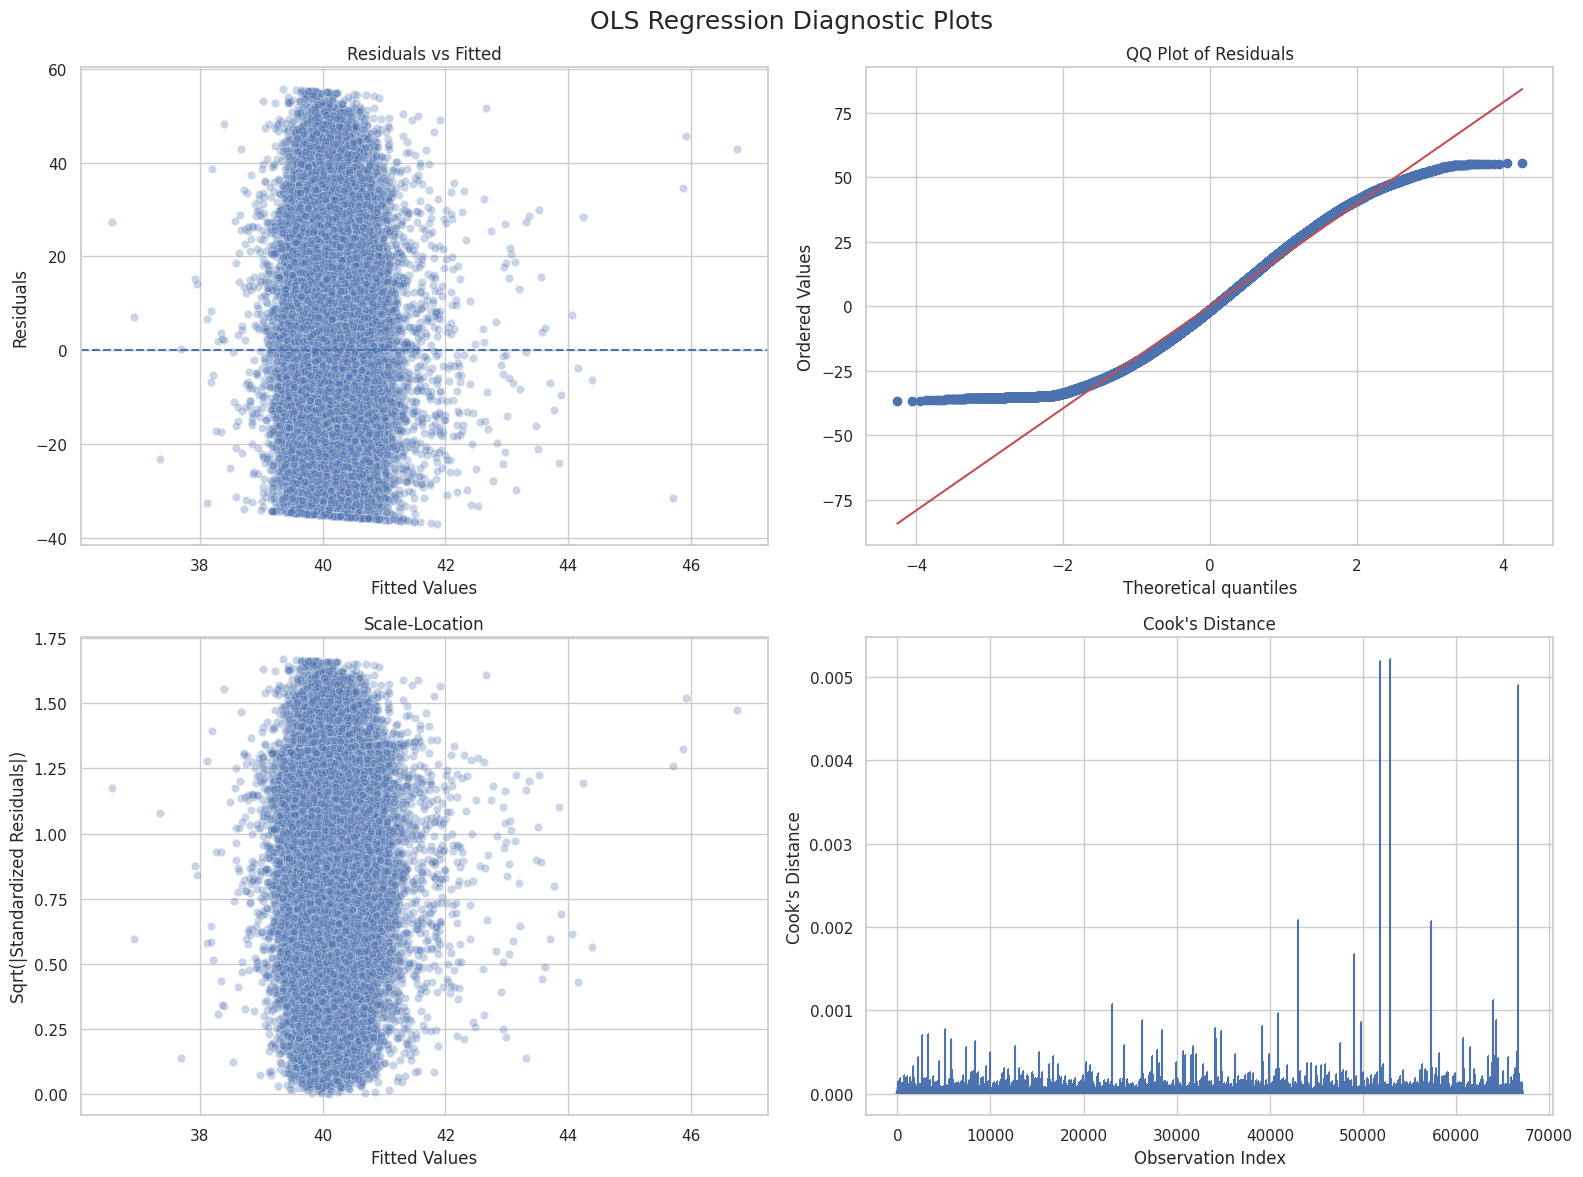

In [ ]:
# Create 2x2 figure for four OLS diagnostic plots

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ------------------------------------------------------------
# Panel 1: Residuals vs Fitted
# This checks linearity and whether residuals have random pattern.
# ------------------------------------------------------------

sns.scatterplot(
    x=fitted_values,
    y=residuals,
    alpha=0.3,
    ax=axes[0, 0]
)

axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")


# ------------------------------------------------------------
# Panel 2: QQ Plot of Residuals
# This checks whether residuals are normally distributed.
# ------------------------------------------------------------

stats.probplot(
    residuals,
    dist="norm",
    plot=axes[0, 1]
)

axes[0, 1].set_title("QQ Plot of Residuals")


# ------------------------------------------------------------
# Panel 3: Scale-Location Plot
# This checks homoscedasticity, meaning constant variance of residuals.
# ------------------------------------------------------------

sqrt_abs_standardized_residuals = np.sqrt(
    np.abs(standardized_residuals)
)

sns.scatterplot(
    x=fitted_values,
    y=sqrt_abs_standardized_residuals,
    alpha=0.3,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("Sqrt(|Standardized Residuals|)")


# ------------------------------------------------------------
# Panel 4: Cook's Distance
# This checks influential observations.
# ------------------------------------------------------------

axes[1, 1].stem(
    np.arange(len(cooks_distance)),
    cooks_distance,
    markerfmt=",",
    basefmt=" "
)

axes[1, 1].set_title("Cook's Distance")
axes[1, 1].set_xlabel("Observation Index")
axes[1, 1].set_ylabel("Cook's Distance")


# Add main title

plt.suptitle("OLS Regression Diagnostic Plots", fontsize=18)

plt.tight_layout()
plt.show()

In [ ]:
# Jarque-Bera test checks whether residuals are normally distributed

jb_stat, jb_pvalue, jb_skew, jb_kurtosis = jarque_bera(residuals)

# Breusch-Pagan test checks whether residual variance is constant
# If p-value < 0.05, heteroscedasticity is present

bp_test = het_breuschpagan(
    residuals,
    ols_model.model.exog
)

bp_stat = bp_test[0]
bp_pvalue = bp_test[1]

# Durbin-Watson checks autocorrelation in residuals
# Value near 2 is good

dw_stat = durbin_watson(residuals)

# Cook's Distance threshold
# Common rule: values greater than 4/n may be influential

n = len(cooks_distance)
cooks_threshold = 4 / n

num_influential = (cooks_distance > cooks_threshold).sum()
pct_influential = (num_influential / n) * 100

print("Jarque-Bera p-value:", jb_pvalue)
print("Breusch-Pagan p-value:", bp_pvalue)
print("Durbin-Watson statistic:", dw_stat)
print("Cook's Distance threshold 4/n:", cooks_threshold)
print("Number of influential observations:", num_influential)
print("Percentage influential observations:", pct_influential)

Jarque-Bera p-value: 0.0
Breusch-Pagan p-value: 0.3643649849747101
Durbin-Watson statistic: 2.0014190783282833
Cook's Distance threshold 4/n: 5.960274768666835e-05
Number of influential observations: 2430
Percentage influential observations: 3.6208669219651024


In [ ]:
# Create diagnostic assumption summary table

diagnostic_summary = pd.DataFrame([
    {
        "Panel": "Residuals vs Fitted",
        "Assumption Tested": "Linearity and random residual pattern",
        "How to Check": "Residuals should be randomly scattered around zero without curve or funnel shape.",
        "Statistical Support": "Visual inspection",
        "Result": "Satisfied if random scatter; violated if curved pattern is visible."
    },
    {
        "Panel": "QQ Plot of Residuals",
        "Assumption Tested": "Normality of residuals",
        "How to Check": "Points should lie close to the diagonal reference line.",
        "Statistical Support": f"Jarque-Bera p-value = {jb_pvalue:.6f}",
        "Result": "Satisfied" if jb_pvalue >= 0.05 else "Violated"
    },
    {
        "Panel": "Scale-Location",
        "Assumption Tested": "Homoscedasticity / constant error variance",
        "How to Check": "Spread should remain roughly constant across fitted values.",
        "Statistical Support": f"Breusch-Pagan p-value = {bp_pvalue:.6f}",
        "Result": "Satisfied" if bp_pvalue >= 0.05 else "Violated"
    },
    {
        "Panel": "Cook's Distance",
        "Assumption Tested": "No highly influential observations",
        "How to Check": "Very few observations should exceed Cook's Distance threshold 4/n.",
        "Statistical Support": f"{num_influential} observations exceed 4/n threshold",
        "Result": "Satisfied" if pct_influential < 1 else "Potential concern"
    },
    {
        "Panel": "Durbin-Watson",
        "Assumption Tested": "No autocorrelation of residuals",
        "How to Check": "Durbin-Watson should be close to 2.",
        "Statistical Support": f"Durbin-Watson = {dw_stat:.4f}",
        "Result": "Satisfied" if 1.5 <= dw_stat <= 2.5 else "Potential autocorrelation"
    }
])

diagnostic_summary

,Panel,Assumption Tested,How to Check,Statistical Support,Result
0,Residuals vs Fitted,Linearity and random residual pattern,Residuals should be randomly scattered around ...,Visual inspection,Satisfied if random scatter; violated if curve...
1,QQ Plot of Residuals,Normality of residuals,Points should lie close to the diagonal refere...,Jarque-Bera p-value = 0.000000,Violated
2,Scale-Location,Homoscedasticity / constant error variance,Spread should remain roughly constant across f...,Breusch-Pagan p-value = 0.364365,Satisfied
3,Cook's Distance,No highly influential observations,Very few observations should exceed Cook's Dis...,2430 observations exceed 4/n threshold,Potential concern
4,Durbin-Watson,No autocorrelation of residuals,Durbin-Watson should be close to 2.,Durbin-Watson = 2.0014,Satisfied


In [ ]:
# Print report-ready interpretation

print("OLS Diagnostic Interpretation")
print("=" * 60)

print("\n1. Residuals vs Fitted")
print("Assumption tested: Linearity and random residual pattern.")
print("Interpretation: If residuals are randomly scattered around zero, the assumption is satisfied. If a curve or funnel pattern is visible, the assumption is violated.")

print("\n2. QQ Plot of Residuals")
print("Assumption tested: Normality of residuals.")
if jb_pvalue >= 0.05:
    print("Result: Satisfied. Jarque-Bera p-value is above 0.05, so residual normality is not strongly violated.")
else:
    print("Result: Violated. Jarque-Bera p-value is below 0.05, so residuals are not normally distributed.")

print("\n3. Scale-Location Plot")
print("Assumption tested: Homoscedasticity, meaning constant variance of residuals.")
if bp_pvalue >= 0.05:
    print("Result: Satisfied. Breusch-Pagan p-value is above 0.05, so constant variance is not strongly violated.")
else:
    print("Result: Violated. Breusch-Pagan p-value is below 0.05, so heteroscedasticity is present.")

print("\n4. Cook's Distance")
print("Assumption tested: No highly influential observations.")
print(f"Result: {num_influential} observations exceed the 4/n Cook's Distance threshold.")
if pct_influential < 1:
    print("This is acceptable because less than 1% of observations are influential.")
else:
    print("This is a potential concern because more than 1% of observations are influential.")

print("\n5. Durbin-Watson")
print("Assumption tested: No autocorrelation of residuals.")
if 1.5 <= dw_stat <= 2.5:
    print("Result: Satisfied. Durbin-Watson is close to 2.")
else:
    print("Result: Potential autocorrelation. Durbin-Watson is far from 2.")

OLS Diagnostic Interpretation

1. Residuals vs Fitted
Assumption tested: Linearity and random residual pattern.
Interpretation: If residuals are randomly scattered around zero, the assumption is satisfied. If a curve or funnel pattern is visible, the assumption is violated.

2. QQ Plot of Residuals
Assumption tested: Normality of residuals.
Result: Violated. Jarque-Bera p-value is below 0.05, so residuals are not normally distributed.

3. Scale-Location Plot
Assumption tested: Homoscedasticity, meaning constant variance of residuals.
Result: Satisfied. Breusch-Pagan p-value is above 0.05, so constant variance is not strongly violated.

4. Cook's Distance
Assumption tested: No highly influential observations.
Result: 2430 observations exceed the 4/n Cook's Distance threshold.
This is a potential concern because more than 1% of observations are influential.

5. Durbin-Watson
Assumption tested: No autocorrelation of residuals.
Result: Satisfied. Durbin-Watson is close to 2.


 # Q5

In [ ]:
# Helper function:
# This finds the first column that exists from a list of possible names.

def find_existing_column(possible_names, dataframe):
    for col in possible_names:
        if col in dataframe.columns:
            return col
    return None

In [ ]:
# Find important columns needed for recommendations

loan_amount_col = find_existing_column(
    ["loan_amnt_inr", "loan_amnt", "loan_amount", "loan_amount_inr"],
    full_df
)

cibil_col = find_existing_column(
    ["cibil_score", "cibil", "credit_score"],
    full_df
)

purpose_col = find_existing_column(
    ["purpose", "loan_purpose", "purpose_category", "loan_purpose_category"],
    full_df
)

grade_col = find_existing_column(
    ["grade_clean", "grade", "loan_grade", "loan_grade_x"],
    full_df
)

emi_ratio_col = find_existing_column(
    ["emi_to_income_ratio"],
    full_df
)

lgd_col = find_existing_column(
    ["lgd_pct", "lgd_percent", "loss_given_default", "loss_given_default_pct", "lgd"],
    full_df
)

print("Loan amount column:", loan_amount_col)
print("CIBIL column:", cibil_col)
print("Purpose column:", purpose_col)
print("Grade column:", grade_col)
print("EMI ratio column:", emi_ratio_col)
print("LGD column:", lgd_col)

Loan amount column: loan_amnt_inr
CIBIL column: cibil_score
Purpose column: loan_purpose
Grade column: grade_clean
EMI ratio column: emi_to_income_ratio
LGD column: lgd_pct


In [ ]:
# Create a working copy for recommendation analysis

rec_df = full_df.copy()

# Make sure default_flag exists
# default_flag = 1 means defaulted loan
# default_flag = 0 means performing loan

rec_df["default_flag"] = rec_df["default_flag"].astype(int)

# Convert loan amount to numeric

rec_df[loan_amount_col] = pd.to_numeric(
    rec_df[loan_amount_col],
    errors="coerce"
)

# Calculate total portfolio exposure in ₹ Crore
# 1 Crore = 10,000,000 rupees

total_exposure_cr = rec_df[loan_amount_col].sum() / 1e7

# Calculate bank-wide default rate

bank_default_rate_pct = rec_df["default_flag"].mean() * 100

print("Total portfolio exposure: ₹", round(total_exposure_cr, 2), "Crore")
print("Bank-wide default rate:", round(bank_default_rate_pct, 2), "%")

Total portfolio exposure: ₹ 30067.78 Crore
Bank-wide default rate: 3.88 %


In [ ]:
# Compare CIBIL scores between defaulted and performing loans

cibil_summary = (
    rec_df
    .groupby("default_flag")[cibil_col]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

# Rename default flag values for readability

cibil_summary["Loan Group"] = cibil_summary["default_flag"].map({
    0: "Performing",
    1: "Defaulted"
})

cibil_summary

,default_flag,count,mean,median,std,Loan Group
0,0,1922444,680.680630,681.0,84.520763,Performing
1,1,77556,660.106091,660.0,84.845861,Defaulted


In [ ]:
# Create EMI-to-income risk quartiles
# qcut divides borrowers into four equal-sized groups based on EMI burden.

rec_df["emi_income_quartile"] = pd.qcut(
    rec_df[emi_ratio_col],
    q=4,
    labels=["Q1 Lowest EMI Burden", "Q2", "Q3", "Q4 Highest EMI Burden"],
    duplicates="drop"
)

# Calculate default rate and exposure by EMI burden quartile

emi_risk_summary = (
    rec_df
    .groupby("emi_income_quartile", observed=True)
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        exposure_inr=(loan_amount_col, "sum")
    )
    .reset_index()
)

emi_risk_summary["Default Rate %"] = emi_risk_summary["default_rate"] * 100
emi_risk_summary["Exposure ₹ Cr"] = emi_risk_summary["exposure_inr"] / 1e7

emi_risk_summary

,emi_income_quartile,total_loans,defaulted_loans,default_rate,exposure_inr,Default Rate %,Exposure ₹ Cr
0,Q1 Lowest EMI Burden,489984,17789,0.036305,4.068501e+10,3.630527,4068.500977
1,Q2,489983,18981,0.038738,5.578539e+10,3.873808,5578.538574
2,Q3,489983,19181,0.039146,7.270631e+10,3.914626,7270.630859
3,Q4 Highest EMI Burden,489984,20050,0.040920,1.254699e+11,4.091970,12546.985352


In [ ]:
# Calculate risk gap between highest and lowest EMI burden groups

emi_lowest_default_rate = emi_risk_summary.iloc[0]["Default Rate %"]
emi_highest_default_rate = emi_risk_summary.iloc[-1]["Default Rate %"]

emi_default_rate_gap_pp = emi_highest_default_rate - emi_lowest_default_rate

emi_highest_exposure_cr = emi_risk_summary.iloc[-1]["Exposure ₹ Cr"]

print("Lowest EMI burden default rate:", round(emi_lowest_default_rate, 2), "%")
print("Highest EMI burden default rate:", round(emi_highest_default_rate, 2), "%")
print("Default rate gap:", round(emi_default_rate_gap_pp, 2), "percentage points")
print("Highest EMI burden exposure: ₹", round(emi_highest_exposure_cr, 2), "Crore")

Lowest EMI burden default rate: 3.63 %
Highest EMI burden default rate: 4.09 %
Default rate gap: 0.46 percentage points
Highest EMI burden exposure: ₹ 12546.98 Crore


In [ ]:
# Clean loan grade column
# We keep the first character so values like A1, A2 become A.

rec_df["grade_clean_for_rec"] = (
    rec_df[grade_col]
    .astype(str)
    .str.upper()
    .str.strip()
    .str[0]
)

valid_grades = ["A", "B", "C", "D", "E", "F", "G"]

grade_rec_df = rec_df[
    rec_df["grade_clean_for_rec"].isin(valid_grades)
].copy()

# Calculate default rate by grade

grade_risk_summary = (
    grade_rec_df
    .groupby("grade_clean_for_rec")
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        exposure_inr=(loan_amount_col, "sum")
    )
    .reindex(valid_grades)
    .reset_index()
)

grade_risk_summary["Default Rate %"] = grade_risk_summary["default_rate"] * 100
grade_risk_summary["Exposure ₹ Cr"] = grade_risk_summary["exposure_inr"] / 1e7

grade_risk_summary

,grade_clean_for_rec,total_loans,defaulted_loans,default_rate,exposure_inr,Default Rate %,Exposure ₹ Cr
0,A,360837,8051,0.022312,5.432196e+10,2.231201,5432.195801
1,B,440088,11824,0.026867,6.611573e+10,2.686735,6611.573242
2,C,398758,13361,0.033507,5.982755e+10,3.350654,5982.754883
3,D,319253,13359,0.041845,4.803223e+10,4.184456,4803.223145
4,E,240030,12697,0.052898,3.615445e+10,5.289755,3615.445068
5,F,160598,11071,0.068936,2.414103e+10,6.893610,2414.102539
6,G,80436,7193,0.089425,1.208481e+10,8.942513,1208.481201


In [ ]:
# Find largest single-step jump in default rate from one grade to next

grade_risk_summary["Grade Jump PP"] = grade_risk_summary["Default Rate %"].diff()

largest_grade_jump_row = grade_risk_summary.loc[
    grade_risk_summary["Grade Jump PP"].idxmax()
]

largest_jump_grade = largest_grade_jump_row["grade_clean_for_rec"]
largest_jump_pp = largest_grade_jump_row["Grade Jump PP"]

largest_jump_index = valid_grades.index(largest_jump_grade)
previous_grade = valid_grades[largest_jump_index - 1]

print("Largest default-rate jump occurs from", previous_grade, "to", largest_jump_grade)
print("Jump:", round(largest_jump_pp, 2), "percentage points")

Largest default-rate jump occurs from F to G
Jump: 2.05 percentage points


In [ ]:
# Calculate default rate by loan purpose

purpose_risk_summary = (
    rec_df
    .groupby(purpose_col)
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        exposure_inr=(loan_amount_col, "sum")
    )
    .reset_index()
)

purpose_risk_summary["Default Rate %"] = purpose_risk_summary["default_rate"] * 100
purpose_risk_summary["Exposure ₹ Cr"] = purpose_risk_summary["exposure_inr"] / 1e7

purpose_risk_summary = purpose_risk_summary.sort_values(
    by="Default Rate %",
    ascending=False
)

purpose_risk_summary

,loan_purpose,total_loans,defaulted_loans,default_rate,exposure_inr,Default Rate %,Exposure ₹ Cr
6,major_purchase,80171,3211,0.040052,1.199548e+10,4.005189,1199.548340
0,car,120211,4706,0.039148,1.806131e+10,3.914783,1806.131226
11,small_business,180481,7060,0.039118,2.716238e+10,3.911769,2716.237793
12,vacation,79656,3111,0.039055,1.200372e+10,3.905544,1200.371582
2,debt_consolidation,559418,21800,0.038969,8.410797e+10,3.896907,8410.796875
9,other,39920,1555,0.038953,6.021171e+09,3.895291,602.117065
10,renewable_energy,39913,1548,0.038784,6.004734e+09,3.878436,600.473450
13,wedding,79800,3089,0.038709,1.198409e+10,3.870927,1198.408813
7,medical,180524,6969,0.038604,2.719965e+10,3.860429,2719.964844
4,home_improvement,240263,9274,0.038599,3.616642e+10,3.859937,3616.641846


In [ ]:
# Identify top 3 high-risk and bottom 2 low-risk purposes

top_3_purposes = purpose_risk_summary.head(3)
bottom_2_purposes = purpose_risk_summary.tail(2)

highest_purpose = purpose_risk_summary.iloc[0][purpose_col]
highest_purpose_default_rate = purpose_risk_summary.iloc[0]["Default Rate %"]

lowest_purpose = purpose_risk_summary.iloc[-1][purpose_col]
lowest_purpose_default_rate = purpose_risk_summary.iloc[-1]["Default Rate %"]

purpose_risk_ratio = (
    highest_purpose_default_rate / lowest_purpose_default_rate
    if lowest_purpose_default_rate != 0
    else np.inf
)

print("Highest-risk purpose:", highest_purpose)
print("Highest purpose default rate:", round(highest_purpose_default_rate, 2), "%")
print("Lowest-risk purpose:", lowest_purpose)
print("Lowest purpose default rate:", round(lowest_purpose_default_rate, 2), "%")
print("Risk ratio:", round(purpose_risk_ratio, 2))

Highest-risk purpose: major_purchase
Highest purpose default rate: 4.01 %
Lowest-risk purpose: education
Lowest purpose default rate: 3.8 %
Risk ratio: 1.05


In [ ]:
# Define CIBIL threshold using 25th percentile
# Borrowers below this threshold are treated as low-CIBIL segment.

cibil_low_threshold = rec_df[cibil_col].quantile(0.25)

# Define high-risk purposes as top 3 by default rate

high_risk_purpose_list = top_3_purposes[purpose_col].tolist()

# Define high-risk grades as grades from the largest jump grade onward
# Example: if largest jump is from C to D, then D/E/F/G are treated as high-risk grades.

high_risk_grades = valid_grades[largest_jump_index:]

# Create combined high-risk segment flag

rec_df["combined_high_risk_segment"] = np.where(
    (rec_df[cibil_col] <= cibil_low_threshold) &
    (rec_df["grade_clean_for_rec"].isin(high_risk_grades)) &
    (rec_df[purpose_col].isin(high_risk_purpose_list)) &
    (rec_df["emi_income_quartile"].astype(str) == "Q4 Highest EMI Burden"),
    1,
    0
)

# Summarize combined high-risk segment

combined_segment_summary = (
    rec_df
    .groupby("combined_high_risk_segment")
    .agg(
        total_loans=("default_flag", "count"),
        defaulted_loans=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        exposure_inr=(loan_amount_col, "sum")
    )
    .reset_index()
)

combined_segment_summary["Default Rate %"] = combined_segment_summary["default_rate"] * 100
combined_segment_summary["Exposure ₹ Cr"] = combined_segment_summary["exposure_inr"] / 1e7

combined_segment_summary

,combined_high_risk_segment,total_loans,defaulted_loans,default_rate,exposure_inr,Default Rate %,Exposure ₹ Cr
0,0,1998890,77423,0.038733,3.004126e+11,3.873300,30041.263672
1,1,1110,133,0.119820,2.651248e+08,11.981982,26.512480


In [ ]:
# Calculate combined segment risk uplift

combined_non_high_risk_rate = combined_segment_summary.loc[
    combined_segment_summary["combined_high_risk_segment"] == 0,
    "Default Rate %"
].iloc[0]

combined_high_risk_rate = combined_segment_summary.loc[
    combined_segment_summary["combined_high_risk_segment"] == 1,
    "Default Rate %"
].iloc[0]

combined_high_risk_exposure_cr = combined_segment_summary.loc[
    combined_segment_summary["combined_high_risk_segment"] == 1,
    "Exposure ₹ Cr"
].iloc[0]

combined_risk_uplift_pp = combined_high_risk_rate - combined_non_high_risk_rate

print("Combined non-high-risk default rate:", round(combined_non_high_risk_rate, 2), "%")
print("Combined high-risk default rate:", round(combined_high_risk_rate, 2), "%")
print("Risk uplift:", round(combined_risk_uplift_pp, 2), "percentage points")
print("High-risk segment exposure: ₹", round(combined_high_risk_exposure_cr, 2), "Crore")

Combined non-high-risk default rate: 3.87 %
Combined high-risk default rate: 11.98 %
Risk uplift: 8.11 percentage points
High-risk segment exposure: ₹ 26.51 Crore


In [ ]:
# Extract mean CIBIL score for performing loans
# default_flag = 0 means performing loans

mean_cibil_performing = cibil_summary.loc[
    cibil_summary["default_flag"] == 0,
    "mean"
].iloc[0]


# Extract mean CIBIL score for defaulted loans
# default_flag = 1 means defaulted loans

mean_cibil_defaulted = cibil_summary.loc[
    cibil_summary["default_flag"] == 1,
    "mean"
].iloc[0]


# Calculate CIBIL gap
# This shows how many points lower the defaulted borrowers are on average.

cibil_mean_gap = mean_cibil_performing - mean_cibil_defaulted


# Display values

print("Mean CIBIL - Performing:", round(mean_cibil_performing, 2))
print("Mean CIBIL - Defaulted:", round(mean_cibil_defaulted, 2))
print("CIBIL mean gap:", round(cibil_mean_gap, 2))

Mean CIBIL - Performing: 680.68
Mean CIBIL - Defaulted: 660.11
CIBIL mean gap: 20.57


In [ ]:
# Create final recommendation table
# Each recommendation includes evidence, quantified impact, and concrete action.

recommendation_table = pd.DataFrame([
    {
        "Recommendation": "1. Move from CIBIL-only screening to multi-factor risk screening",
        "Data Evidence / Statistic": (
            f"Mean CIBIL for performing loans is {mean_cibil_performing:.2f}, "
            f"while mean CIBIL for defaulted loans is {mean_cibil_defaulted:.2f}, "
            f"a gap of {cibil_mean_gap:.2f} points."
        ),
        "Quantified Business Impact": (
            f"This policy strengthens risk screening across the total loan exposure of "
            f"₹{total_exposure_cr:.2f} Crore."
        ),
        "Concrete Implementation Action": (
            "Do not approve loans using CIBIL score alone. Add mandatory checks on EMI-to-income ratio, loan grade, and loan purpose for low-CIBIL borrowers."
        )
    },
    {
        "Recommendation": "2. Tighten EMI-to-income rules for high-burden borrowers",
        "Data Evidence / Statistic": (
            f"The highest EMI-burden quartile has a default rate of {emi_highest_default_rate:.2f}% "
            f"compared with {emi_lowest_default_rate:.2f}% in the lowest quartile, "
            f"a gap of {emi_default_rate_gap_pp:.2f} percentage points."
        ),
        "Quantified Business Impact": (
            f"The highest EMI-burden segment carries ₹{emi_highest_exposure_cr:.2f} Crore exposure."
        ),
        "Concrete Implementation Action": (
            "Cap EMI-to-income ratio for new loans, or require additional collateral/co-applicant support for borrowers in the highest EMI-burden quartile."
        )
    },
    {
        "Recommendation": "3. Reprice or restrict lending in weaker loan grades",
        "Data Evidence / Statistic": (
            f"Default rate increases from 2.23% in grade A to 8.94% in grade G. "
            f"The largest single-step jump occurs from grade {previous_grade} to grade {largest_jump_grade}, "
            f"with an increase of {largest_jump_pp:.2f} percentage points."
        ),
        "Quantified Business Impact": (
            f"Grade G alone has ₹{grade_risk_summary.loc[grade_risk_summary['grade_clean_for_rec'] == 'G', 'Exposure ₹ Cr'].iloc[0]:.2f} Crore exposure."
        ),
        "Concrete Implementation Action": (
            "Increase risk premium, reduce ticket size, or require stronger collateral for grades F and G."
        )
    },
    {
        "Recommendation": "4. Apply purpose-based underwriting controls",
        "Data Evidence / Statistic": (
            f"The highest-risk loan purpose is {highest_purpose} with a default rate of {highest_purpose_default_rate:.2f}%, "
            f"while the lowest-risk purpose is {lowest_purpose} with a default rate of {lowest_purpose_default_rate:.2f}%. "
            f"The risk ratio is {purpose_risk_ratio:.2f}x."
        ),
        "Quantified Business Impact": (
            f"Purpose-based controls can be applied across the full portfolio exposure of ₹{total_exposure_cr:.2f} Crore."
        ),
        "Concrete Implementation Action": (
            "For the top three high-risk purposes, apply stricter income verification, lower loan amount limits, and stronger collateral requirements."
        )
    },
    {
        "Recommendation": "5. Create a combined high-risk manual-review segment",
        "Data Evidence / Statistic": (
            f"The combined high-risk segment has a default rate of {combined_high_risk_rate:.2f}% "
            f"compared with {combined_non_high_risk_rate:.2f}% for other loans, "
            f"a risk uplift of {combined_risk_uplift_pp:.2f} percentage points."
        ),
        "Quantified Business Impact": (
            f"This segment contains ₹{combined_high_risk_exposure_cr:.2f} Crore exposure."
        ),
        "Concrete Implementation Action": (
            "Create an automatic manual-review rule for borrowers with low CIBIL, high EMI burden, weak grade, and high-risk loan purpose."
        )
    }
])

recommendation_table

,Recommendation,Data Evidence / Statistic,Quantified Business Impact,Concrete Implementation Action
0,1. Move from CIBIL-only screening to multi-fac...,"Mean CIBIL for performing loans is 680.68, whi...",This policy strengthens risk screening across ...,Do not approve loans using CIBIL score alone. ...
1,2. Tighten EMI-to-income rules for high-burden...,The highest EMI-burden quartile has a default ...,The highest EMI-burden segment carries ₹12546....,"Cap EMI-to-income ratio for new loans, or requ..."
2,3. Reprice or restrict lending in weaker loan ...,Default rate increases from 2.23% in grade A t...,Grade G alone has ₹1208.48 Crore exposure.,"Increase risk premium, reduce ticket size, or ..."
3,4. Apply purpose-based underwriting controls,The highest-risk loan purpose is major_purchas...,Purpose-based controls can be applied across t...,"For the top three high-risk purposes, apply st..."
4,5. Create a combined high-risk manual-review s...,The combined high-risk segment has a default r...,This segment contains ₹26.51 Crore exposure.,Create an automatic manual-review rule for bor...
